In [3]:
import os

import numpy as np

import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

In [16]:
# Galaxies in the JADES dropout selection that also appear in Ryan's selection
matches_jades = np.array([[53.16575699, -27.80345124], [53.15705564, -27.77271493],
    [53.17329097, -27.76850957], [53.11041671, -27.80892358],
    [53.16776065, -27.80232381], [53.11276397, -27.81769847],
    [53.16041659, -27.82107616], [53.17252283, -27.81736256],
    [53.20499733, -27.77402372], [53.13149302, -27.80395526],
    [53.12689084, -27.79204953], [53.15856409, -27.76363123],
    [53.16898095, -27.78665756], [53.16640015, -27.8041428 ],
    [53.1522701 , -27.81949871], [53.16940702, -27.76188601],
    [53.14195745, -27.75523722], [53.16570287, -27.75712115],
    [53.14169175, -27.80702138], [53.13180462, -27.78935583],
    [53.16653668, -27.73149084], [53.1595274 , -27.79765621],
    [53.14077875, -27.80217912], [53.17835053, -27.7787877 ],
    [53.09327593, -27.86535844], [53.04450918, -27.88052745],
    [53.14786883, -27.79602183], [53.1853965 , -27.78721872],
    [53.18744104, -27.77804075], [53.15321677, -27.81590024],
    [53.18548332, -27.77442543], [53.14379232, -27.76817306],
    [53.16467617, -27.75379007], [53.16460733, -27.78046737],
    [53.16441101, -27.76213722], [53.16761594, -27.77579571],
    [53.17260183, -27.79745292], [53.14702421, -27.82655676],
    [53.154195  , -27.8132244 ], [53.14952412, -27.78085588],
    [53.1722155 , -27.82241451], [53.14249197, -27.77758778],
    [53.14204862, -27.7993917 ], [53.15271888, -27.80877071],
    [53.11749287, -27.80525783], [53.14207751, -27.77985118],
    [53.13930199, -27.79586773], [53.14736274, -27.74928101],
    [53.18294819, -27.79584778], [53.16002789, -27.76357248],
    [53.13407419, -27.78156454], [53.17929499, -27.77330878],
    [53.18731843, -27.76886687], [53.16023102, -27.77225291],
    [53.19988669, -27.78483153], [53.12737663, -27.79830573],
    [53.13514139, -27.77946253], [53.13889014, -27.80678082],
    [53.16062148, -27.77161004], [53.1539792 , -27.75956929],
    [53.19816693, -27.78654257], [53.16771269, -27.768168  ],
    [53.04450429, -27.87908435], [53.17349618, -27.82506927],
    [53.17162635, -27.82086768], [53.15166811, -27.80923654],
    [53.14293436, -27.80802683], [53.15280283, -27.80629819],
    [53.1630515 , -27.80520223], [53.16400549, -27.80503924],
    [53.14600737, -27.8016262 ], [53.13588379, -27.7983956 ],
    [53.15259662, -27.79731363], [53.13206683, -27.79500147],
    [53.19922266, -27.7891038 ], [53.12487239, -27.78412714],
    [53.15578221, -27.74612966], [53.14504636, -27.76278472],
    [53.2023909 , -27.77157563], [53.21146388, -27.78155535],
    [53.12788364, -27.78197421], [ 53.1532456 , -27.79829503],
    [53.14619348, -27.80196644], [ 53.18823759, -27.76359327],
    [53.18627822, -27.7793613 ], [ 53.15766544, -27.81836731],
    [53.14884367, -27.80969611], [ 53.15579378, -27.81520908],
    [53.15139727, -27.81162234], [ 53.03810995, -27.87478386],
    [53.16580891, -27.77611254], [ 53.16900056, -27.80079209],
    [53.2000357 , -27.79087499], [ 53.17834398, -27.80097301],
    [53.17168161, -27.7797057 ], [ 53.15603055, -27.78098246],
    [53.16912333, -27.76590973], [ 53.13491814, -27.77271068],
    [53.15952341, -27.77152309], [ 53.19940081, -27.79628498],
    [53.1551461 , -27.7607251 ], [ 53.14227335, -27.80683895],
    [53.03754013, -27.87491747], [ 53.1604267 , -27.81612914],
    [53.17322713, -27.79568011], [ 53.1460876 , -27.79456673],
    [53.12431864, -27.79342423], [ 53.20129044, -27.79350061],
    [53.14387564, -27.79308573], [ 53.13158443, -27.78910537],
    [53.12731178, -27.78804366], [ 53.1667758 , -27.78591806],
    [53.16105209, -27.77130134], [ 53.17465365, -27.77672019],
    [53.18245084, -27.77610062], [ 53.15195316, -27.77825585],
    [53.16904682, -27.77883354], [189.12641658,  62.29003497],
    [189.19778405,  62.19996101], [189.23650087,  62.1413931 ],
    [189.15382555,  62.2055918 ], [189.11400822,  62.24293906],
    [189.16919689,  62.2384688 ], [189.25660688,  62.24031106],
    [189.24216708,  62.24944679], [189.09197049,  62.2431476 ],
    [189.2372057 ,  62.15206353], [189.14467225,  62.3056536 ],
    [189.1708126 ,  62.2659628 ], [189.24254205,  62.24800336],
    [189.18192751,  62.17635607], [189.26628405,  62.23317887],
    [189.18089526,  62.23888176], [189.23101629,  62.25233167],
    [189.1309423 ,  62.29645137], [189.12383538,  62.21549537],
    [189.18913467,  62.30066828], [189.16939909,  62.2496232 ],
    [189.21138823,  62.24106028], [189.31721061,  62.1697568 ],
    [189.20888418,  62.19736206], [189.19123515,  62.19950808],
    [189.2388427 ,  62.22413741], [189.23739516,  62.22812225],
    [189.207018  ,  62.23190635], [189.20818744,  62.23212276],
    [189.13792422,  62.23601218], [189.15821581,  62.27842469],
    [189.05161282,  62.27383692], [189.17741243,  62.31060794],
    [189.11606859,  62.30326861], [189.15180112,  62.25779732],
    [189.151966  ,  62.25963796], [189.18629183,  62.20554711],
    [189.22903261,  62.15060797], [189.30327141,  62.1784791 ],
    [189.17511116,  62.28225573]], dtype=np.float64)

# Galaxies in the DJA dropout selection that also appear in Ryan's selection
matches_dja = np.array([[53.15530045, -27.80555744], [53.16576622, -27.80344273],
    [53.15705718, -27.77271965], [53.17329281, -27.76851431],
    [53.16041795, -27.82107333], [53.17252288, -27.81736247],
    [53.17073486, -27.75946353], [53.13149911, -27.80395638],
    [53.15932956, -27.8088259 ], [53.14196059, -27.75524208],
    [53.15952829, -27.79764953], [53.14078196, -27.80217928],
    [53.14787378, -27.79602483], [53.18539004, -27.78721539],
    [53.15322062, -27.81589798], [53.18548245, -27.77442916],
    [53.14379203, -27.76817563], [53.16467904, -27.75379283],
    [53.16441162, -27.76214012], [53.17258971, -27.79743472],
    [53.15419793, -27.81322288], [53.14953137, -27.78085649],
    [53.17221771, -27.82241464], [53.14205639, -27.79939257],
    [53.15271968, -27.80876701], [53.11748835, -27.8052599 ],
    [53.14208565, -27.77985115], [53.1393081 , -27.79586813],
    [53.16002977, -27.76357445], [53.17929208, -27.77330907],
    [53.12589417, -27.78330382], [53.13514796, -27.77946409],
    [53.13889297, -27.80678338], [53.16062485, -27.7716127 ],
    [53.16772339, -27.76819345], [53.1716188 , -27.8208562 ],
    [53.14467293, -27.81584833], [53.14293601, -27.80802907],
    [53.16305467, -27.80520111], [53.16400887, -27.80503647],
    [53.14601184, -27.80162487], [53.13589306, -27.79839968],
    [53.13207374, -27.79500067], [53.16711566, -27.79423526],
    [53.19921537, -27.78910661], [53.15578366, -27.74613469],
    [53.14986408, -27.75283448], [53.20238868, -27.77157754],
    [53.21145046, -27.78154932], [53.16386158, -27.76486292],
    [53.14619298, -27.80197386], [53.15766678, -27.81836472],
    [53.14885041, -27.80969324], [53.15972272, -27.82280053],
    [53.15579605, -27.81520448], [53.15139849, -27.81161776],
    [53.1658137 , -27.77611586], [53.16900336, -27.80078757],
    [53.20003387, -27.7908751 ], [53.17834393, -27.80096965],
    [53.15603671, -27.78098418], [53.16912653, -27.76591365],
    [53.13492118, -27.77271074], [53.15952757, -27.77152933],
    [53.19938916, -27.79628312], [53.15514201, -27.76074581],
    [53.16042708, -27.81612576], [53.17323225, -27.79567857],
    [53.14388082, -27.79308772], [53.1516027 , -27.78791509],
    [53.17264763, -27.7670924 ], [53.17465196, -27.77671779],
    [53.18244905, -27.77610288], [53.15197454, -27.77825685],
    [53.16904438, -27.77883627]], dtype=np.float64)


matches_ryan = np.array([[189.23956, 62.135895], [189.24475, 62.137344], [189.23769, 62.138012], [189.25662, 62.138313], [189.23006, 62.13959],
    [189.244, 62.139893], [189.23651, 62.14139], [189.21922, 62.141357], [189.25536, 62.14155], [189.23225, 62.14376],
    [189.24, 62.145893], [189.23064, 62.146503], [189.24124, 62.14803], [189.24043, 62.149128], [189.233, 62.149303],
    [189.32404, 62.149277], [189.31198, 62.149326], [189.23314, 62.14927], [189.20883, 62.149624], [189.30681, 62.14977],
    [189.2793, 62.150063], [189.30121, 62.15073], [189.29536, 62.151394], [189.32481, 62.15156], [189.33827, 62.152443],
    [189.24132, 62.152473], [189.23064, 62.15256], [189.26622, 62.1526], [189.26515, 62.152905], [189.2653, 62.153004],
    [189.28624, 62.152996], [189.3168, 62.153606], [189.3148, 62.153862], [189.29637, 62.154835], [189.30522, 62.155235],
    [189.26962, 62.155376], [189.3163, 62.15536], [189.21048, 62.15535], [189.32652, 62.15614], [189.27855, 62.157574],
    [189.30515, 62.156704], [189.2748, 62.156776], [189.32784, 62.157047], [189.27194, 62.157555], [189.30295, 62.157585],
    [189.20375, 62.15758], [189.20667, 62.158073], [189.23987, 62.15813], [189.366, 62.158504], [189.21085, 62.158524],
    [189.32495, 62.15879], [189.36844, 62.159145], [189.22554, 62.159096], [189.23921, 62.159206], [189.25758, 62.159317],
    [189.28967, 62.15932], [189.27966, 62.15954], [189.35474, 62.159748], [189.32698, 62.159916], [189.22595, 62.16044],
    [189.3487, 62.161068], [189.36029, 62.161438], [189.3131, 62.161808], [189.31332, 62.161892], [189.34862, 62.161957],
    [189.20343, 62.16192], [189.22935, 62.16206], [189.36218, 62.16221], [189.21828, 62.16228], [189.20525, 62.162518],
    [189.25587, 62.162834], [189.28273, 62.163403], [189.21712, 62.163494], [189.3262, 62.16367], [189.32632, 62.163956],
    [189.32535, 62.164078], [189.22578, 62.16423], [189.19864, 62.164326], [189.30925, 62.164577], [189.28667, 62.16449],
    [189.32527, 62.164543], [189.2088, 62.16491], [189.31924, 62.16491], [189.19254, 62.165394], [189.31128, 62.165955],
    [189.35019, 62.165936], [189.26492, 62.165913], [189.33383, 62.16601], [189.31708, 62.165897], [189.3104, 62.166256],
    [189.31058, 62.1663], [189.35185, 62.16663], [189.21898, 62.166695], [189.28564, 62.16713], [189.24968, 62.167187],
    [189.25505, 62.167763], [189.29143, 62.16771], [189.32605, 62.167873], [189.2402, 62.168034], [189.25188, 62.168182],
    [189.24492, 62.168232], [189.33522, 62.16861], [189.2599, 62.168877], [189.24725, 62.16897], [189.32289, 62.169125],
    [189.22456, 62.169083], [189.28156, 62.169205], [189.26836, 62.169308], [189.28651, 62.169537], [189.31631, 62.170105],
    [189.32536, 62.170788], [189.24684, 62.171032], [189.22798, 62.17111], [189.34296, 62.171345], [189.31061, 62.171337],
    [189.276, 62.171432], [189.3242, 62.171577], [189.19392, 62.17138], [189.26993, 62.171665], [189.18236, 62.17167],
    [189.19106, 62.172073], [189.19583, 62.172993], [189.28653, 62.17308], [189.32661, 62.173626], [189.24782, 62.173935],

    [189.20825, 62.174053],

    [189.19438, 62.173958],

    [189.19391, 62.17417],

    [189.27614, 62.17425],

    [189.17882, 62.174644],

    [189.21654, 62.174736],

    [189.29092, 62.17481],

    [189.29485, 62.17502],

    [189.26987, 62.175022],

    [189.23282, 62.17542],

    [189.19478, 62.17533],

    [189.20276, 62.17557],

    [189.32443, 62.175636],

    [189.28178, 62.175686],

    [189.18193, 62.176357],

    [189.28442, 62.176716],

    [189.31859, 62.176693],

    [189.2427, 62.176964],

    [189.28412, 62.17731],

    [189.24413, 62.17713],

    [189.19754, 62.177258],

    [189.22626, 62.177387],

    [189.34962, 62.177757],

    [189.26474, 62.17779],

    [189.32895, 62.17817],

    [189.20825, 62.178093],

    [189.23764, 62.17834],

    [189.3003, 62.179058],

    [189.2287, 62.17897],

    [189.26132, 62.179146],

    [189.2483, 62.179283],

    [189.29817, 62.179302],

    [189.32687, 62.179417],

    [189.18152, 62.179497],

    [189.3183, 62.180008],

    [189.18271, 62.180065],

    [189.30058, 62.18016],

    [189.32689, 62.180653],

    [189.35117, 62.18122],

    [189.31761, 62.181404],

    [189.31783, 62.181473],

    [189.30493, 62.18211],

    [189.24432, 62.182617],

    [189.18721, 62.182487],

    [189.30536, 62.182674],

    [189.34554, 62.18292],

    [189.3034, 62.182987],

    [189.30272, 62.183437],

    [189.32463, 62.183594],

    [189.30464, 62.183628],

    [189.2907, 62.183613],

    [189.23206, 62.18383],

    [189.19461, 62.183846],

    [189.20686, 62.1843],

    [189.27708, 62.18456],

    [189.27098, 62.18477],

    [189.32591, 62.184937],

    [189.323, 62.18524],

    [189.3235, 62.18558],

    [189.2091, 62.186016],

    [189.29082, 62.18622],

    [189.21031, 62.186134],

    [189.29985, 62.185825],

    [189.25397, 62.186237],

    [189.3098, 62.186314],

    [189.28568, 62.187134],

    [189.1673, 62.187347],

    [189.29707, 62.187542],

    [189.30002, 62.18783],

    [189.25966, 62.18796],

    [189.1823, 62.187836],

    [189.23497, 62.187946],

    [189.25601, 62.188454],

    [189.24643, 62.188526],

    [189.2469, 62.18859],

    [189.34302, 62.188797],

    [189.20192, 62.189003],

    [189.17535, 62.188942],

    [189.27986, 62.18934],

    [189.24933, 62.189514],

    [189.17032, 62.1896],

    [189.2624, 62.19025],

    [189.2609, 62.190502],

    [189.28506, 62.19082],

    [189.2005, 62.19085],

    [189.26039, 62.191795],

    [189.32085, 62.19185],

    [189.22, 62.192352],

    [189.26128, 62.192554],

    [189.2185, 62.192657],

    [189.2972, 62.19283],

    [189.2952, 62.192776],

    [189.29898, 62.193653],

    [189.3146, 62.19399],

    [189.19783, 62.194412],

    [189.25069, 62.19497],

    [189.27983, 62.19543],

    [189.16681, 62.195423],

    [189.29008, 62.195915],

    [189.19937, 62.195454],

    [189.27478, 62.19615],

    [189.19652, 62.19617],

    [189.19034, 62.196194],

    [189.18541, 62.19651],

    [189.27417, 62.196636],

    [189.28914, 62.196632],

    [189.25314, 62.19667],

    [189.30862, 62.196766],

    [189.19833, 62.19734],

    [189.17308, 62.19723],

    [189.24452, 62.19741],

    [189.15558, 62.197662],

    [189.28822, 62.197716],

    [189.2933, 62.1977],

    [189.174, 62.197792],

    [189.19725, 62.19816],

    [189.19305, 62.19831],

    [189.17766, 62.198475],

    [189.32364, 62.198566],

    [189.20566, 62.198853],

    [189.23227, 62.198868],

    [189.30063, 62.198868],

    [189.25903, 62.19888],

    [189.18378, 62.19883],

    [189.28314, 62.199116],

    [189.21362, 62.19911],

    [189.32686, 62.199265],

    [189.19124, 62.199512],

    [189.18953, 62.19924],

    [189.29224, 62.199554],

    [189.31303, 62.199856],

    [189.21231, 62.199917],

    [189.19778, 62.199963],

    [189.29486, 62.200127],

    [189.20164, 62.20001],

    [189.29498, 62.200092],

    [189.32838, 62.20012],

    [189.29486, 62.200207],

    [189.24118, 62.20066],

    [189.2786, 62.20074],

    [189.31255, 62.20109],

    [189.17302, 62.201195],

    [189.23233, 62.202744],

    [189.18529, 62.202724],

    [189.255, 62.202778],

    [189.27838, 62.203156],

    [189.23598, 62.203194],

    [189.19286, 62.203194],

    [189.18913, 62.203804],

    [189.25719, 62.20344],

    [189.2296, 62.20353],

    [189.18906, 62.203857],

    [189.19136, 62.203518],

    [189.22404, 62.203705],

    [189.18898, 62.203953],

    [189.16388, 62.204212],

    [189.2043, 62.204506],

    [189.24837, 62.204594],

    [189.31372, 62.205315],

    [189.26453, 62.205513],

    [189.27682, 62.205563],

    [189.21375, 62.205982],

    [189.25014, 62.20621],

    [189.27948, 62.206474],

    [189.31961, 62.20649],

    [189.24313, 62.206726],

    [189.24323, 62.206997],

    [189.1968, 62.20697],

    [189.30739, 62.207283],

    [189.21371, 62.207176],

    [189.26427, 62.20744],

    [189.26547, 62.207695],

    [189.24362, 62.20785],

    [189.29875, 62.20792],

    [189.26802, 62.20797],

    [189.25594, 62.208385],

    [189.27571, 62.20854],

    [189.2508, 62.209133],

    [189.31653, 62.209473],

    [189.22092, 62.209465],

    [189.3108, 62.20953],

    [189.3045, 62.209717],

    [189.24648, 62.209747],

    [189.30148, 62.209812],

    [189.21518, 62.20997],

    [189.30037, 62.210037],

    [189.21712, 62.210304],

    [189.22374, 62.210342],

    [189.30954, 62.210567],

    [189.16621, 62.21062],

    [189.24173, 62.211002],

    [189.23456, 62.211357],

    [189.14034, 62.2113],

    [189.21207, 62.211784],

    [189.24716, 62.21199],

    [189.1713, 62.212055],

    [189.24402, 62.212254],

    [189.25136, 62.21213],

    [189.26277, 62.212334],

    [189.1723, 62.21246],

    [189.15126, 62.212643],

    [189.14093, 62.212994],

    [189.24603, 62.213303],

    [189.29514, 62.21368],

    [189.21614, 62.213844],

    [189.13976, 62.214527],

    [189.14345, 62.214993],

    [189.12383, 62.2155],

    [189.22754, 62.215878],

    [189.13283, 62.21633],

    [189.1448, 62.216423],

    [189.27728, 62.216595],

    [189.22687, 62.216774],

    [189.30136, 62.216835],

    [189.30164, 62.21692],

    [189.21187, 62.21707],

    [189.24452, 62.217197],

    [189.17104, 62.217236],

    [189.22249, 62.217506],

    [189.14334, 62.217613],

    [189.3019, 62.217804],

    [189.22429, 62.21781],

    [189.28981, 62.21807],

    [189.2478, 62.218033],

    [189.14417, 62.217964],

    [189.2922, 62.218136],

    [189.24898, 62.21836],

    [189.12674, 62.21809],

    [189.2491, 62.218327],

    [189.06062, 62.218082],

    [189.25528, 62.218594],

    [189.06633, 62.218346],

    [189.26505, 62.218967],

    [189.22537, 62.219086],

    [189.26364, 62.219147],

    [189.26558, 62.21923],

    [189.15445, 62.21933],

    [189.3085, 62.21952],

    [189.23918, 62.219566],

    [189.17337, 62.219654],

    [189.05136, 62.219566],

    [189.29031, 62.220066],

    [189.27148, 62.220066],

    [189.14464, 62.21995],

    [189.22292, 62.22056],

    [189.18349, 62.220634],

    [189.29677, 62.22062],

    [189.23015, 62.22081],

    [189.22525, 62.22085],

    [189.07553, 62.22093],

    [189.20898, 62.221447],

    [189.17305, 62.22182],

    [189.04927, 62.22237],

    [189.16786, 62.222813],

    [189.22986, 62.223007],

    [189.14055, 62.223034],

    [189.28409, 62.22338],

    [189.27122, 62.22357],

    [189.1229, 62.22377],

    [189.26173, 62.22391],

    [189.29425, 62.22395],

    [189.28271, 62.223953],

    [189.2539, 62.224083],

    [189.23885, 62.224144],

    [189.18211, 62.224407],

    [189.35225, 62.22496],

    [189.14777, 62.22493],

    [189.0919, 62.224876],

    [189.22498, 62.22522],

    [189.13637, 62.225075],

    [189.28972, 62.225548],

    [189.28503, 62.22563],

    [189.25821, 62.22603],

    [189.08064, 62.22574],

    [189.26086, 62.226025],

    [189.14064, 62.22604],

    [189.08774, 62.22625],

    [189.2863, 62.22655],

    [189.28387, 62.226772],

    [189.16655, 62.22722],

    [189.099, 62.2272],

    [189.1307, 62.227516],

    [189.32234, 62.227966],

    [189.28148, 62.227955],

    [189.32933, 62.227978],

    [189.33493, 62.228172],

    [189.09477, 62.227886],

    [189.15677, 62.228405],

    [189.145, 62.228867],

    [189.24257, 62.229008],

    [189.12788, 62.22889],

    [189.12762, 62.228935],

    [189.2246, 62.229122],

    [189.22371, 62.229336],

    [189.345, 62.229412],

    [189.06937, 62.229095],

    [189.14804, 62.229473],

    [189.12569, 62.229504],

    [189.2727, 62.229713],

    [189.09813, 62.22962],

    [189.3299, 62.230057],

    [189.2543, 62.230034],

    [189.26549, 62.23027],

    [189.25203, 62.230255],

    [189.16357, 62.230316],

    [189.19249, 62.230507],

    [189.23412, 62.230644],

    [189.27106, 62.23067],

    [189.11845, 62.230667],

    [189.20485, 62.230988],

    [189.11797, 62.23101],

    [189.06091, 62.23085],

    [189.10931, 62.231197],

    [189.20316, 62.231472],

    [189.06189, 62.231544],

    [189.07062, 62.232067],

    [189.0905, 62.232346],

    [189.1674, 62.23256],

    [189.33728, 62.232834],

    [189.1564, 62.232887],

    [189.08195, 62.232784],

    [189.04047, 62.23266],

    [189.31465, 62.23309],

    [189.2663, 62.23319],

    [189.27312, 62.233204],

    [189.28558, 62.233364],

    [189.19609, 62.23353],

    [189.24281, 62.233757],

    [189.1654, 62.23363],

    [189.04752, 62.23338],

    [189.25188, 62.233902],

    [189.22136, 62.23388],

    [189.19876, 62.233948],

    [189.2851, 62.23416],

    [189.0999, 62.233913],

    [189.25992, 62.23428],

    [189.33682, 62.234505],

    [189.11046, 62.23419],

    [189.30756, 62.234432],

    [189.2119, 62.234447],

    [189.3169, 62.23469],

    [189.23889, 62.234715],

    [189.2074, 62.234623],

    [189.10928, 62.23454],

    [189.1207, 62.234585],

    [189.09366, 62.234806],

    [189.25932, 62.235004],

    [189.14104, 62.234955],

    [189.14183, 62.23485],

    [189.04854, 62.23478],

    [189.23378, 62.235226],

    [189.27571, 62.235332],

    [189.1431, 62.235332],

    [189.13853, 62.23546],

    [189.11794, 62.235523],

    [189.31377, 62.235645],

    [189.37643, 62.2358],

    [189.03996, 62.235413],

    [189.31512, 62.235798],

    [189.36859, 62.23601],

    [189.14325, 62.235867],

    [189.11826, 62.23605],

    [189.14519, 62.23618],

    [189.33676, 62.236458],

    [189.16277, 62.236366],

    [189.3238, 62.236553],

    [189.38011, 62.236702],

    [189.09576, 62.236355],

    [189.08868, 62.23674],

    [189.32089, 62.237015],

    [189.2738, 62.237022],

    [189.10742, 62.236797],

    [189.10915, 62.236916],

    [189.0646, 62.236855],

    [189.24214, 62.23723],

    [189.3738, 62.237427],

    [189.12398, 62.2372],

    [189.17249, 62.23739],

    [189.1547, 62.23736],

    [189.2042, 62.2376],

    [189.19638, 62.237778],

    [189.13919, 62.23774],

    [189.32555, 62.238297],

    [189.32043, 62.238205],

    [189.32721, 62.238323],

    [189.22102, 62.23835],

    [189.24258, 62.238533],

    [189.23726, 62.238533],

    [189.11269, 62.238575],

    [189.29861, 62.239162],

    [189.12077, 62.23861],

    [189.1809, 62.238884],

    [189.22305, 62.238914],

    [189.0743, 62.23937],

    [189.23036, 62.239723],

    [189.31291, 62.240025],

    [189.2566, 62.240322],

    [189.26627, 62.2405],

    [189.0909, 62.24029],

    [189.11873, 62.24027],

    [189.25255, 62.24044],

    [189.26402, 62.24085],

    [189.1493, 62.240623],

    [189.21945, 62.24085],

    [189.24965, 62.24091],

    [189.2114, 62.241066],

    [189.22597, 62.241035],

    [189.34001, 62.241177],

    [189.25574, 62.241253],

    [189.3125, 62.24162],

    [189.20988, 62.24147],

    [189.10338, 62.241802],

    [189.3206, 62.24469],

    [189.23701, 62.244614],

    [189.39133, 62.24592],

    [189.16959, 62.244328],

    [189.27347, 62.24439],

    [189.27312, 62.24432],

    [189.22614, 62.24591],

    [189.12883, 62.24377],

    [189.12294, 62.243717],

    [189.07538, 62.243572],

    [189.24684, 62.24369],

    [189.19728, 62.243378],

    [189.09196, 62.243153],

    [189.34412, 62.243412],

    [189.24985, 62.243305],

    [189.35971, 62.24317],

    [189.32124, 62.243134],

    [189.32043, 62.243084],

    [189.15875, 62.24248],

    [189.08792, 62.24228],

    [189.27739, 62.24482],

    [189.1781, 62.242325],

    [189.18184, 62.242306],

    [189.12994, 62.242237],

    [189.24911, 62.242397],

    [189.32362, 62.242348],

    [189.1514, 62.241993],

    [189.22966, 62.241993],

    [189.05333, 62.244602],

    [189.03853, 62.244717],

    [189.13094, 62.24506],

    [189.12245, 62.245144],

    [189.04135, 62.244976],

    [189.13899, 62.245243],

    [189.04907, 62.24525],

    [189.12723, 62.24521],

    [189.15923, 62.24704],

    [189.38455, 62.246567],

    [189.07185, 62.246082],

    [189.02774, 62.2475],

    [189.38397, 62.24708],

    [189.37889, 62.247875],

    [189.25414, 62.247658],

    [189.15364, 62.247578],

    [189.25815, 62.248886],

    [189.03777, 62.246834],

    [189.15349, 62.247456],

    [189.24957, 62.248543],

    [189.38171, 62.247578],

    [189.17703, 62.247692],

    [189.36818, 62.249332],

    [189.2248, 62.248978],

    [189.38177, 62.248127],

    [189.36858, 62.248066],

    [189.06483, 62.247746],

    [189.23074, 62.249252],

    [189.31337, 62.248253],

    [189.22476, 62.248856],

    [189.2594, 62.24826],

    [189.03987, 62.248215],

    [189.05525, 62.248337],

    [189.22253, 62.24865],

    [189.31148, 62.249783],

    [189.31915, 62.249855],

    [189.26997, 62.24857],

    [189.22475, 62.248817],

    [189.3525, 62.249466],

    [189.03925, 62.24766],

    [189.17801, 62.248734],

    [189.31297, 62.249363],

    [189.3689, 62.249046],

    [189.24925, 62.249264],

    [189.03088, 62.248833],

    [189.16852, 62.24926],

    [189.16939, 62.24963],

    [189.0312, 62.249268],

    [189.31346, 62.249866],

    [189.35324, 62.249767],

    [189.24225, 62.250156],

    [189.1062, 62.250206],

    [189.2291, 62.25043],

    [189.34547, 62.25048],

    [189.34766, 62.25062],

    [189.3518, 62.250816],

    [189.35945, 62.25201],

    [189.1873, 62.25047],

    [189.34714, 62.2508],

    [189.37032, 62.25069],

    [189.07993, 62.250618],

    [189.3491, 62.2509],

    [189.23404, 62.250862],

    [189.20567, 62.250996],

    [189.06868, 62.25122],

    [189.34131, 62.251724],

    [189.34628, 62.25114],

    [189.07037, 62.252388],

    [189.37283, 62.252396],

    [189.09149, 62.25196],

    [189.0574, 62.252228],

    [189.23969, 62.25124],

    [189.14049, 62.252884],

    [189.20622, 62.25295],

    [189.1914, 62.252914],

    [189.33777, 62.25372],

    [189.3748, 62.253006],

    [189.33804, 62.25369],

    [189.37015, 62.253292],

    [189.33904, 62.253178],

    [189.17645, 62.253475],

    [189.33788, 62.253666],

    [189.09181, 62.25375],

    [189.34982, 62.253727],

    [189.15126, 62.254154],

    [189.32349, 62.25469],

    [189.20497, 62.2558],

    [189.09772, 62.255062],

    [189.24649, 62.25724],

    [189.22845, 62.25506],

    [189.41219, 62.25564],

    [189.35529, 62.25601],

    [189.23839, 62.25536],

    [189.22609, 62.258286],

    [189.32243, 62.25613],

    [189.34573, 62.256138],

    [189.41496, 62.256065],

    [189.35472, 62.256565],

    [189.20753, 62.256767],

    [189.15251, 62.25682],

    [189.08861, 62.256832],

    [189.16241, 62.257156],

    [189.21191, 62.261467],

    [189.2066, 62.257317],

    [189.23367, 62.257347],

    [189.24675, 62.259003],

    [189.09685, 62.2586],

    [189.18489, 62.258366],

    [189.43015, 62.259377],

    [189.15546, 62.258587],

    [189.32755, 62.259125],

    [189.20059, 62.25945],

    [189.08566, 62.259853],

    [189.23412, 62.261528],

    [189.34912, 62.25982],

    [189.40508, 62.26076],

    [189.1735, 62.25987],

    [189.32759, 62.259945],

    [189.19432, 62.260582],

    [189.33559, 62.260456],

    [189.33081, 62.259216],

    [189.07944, 62.262474],

    [189.3363, 62.261353],

    [189.08034, 62.261234],

    [189.0811, 62.26115],

    [189.40642, 62.26341],

    [189.06432, 62.261654],

    [189.08054, 62.26121],

    [189.07982, 62.261166],

    [189.40306, 62.261612],

    [189.1912, 62.261703],

    [189.4184, 62.262753],

    [189.23079, 62.26355],

    [189.42209, 62.26304],

    [189.34898, 62.262035],

    [189.21754, 62.263107],

    [189.2217, 62.263035],

    [189.33623, 62.262756],

    [189.40291, 62.262585],

    [189.43556, 62.26301],

    [189.22336, 62.263905],

    [189.0625, 62.263718],

    [189.01848, 62.263306],

    [189.43202, 62.2646],

    [189.43333, 62.264137],

    [189.1061, 62.264263],

    [189.42787, 62.26505],

    [189.11232, 62.26503],

    [189.12338, 62.265438],

    [189.34018, 62.26577],

    [189.00352, 62.265266],

    [189.07323, 62.26678],

    [189.17082, 62.26597],

    [189.04599, 62.267982],

    [189.42882, 62.266056],

    [189.1144, 62.267036],

    [189.09201, 62.26652],

    [189.08638, 62.26687],

    [189.4129, 62.268204],

    [189.39507, 62.268593],

    [189.4069, 62.2686],

    [189.41217, 62.26863],

    [189.4428, 62.269135],

    [189.04091, 62.269302],

    [189.41211, 62.268383],

    [189.11853, 62.269897],

    [189.41483, 62.26859],

    [189.084, 62.26984],

    [189.41287, 62.27027],

    [189.40962, 62.270367],

    [189.41324, 62.27043],

    [189.08586, 62.27031],

    [189.42416, 62.270935],

    [189.41388, 62.270542],

    [189.13452, 62.271717],

    [189.39825, 62.27181],

    [189.41942, 62.273197],

    [189.21758, 62.27279],

    [189.01865, 62.272728],

    [189.04024, 62.2735],

    [189.0984, 62.27323],

    [189.4297, 62.27388],

    [189.37247, 62.27381],

    [189.37285, 62.273876],

    [189.3948, 62.274586],

    [189.3779, 62.27457],

    [189.42653, 62.277077],

    [189.02808, 62.27605],

    [189.396, 62.27622],

    [189.14503, 62.276295],

    [189.40044, 62.277054],

    [189.38191, 62.277603],

    [189.16847, 62.277214],

    [189.07185, 62.277573],

    [189.42415, 62.27809],

    [189.39507, 62.278706],

    [189.06306, 62.279488],

    [189.13094, 62.28046],

    [189.16348, 62.28092],

    [189.1308, 62.28086],

    [189.4427, 62.281322],

    [189.45888, 62.281662],

    [189.0754, 62.28117],

    [189.05365, 62.281075],

    [189.4118, 62.28158],

    [189.07779, 62.28172],

    [189.42587, 62.282852],

    [189.08112, 62.283657],

    [189.41261, 62.283848],

    [189.44357, 62.28416],

    [189.17023, 62.28409],

    [189.44374, 62.28441],

    [189.16293, 62.28493],

    [189.4451, 62.2856],

    [189.18839, 62.286327],

    [189.16821, 62.286602],

    [189.4331, 62.286602],

    [189.43317, 62.28766],

    [189.4087, 62.28797],

    [189.16522, 62.288437],

    [189.06622, 62.288597],

    [189.43692, 62.28843],

    [189.14105, 62.2886],

    [189.10391, 62.288643],

    [189.42267, 62.28955],

    [189.08525, 62.290127],

    [189.41208, 62.29223],

    [189.08675, 62.290897],

    [189.11942, 62.291805],

    [189.03394, 62.29183],

    [189.11559, 62.292854],

    [189.0928, 62.2926],

    [189.0809, 62.29266],

    [189.0447, 62.29671],

    [189.4192, 62.2971],

    [189.17374, 62.317936],

    [189.15788, 62.31821],

    [189.17075, 62.312862],

    [189.1519, 62.31067],

    [189.16171, 62.306858],

    [189.16531, 62.306602],

    [189.15779, 62.30499],

    [189.14783, 62.30472],

    [189.1569, 62.30452],

    [189.15573, 62.30296],

    [189.17659, 62.30306],

    [189.15652, 62.302925],

    [189.14737, 62.300827],

    [189.14162, 62.30054],

    [189.19373, 62.299564],

    [189.19559, 62.299847],

    [189.15454, 62.299118],

    [189.12746, 62.298645],

    [189.13667, 62.29863],

    [189.11574, 62.298798],

    [189.15005, 62.298737],

    [189.41309, 62.298885],

    [189.12086, 62.297947],

    [189.13336, 62.297783],

    [189.11046, 62.297703],

    [189.1355, 62.297382],

    [189.02753, 62.29705],

    [189.10565, 62.297367],

    [189.15227, 62.29618],

    [189.0433, 62.29626],

    [189.4089, 62.29437],

    [189.0537, 62.293545],

    [189.17792, 62.296284],

    [189.4078, 62.2949],

    [189.17274, 62.2933],

    [189.14905, 62.29346],

    [189.41731, 62.29394],

    [189.13542, 62.293716],

    [189.40271, 62.290848],

    [189.40492, 62.292843],

    [189.07878, 62.291264],

    [189.41605, 62.29154],

    [189.05281, 62.291206],

    [189.41637, 62.291855],

    [189.08899, 62.29027],

    [189.42278, 62.29086],

    [189.11087, 62.29001],

    [189.12643, 62.290028],

    [189.0773, 62.289074],

    [189.09656, 62.289284],

    [189.01123, 62.286385],

    [189.05626, 62.288506],

    [189.04358, 62.288593],

    [189.07361, 62.288475],

    [189.03343, 62.287865],

    [189.07216, 62.287086],

    [189.15634, 62.28776],

    [189.1081, 62.287556],

    [189.13782, 62.287464],

    [189.19356, 62.287407],

    [189.12341, 62.286953],

    [189.1802, 62.2866],

    [189.05165, 62.28521],

    [189.42116, 62.28549],

    [189.0813, 62.28366],

    [189.07538, 62.28132],

    [189.43953, 62.283943],

    [189.15169, 62.28081],

    [189.0291, 62.28164],

    [189.0714, 62.282383],

    [189.05705, 62.282127],

    [189.07881, 62.281696],

    [189.00247, 62.281693],

    [189.1124, 62.279713],

    [189.09557, 62.28095],

    [189.03314, 62.28067],

    [189.41667, 62.28097],

    [189.01788, 62.280396],

    [189.37384, 62.28084],

    [189.06602, 62.279846],

    [189.36691, 62.27741],

    [189.39406, 62.279644],

    [189.44847, 62.28009],

    [189.12569, 62.278934],

    [189.1111, 62.278923],

    [189.43927, 62.279404],

    [189.06961, 62.278088],

    [189.4394, 62.2794],

    [189.40224, 62.27691],

    [189.05219, 62.277607],

    [189.21461, 62.275753],

    [189.16112, 62.275555],

    [189.40543, 62.275314],

    [189.08267, 62.275173],

    [189.44022, 62.27534],

    [189.1286, 62.274273],

    [189.06703, 62.273197],

    [189.05156, 62.273815],

    [189.01218, 62.273624],

    [189.3718, 62.27359],

    [189.09671, 62.273365],

    [189.39609, 62.273026],

    [189.12828, 62.272972],

    [189.4383, 62.27312],

    [189.0555, 62.272057],

    [189.42403, 62.272434],

    [189.09476, 62.27158],

    [189.10367, 62.269917],

    [189.40904, 62.269978],

    [189.0688, 62.268875],

    [189.13736, 62.26868],

    [189.01093, 62.26569],

    [53.10624, -27.924137],

    [53.112007, -27.921932],

    [53.101818, -27.921041],

    [53.11806, -27.918268],

    [53.112587, -27.916492],

    [53.114426, -27.916088],

    [53.12139, -27.915424],

    [53.120846, -27.914669],

    [53.068314, -27.914024],

    [53.109535, -27.913631],

    [53.113033, -27.913465],

    [53.1156, -27.911139],

    [53.071293, -27.910765],

    [53.091496, -27.909609],

    [53.09876, -27.909437],

    [53.114372, -27.908178],

    [53.101677, -27.908352],

    [53.129547, -27.906555],

    [53.12646, -27.906128],

    [53.120052, -27.905813],

    [53.090183, -27.905346],

    [53.092255, -27.904902],

    [53.109554, -27.904648],

    [53.061523, -27.90408],

    [53.094, -27.903988],

    [53.09254, -27.903759],

    [53.1017, -27.903404],

    [53.04265, -27.90342],

    [53.09084, -27.902918],

    [53.09094, -27.90282],

    [53.051487, -27.902798],

    [53.09092, -27.902887],

    [53.090916, -27.902998],

    [53.131924, -27.901997],

    [53.046547, -27.901714],

    [53.066177, -27.901474],

    [53.075066, -27.901157],

    [53.133923, -27.901087],

    [53.092716, -27.901033],

    [53.09477, -27.900888],

    [53.051514, -27.900913],

    [53.088787, -27.900963],

    [53.04929, -27.900555],

    [53.050682, -27.900223],

    [53.03156, -27.8996],

    [53.024036, -27.89845],

    [53.027348, -27.898153],

    [53.05052, -27.897787],

    [53.071682, -27.89775],

    [53.09474, -27.897713],

    [53.0275, -27.89753],

    [53.113144, -27.896597],

    [53.04324, -27.896254],

    [53.042744, -27.896149],

    [53.122807, -27.89569],

    [53.08196, -27.8958],

    [53.096394, -27.895699],

    [53.06192, -27.895514],

    [53.0728, -27.895416],

    [53.114647, -27.895067],

    [53.10598, -27.894852],

    [53.109554, -27.894756],

    [53.03207, -27.894344],

    [53.038307, -27.894293],

    [53.087902, -27.894264],

    [53.032482, -27.892864],

    [53.125168, -27.892672],

    [53.113686, -27.892605],

    [53.12721, -27.891724],

    [53.024025, -27.891378],

    [53.112812, -27.891119],

    [53.038742, -27.891104],

    [53.098003, -27.891037],

    [53.14114, -27.891071],

    [53.12131, -27.890799],

    [53.10434, -27.890781],

    [53.068066, -27.890558],

    [53.114235, -27.890537],

    [53.128944, -27.889427],

    [53.1128, -27.889322],

    [53.08923, -27.889307],

    [53.073505, -27.888863],

    [53.052616, -27.888874],

    [53.03757, -27.888664],

    [53.140587, -27.888914],

    [53.05792, -27.888334],

    [53.034847, -27.888329],

    [53.114193, -27.887945],

    [53.03427, -27.8877],

    [53.053337, -27.887503],

    [53.143307, -27.88744],

    [53.05334, -27.887218],

    [53.050514, -27.8872],

    [53.117535, -27.887075],

    [53.14872, -27.886923],

    [53.071762, -27.886702],

    [53.141483, -27.886335],

    [53.101765, -27.886272],

    [53.14726, -27.885992],

    [53.095016, -27.885683],

    [53.123047, -27.885416],

    [53.144066, -27.885275],

    [53.144978, -27.885096],

    [53.03347, -27.88492],

    [53.14251, -27.884815],

    [53.141636, -27.884468],

    [53.101906, -27.884205],

    [53.071415, -27.884134],

    [53.071346, -27.88417],

    [53.07877, -27.884182],

    [53.106354, -27.883698],

    [53.089138, -27.883486],

    [53.05669, -27.883472],

    [53.074043, -27.883423],

    [53.039486, -27.883411],

    [53.043777, -27.88328],

    [53.041363, -27.883152],

    [53.106712, -27.883162],

    [53.05485, -27.882978],

    [53.117897, -27.88271],

    [53.151592, -27.882467],

    [53.079727, -27.881987],

    [53.11096, -27.881939],

    [53.088947, -27.88201],

    [53.1507, -27.88182],

    [53.09896, -27.881536],

    [53.08182, -27.881329],

    [53.1519, -27.880955],

    [53.085823, -27.880913],

    [53.07146, -27.880255],

    [53.144855, -27.880146],

    [53.049004, -27.880068],

    [53.15316, -27.879944],

    [53.048973, -27.879711],

    [53.063995, -27.879314],

    [53.149338, -27.878984],

    [53.053135, -27.878965],

    [53.017365, -27.878656],

    [53.149483, -27.87848],

    [53.13723, -27.877523],

    [53.070713, -27.87741],

    [53.099762, -27.877535],

    [53.042828, -27.877188],

    [53.156456, -27.87723],

    [53.024765, -27.877226],

    [53.091793, -27.876177],

    [53.071068, -27.876158],

    [53.045677, -27.876091],

    [53.150085, -27.876106],

    [53.062252, -27.875984],

    [53.062443, -27.87555],

    [53.103626, -27.875458],

    [53.064934, -27.875097],

    [53.15713, -27.87514],

    [53.082993, -27.875101],

    [53.07978, -27.874437],

    [53.031513, -27.874437],

    [53.0999, -27.874357],

    [53.01867, -27.873655],

    [53.062206, -27.873417],

    [53.159718, -27.873388],

    [53.135315, -27.873392],

    [53.033302, -27.872862],

    [53.146313, -27.872522],

    [53.06528, -27.87244],

    [53.092213, -27.872314],

    [53.0643, -27.872099],

    [53.10237, -27.871632],

    [53.074608, -27.871672],

    [53.06046, -27.871332],

    [53.104374, -27.871277],

    [53.05964, -27.8712],

    [53.09608, -27.870735],

    [53.139812, -27.87069],

    [53.029926, -27.870281],

    [53.101936, -27.87016],

    [53.11172, -27.869698],

    [53.140385, -27.869644],

    [53.02397, -27.86951],

    [53.09641, -27.869152],

    [53.066814, -27.869057],

    [53.060177, -27.868788],

    [53.020107, -27.868788],

    [53.11272, -27.868935],

    [53.061462, -27.868103],

    [53.14532, -27.86785],

    [53.058746, -27.867695],

    [53.11291, -27.867592],

    [53.161575, -27.867502],

    [53.09177, -27.867268],

    [53.15534, -27.866892],

    [53.165462, -27.866882],

    [53.054176, -27.86674],

    [53.075043, -27.866543],

    [53.03465, -27.866535],

    [53.15741, -27.866158],

    [53.06358, -27.866076],

    [53.14076, -27.865892],

    [53.12557, -27.86563],

    [53.02008, -27.865377],

    [53.093277, -27.865358],

    [53.14734, -27.865095],

    [53.162895, -27.865088],

    [53.071598, -27.864779],

    [53.10844, -27.864653],

    [53.124195, -27.86458],

    [53.0727, -27.864521],

    [53.022915, -27.864008],

    [53.07341, -27.86394],

    [53.054974, -27.863716],

    [53.108967, -27.863642],

    [53.074913, -27.863068],

    [53.098217, -27.86278],

    [53.164104, -27.862457],

    [53.1395, -27.862438],

    [53.14942, -27.862131],

    [53.113903, -27.862],

    [53.13118, -27.861292],

    [53.021782, -27.861435],

    [53.1621, -27.86112],

    [53.077522, -27.860432],

    [53.10905, -27.860296],

    [53.022346, -27.86011],

    [53.169853, -27.86007],

    [53.15302, -27.859756],

    [53.09302, -27.859756],

    [53.168465, -27.859436],

    [53.06391, -27.85947],

    [53.07466, -27.859396],

    [53.15073, -27.859308],

    [53.159714, -27.859285],

    [53.076706, -27.859177],

    [53.123867, -27.85909],

    [53.162094, -27.858994],

    [53.160038, -27.858942],

    [53.167744, -27.85864],

    [53.09761, -27.858614],

    [53.09769, -27.858603],

    [53.12686, -27.858496],

    [53.097725, -27.858528],

    [53.09755, -27.85855],

    [53.14131, -27.858341],

    [53.086052, -27.8582],

    [53.15635, -27.85815],

    [53.170315, -27.857582],

    [53.06091, -27.857227],

    [53.130955, -27.856998],

    [53.061333, -27.856981],

    [53.121693, -27.856525],

    [53.082134, -27.856146],

    [53.160194, -27.855831],

    [53.16192, -27.855736],

    [53.059494, -27.855684],

    [53.060936, -27.855383],

    [53.08488, -27.855076],

    [53.079052, -27.854916],

    [53.065155, -27.85438],

    [53.163742, -27.85441],

    [53.096954, -27.85422],

    [53.16983, -27.853867],

    [53.06559, -27.853903],

    [53.06677, -27.85382],

    [53.08798, -27.853636],

    [53.080242, -27.853468],

    [53.11108, -27.853489],

    [53.06651, -27.853514],

    [53.16054, -27.853388],

    [53.114918, -27.853102],

    [53.14249, -27.852802],

    [53.16482, -27.852947],

    [53.073677, -27.85269],

    [53.12592, -27.85265],

    [53.063877, -27.852352],

    [53.174538, -27.85219],

    [53.140907, -27.85193],

    [53.17752, -27.85182],

    [53.110744, -27.851534],

    [53.12097, -27.851387],

    [53.05164, -27.851288],

    [53.04183, -27.851196],

    [53.153477, -27.851261],

    [53.171055, -27.851173],

    [53.147015, -27.850834],

    [53.10303, -27.850647],

    [53.173042, -27.850615],

    [53.04297, -27.849869],

    [53.089325, -27.849716],

    [53.152542, -27.84965],

    [53.151623, -27.84957],

    [53.070087, -27.848812],

    [53.12541, -27.849037],

    [53.11141, -27.848463],

    [53.095085, -27.848248],

    [53.095085, -27.8482],

    [53.095284, -27.848286],

    [53.084732, -27.847763],

    [53.10299, -27.847837],

    [53.102905, -27.847858],

    [53.098206, -27.84744],

    [53.11304, -27.847162],

    [53.08487, -27.846794],

    [53.074177, -27.846714],

    [53.124187, -27.846613],

    [53.09182, -27.846554],

    [53.041046, -27.846266],

    [53.03204, -27.846415],

    [53.07219, -27.845886],

    [53.072224, -27.845547],

    [53.040337, -27.845312],

    [53.158245, -27.84524],

    [53.077972, -27.845121],

    [53.045288, -27.844904],

    [53.038193, -27.844868],

    [53.11232, -27.844809],

    [53.140785, -27.844555],

    [53.03441, -27.84443],

    [53.099354, -27.844471],

    [53.117317, -27.844278],

    [53.073975, -27.84391],

    [53.119793, -27.843884],

    [53.076412, -27.843868],

    [53.072994, -27.84376],

    [53.159626, -27.8438],

    [53.180405, -27.843527],

    [53.06876, -27.843506],

    [53.072353, -27.843336],

    [53.058918, -27.842941],

    [53.105362, -27.843119],

    [53.07424, -27.842855],

    [53.18115, -27.842468],

    [53.043327, -27.842075],

    [53.18119, -27.842089],

    [53.167694, -27.841806],

    [53.10654, -27.841192],

    [53.13165, -27.840536],

    [53.19263, -27.840391],

    [53.137794, -27.840393],

    [53.09183, -27.84047],

    [53.133923, -27.839478],

    [53.135788, -27.83948],

    [53.16558, -27.839497],

    [53.13586, -27.839527],

    [53.135704, -27.839508],

    [53.05381, -27.839314],

    [53.192135, -27.83916],

    [53.15677, -27.839415],

    [53.063736, -27.839228],

    [53.109055, -27.839191],

    [53.151615, -27.838642],

    [53.179897, -27.838243],

    [53.112713, -27.838268],

    [53.116287, -27.837507],

    [53.189575, -27.837448],

    [53.054897, -27.837254],

    [53.158386, -27.83716],

    [53.15049, -27.837187],

    [53.17139, -27.837147],

    [53.08069, -27.836739],

    [53.144176, -27.836649],

    [53.07852, -27.8366],

    [53.149826, -27.836617],

    [53.05458, -27.836477],

    [53.05467, -27.836433],

    [53.059654, -27.836388],

    [53.098526, -27.836086],

    [53.066406, -27.835651],

    [53.12924, -27.835556],

    [53.093056, -27.835323],

    [53.082615, -27.835245],

    [53.107624, -27.835014],

    [53.05388, -27.834797],

    [53.159176, -27.834507],

    [53.1681, -27.834444],

    [53.069145, -27.83433],

    [53.08893, -27.834267],

    [53.170635, -27.83401],

    [53.08406, -27.833944],

    [53.04795, -27.833817],

    [53.197197, -27.833776],

    [53.051453, -27.833727],

    [53.07506, -27.833763],

    [53.093067, -27.833502],

    [53.11654, -27.833408],

    [53.18019, -27.833443],

    [53.172558, -27.83336],

    [53.153595, -27.833368],

    [53.091045, -27.832901],

    [53.08519, -27.832472],

    [53.079784, -27.832415],

    [53.15516, -27.832224],

    [53.08597, -27.83215],

    [53.084206, -27.832075],

    [53.157093, -27.831928],

    [53.104115, -27.831804],

    [53.144684, -27.831036],

    [53.06416, -27.830917],

    [53.077515, -27.830894],

    [53.06948, -27.83071],

    [53.083347, -27.830538],

    [53.07006, -27.830608],

    [53.196003, -27.830614],

    [53.15559, -27.830235],

    [53.15431, -27.830278],

    [53.193336, -27.83005],

    [53.12916, -27.829863],

    [53.14103, -27.829456],

    [53.055992, -27.82947],

    [53.070084, -27.829403],

    [53.17186, -27.829351],

    [53.087395, -27.829332],

    [53.070232, -27.829283],

    [53.102345, -27.82907],

    [53.0617, -27.829056],

    [53.047684, -27.828894],

    [53.122074, -27.828838],

    [53.17597, -27.828882],

    [53.026356, -27.82872],

    [53.196487, -27.828728],

    [53.057667, -27.828787],

    [53.050694, -27.828598],

    [53.113575, -27.828485],

    [53.10665, -27.828342],

    [53.12467, -27.828238],

    [53.034283, -27.828003],

    [53.167004, -27.82794],

    [53.021458, -27.827614],

    [53.159683, -27.827429],

    [53.0825, -27.827456],

    [53.065506, -27.827446],

    [53.105583, -27.827122],

    [53.06303, -27.827154],

    [53.100677, -27.827177],

    [53.127075, -27.827173],

    [53.119965, -27.826895],

    [53.152843, -27.826721],

    [53.06231, -27.826887],

    [53.02614, -27.826572],

    [53.026207, -27.82654],

    [53.147022, -27.826557],

    [53.114067, -27.826338],

    [53.174427, -27.82629],

    [53.012676, -27.825245],

    [53.19185, -27.824986],

    [53.147614, -27.824755],

    [53.10131, -27.824675],

    [53.075855, -27.82482],

    [53.153694, -27.824368],

    [53.066036, -27.824337],

    [53.172863, -27.824123],

    [53.180634, -27.823786],

    [53.03079, -27.823942],

    [53.076206, -27.823702],

    [53.030346, -27.823225],

    [53.145718, -27.82324],

    [53.16353, -27.823332],

    [53.066425, -27.822783],

    [53.180046, -27.82263],

    [53.136536, -27.822546],

    [53.17153, -27.822447],

    [53.18411, -27.821938],

    [53.049976, -27.821856],

    [53.17648, -27.821806],

    [53.162045, -27.821507],

    [53.05553, -27.821264],

    [53.127525, -27.821085],

    [53.165146, -27.821054],

    [53.16261, -27.821068],

    [53.136456, -27.821045],

    [53.1545, -27.820732],

    [53.170856, -27.820562],

    [53.14032, -27.820423],

    [53.079433, -27.8202],

    [53.13019, -27.820147],

    [53.152546, -27.819672],

    [53.02676, -27.819601],

    [53.077564, -27.819572],

    [53.15827, -27.81954],

    [53.03282, -27.81956],

    [53.021492, -27.819378],

    [53.20058, -27.819414],

    [53.14564, -27.819254],

    [53.162727, -27.819036],

    [53.066734, -27.819101],

    [53.066803, -27.818954],

    [53.029465, -27.818655],

    [53.175392, -27.81859],

    [53.032734, -27.818508],

    [53.15344, -27.818554],

    [53.110413, -27.81843],

    [53.15805, -27.818012],

    [53.10975, -27.817818],

    [53.175064, -27.817825],

    [53.120537, -27.817818],

    [53.05836, -27.81771],

    [53.112766, -27.817696],

    [53.07381, -27.817673],

    [53.177452, -27.817541],

    [53.15172, -27.817516],

    [53.17252, -27.817364],

    [53.06033, -27.817032],

    [53.070267, -27.816662],

    [53.16548, -27.81663],

    [53.11776, -27.816534],

    [53.025066, -27.816551],

    [53.10345, -27.816172],

    [53.155308, -27.815872],

    [53.153214, -27.815897],

    [53.14467, -27.815851],

    [53.122307, -27.81575],

    [53.026505, -27.81576],

    [53.069508, -27.815626],

    [53.08451, -27.815428],

    [53.073524, -27.814869],

    [53.187584, -27.81493],

    [53.169968, -27.814783],

    [53.069458, -27.814625],

    [53.18983, -27.814352],

    [53.1476, -27.814346],

    [53.06721, -27.814192],

    [53.072353, -27.814154],

    [53.198402, -27.813934],

    [53.069664, -27.813837],

    [53.053802, -27.8137],

    [53.154663, -27.813658],

    [53.055286, -27.813541],

    [53.17129, -27.81358],

    [53.15089, -27.813496],

    [53.07033, -27.813461],

    [53.154194, -27.813225],

    [53.11388, -27.813076],

    [53.08339, -27.813042],

    [53.203247, -27.812841],

    [53.139076, -27.812782],

    [53.13611, -27.812742],

    [53.066498, -27.81261],

    [53.170506, -27.812489],

    [53.125397, -27.812502],

    [53.05361, -27.812342],

    [53.107025, -27.812016],

    [53.1229, -27.812246],

    [53.030125, -27.812141],

    [53.026604, -27.81214],

    [53.173367, -27.812004],

    [53.17036, -27.811974],

    [53.11807, -27.811884],

    [53.15537, -27.811817],

    [53.124508, -27.811712],

    [53.18428, -27.811422],

    [53.168118, -27.811157],

    [53.08301, -27.810966],

    [53.059303, -27.810974],

    [53.095955, -27.810776],

    [53.15982, -27.810577],

    [53.066536, -27.810556],

    [53.179413, -27.81016],

    [53.13503, -27.810219],

    [53.179226, -27.810125],

    [53.02232, -27.809885],

    [53.176727, -27.809893],

    [53.149704, -27.80934],

    [53.15167, -27.809252],

    [53.104355, -27.80906],

    [53.060688, -27.809048],

    [53.110416, -27.808926],

    [53.16752, -27.808966],

    [53.159325, -27.808828],

    [53.152718, -27.808773],

    [53.09518, -27.80865],

    [53.14372, -27.808538],

    [53.152042, -27.808289],

    [53.0615, -27.807768],

    [53.142933, -27.808027],

    [53.18267, -27.807783],

    [53.13411, -27.807808],

    [53.033348, -27.807688],

    [53.02879, -27.807608],

    [53.135372, -27.807644],

    [53.117455, -27.807323],

    [53.2195, -27.80726],

    [53.058056, -27.807325],

    [53.112, -27.749844],

    [53.11127, -27.750044],

    [53.189003, -27.75039],

    [53.17144, -27.750494],

    [53.18139, -27.75008],

    [53.195976, -27.750687],

    [53.13106, -27.750755],

    [53.0581, -27.750788],

    [53.17324, -27.750744],

    [53.10053, -27.750925],

    [53.20814, -27.75082],

    [53.147038, -27.751125],

    [53.072514, -27.751118],

    [53.17278, -27.751593],

    [53.174606, -27.751852],

    [53.16707, -27.752989],

    [53.194565, -27.751848],

    [53.207985, -27.75211],

    [53.14667, -27.752344],

    [53.14779, -27.752337],

    [53.188423, -27.752367],

    [53.08201, -27.752419],

    [53.161995, -27.752773],

    [53.170353, -27.75233],

    [53.155285, -27.752935],

    [53.08875, -27.752697],

    [53.15966, -27.753582],

    [53.030346, -27.75351],

    [53.164677, -27.75379],

    [53.12657, -27.753973],

    [53.085644, -27.75442],

    [53.14819, -27.754606],

    [53.178295, -27.75458],

    [53.135643, -27.754677],

    [53.158466, -27.754866],

    [53.16734, -27.755272],

    [53.179916, -27.754955],

    [53.09284, -27.755548],

    [53.0839, -27.75541],

    [53.14282, -27.753895],

    [53.072014, -27.756006],

    [53.08288, -27.7561],

    [53.16077, -27.756737],

    [53.179333, -27.755733],

    [53.193184, -27.756992],

    [53.07437, -27.75736],

    [53.163452, -27.757357],

    [53.14679, -27.757862],

    [53.053608, -27.757225],

    [53.127277, -27.758305],

    [53.1499, -27.758595],

    [53.208534, -27.75953],

    [53.202396, -27.759562],

    [53.14482, -27.759144],

    [53.170734, -27.759457],

    [53.071346, -27.758389],

    [53.158024, -27.759937],

    [53.178333, -27.75951],

    [53.201775, -27.760242],

    [53.166157, -27.76038],

    [53.0964, -27.7604],

    [53.167698, -27.76053],

    [53.17123, -27.760677],

    [53.14194, -27.760988],

    [53.163353, -27.760923],

    [53.063965, -27.761292],

    [53.056293, -27.761494],

    [53.13407, -27.761658],

    [53.15707, -27.761238],

    [53.191257, -27.762012],

    [53.082108, -27.762064],

    [53.19383, -27.762335],

    [53.074913, -27.763237],

    [53.051327, -27.763153],

    [53.17741, -27.763355],

    [53.19866, -27.763239],

    [53.196114, -27.75659],

    [53.165066, -27.763586],

    [53.160027, -27.76357],

    [53.211067, -27.763563],

    [53.173027, -27.763805],

    [53.080997, -27.763983],

    [53.05512, -27.764252],

    [53.198147, -27.764547],

    [53.049347, -27.764166],

    [53.131313, -27.764574],

    [53.077995, -27.765211],

    [53.07461, -27.765373],

    [53.14488, -27.765491],

    [53.060623, -27.767223],

    [53.060688, -27.76729],

    [53.085815, -27.767372],

    [53.0772, -27.767672],

    [53.18695, -27.769884],

    [53.0906, -27.766472],

    [53.052746, -27.76774],

    [53.159824, -27.769632],

    [53.167717, -27.768179],

    [53.0783, -27.768082],

    [53.0559, -27.768534],

    [53.08406, -27.76846],

    [53.13903, -27.768366],

    [53.051373, -27.763096],

    [53.152164, -27.768175],

    [53.088203, -27.768972],

    [53.04964, -27.768856],

    [53.058247, -27.768871],

    [53.15955, -27.769978],

    [53.08409, -27.770184],

    [53.09345, -27.77033],

    [53.100903, -27.770306],

    [53.092525, -27.770302],

    [53.159557, -27.770258],

    [53.06471, -27.770666],

    [53.194683, -27.769415],

    [53.101864, -27.77073],

    [53.077843, -27.771105],

    [53.17778, -27.77119],

    [53.090553, -27.771193],

    [53.135906, -27.771444],

    [53.16062, -27.77161],

    [53.18883, -27.771517],

    [53.200897, -27.772198],

    [53.053745, -27.756462],

    [53.090576, -27.772175],

    [53.079975, -27.772469],

    [53.139656, -27.77207],

    [53.207466, -27.756422],

    [53.21273, -27.772636],

    [53.092247, -27.772764],

    [53.192467, -27.772793],

    [53.21272, -27.772541],

    [53.047825, -27.768103],

    [53.141357, -27.772755],

    [53.09158, -27.77318],

    [53.193977, -27.7731],

    [53.05149, -27.773607],

    [53.071857, -27.773884],

    [53.092983, -27.773893],

    [53.072277, -27.773308],

    [53.09346, -27.774023],

    [53.13184, -27.773777],

    [53.093006, -27.774313],

    [53.108627, -27.774572],

    [53.205837, -27.774288],

    [53.18548, -27.774424],

    [53.14246, -27.773981],

    [53.160446, -27.775297],

    [53.082523, -27.774538],

    [53.093803, -27.774433],

    [53.194923, -27.77472],

    [53.09296, -27.773676],

    [53.177643, -27.773111],

    [53.191307, -27.774803],

    [53.12998, -27.774817],

    [53.084023, -27.775078],

    [53.073658, -27.775145],

    [53.06688, -27.775167],

    [53.06877, -27.775188],

    [53.072113, -27.775097],

    [53.057533, -27.775139],

    [53.071243, -27.775211],

    [53.096313, -27.775396],

    [53.213413, -27.77537],

    [53.159393, -27.76958],

    [53.167614, -27.775797],

    [53.057896, -27.775187],

    [53.095314, -27.775656],

    [53.14444, -27.775936],

    [53.187325, -27.776361],

    [53.08916, -27.77641],

    [53.078407, -27.776196],

    [53.090527, -27.776081],

    [53.19912, -27.776415],

    [53.069, -27.776766],

    [53.089382, -27.776436],

    [53.170116, -27.777046],

    [53.071037, -27.77675],

    [53.094746, -27.776985],

    [53.14185, -27.777092],

    [53.17829, -27.777275],

    [53.079422, -27.77757],

    [53.08677, -27.777601],

    [53.085297, -27.77777],

    [53.067936, -27.778547],

    [53.199345, -27.778593],

    [53.130238, -27.778553],

    [53.154785, -27.778387],

    [53.131985, -27.779192],

    [53.0896, -27.778875],

    [53.083355, -27.779417],

    [53.135143, -27.779463],

    [53.127247, -27.779455],

    [53.191708, -27.779375],

    [53.09248, -27.778934],

    [53.12097, -27.77991],

    [53.13212, -27.779135],

    [53.095688, -27.780064],

    [53.1001, -27.77998],

    [53.083397, -27.780397],

    [53.05718, -27.780136],

    [53.09958, -27.7805],

    [53.083153, -27.780344],

    [53.20168, -27.780453],

    [53.084442, -27.780863],

    [53.06866, -27.781242],

    [53.095966, -27.780397],

    [53.0688, -27.781471],

    [53.12193, -27.78066],

    [53.203926, -27.781029],

    [53.127068, -27.781599],

    [53.20507, -27.781687],

    [53.134075, -27.781563],

    [53.096874, -27.781235],

    [53.082508, -27.781649],

    [53.12788, -27.781977],

    [53.165047, -27.782185],

    [53.208263, -27.782345],

    [53.08296, -27.782375],

    [53.09535, -27.78196],

    [53.086094, -27.782804],

    [53.169083, -27.783216],

    [53.185993, -27.783329],

    [53.067223, -27.783579],

    [53.198494, -27.780804],

    [53.12493, -27.784203],

    [53.194054, -27.784117],

    [53.085354, -27.784275],

    [53.069374, -27.784266],

    [53.14668, -27.786201],

    [53.18814, -27.784637],

    [53.083157, -27.784452],

    [53.12521, -27.785059],

    [53.10062, -27.784405],

    [53.150314, -27.784452],

    [53.17801, -27.78554],

    [53.199898, -27.78521],

    [53.07864, -27.786112],

    [53.15986, -27.78636],

    [53.198162, -27.78654],

    [53.154903, -27.786545],

    [53.078392, -27.785963],

    [53.14816, -27.7864],

    [53.12872, -27.786976],

    [53.092384, -27.786867],

    [53.186256, -27.78662],

    [53.154423, -27.787424],

    [53.186176, -27.78714],

    [53.157997, -27.787163],

    [53.13933, -27.78759],

    [53.077362, -27.787386],

    [53.07748, -27.788023],

    [53.187687, -27.785828],

    [53.205036, -27.788094],

    [53.20491, -27.788408],

    [53.0706, -27.788054],

    [53.204845, -27.787954],

    [53.157417, -27.788727],

    [53.156864, -27.78871],

    [53.08203, -27.788683],

    [53.127167, -27.788998],

    [53.139187, -27.789953],

    [53.126434, -27.78964],

    [53.080303, -27.790274],

    [53.176952, -27.790442],

    [53.114445, -27.790209],

    [53.084263, -27.78996],

    [53.089546, -27.791014],

    [53.119846, -27.790995],

    [53.076824, -27.791275],

    [53.084164, -27.792599],

    [53.09009, -27.792349],

    [53.11795, -27.792158],

    [53.092934, -27.792051],

    [53.143665, -27.79314],

    [53.147198, -27.793154],

    [53.07533, -27.792948],

    [53.126278, -27.793531],

    [53.08379, -27.79369],

    [53.116714, -27.793945],

    [53.11755, -27.793312],

    [53.13077, -27.793839],

    [53.16886, -27.794191],

    [53.167114, -27.794239],

    [53.19594, -27.794315],

    [53.083668, -27.794321],

    [53.092712, -27.794945],

    [53.164066, -27.79429],

    [53.096386, -27.794931],

    [53.14684, -27.79532],

    [53.0857, -27.794928],

    [53.134964, -27.795551],

    [53.121456, -27.795706],

    [53.113476, -27.795961],

    [53.183926, -27.795483],

    [53.067944, -27.796389],

    [53.16122, -27.796589],

    [53.200726, -27.796486],

    [53.18904, -27.7968],

    [53.170105, -27.79695],

    [53.061783, -27.796957],

    [53.192165, -27.796988],

    [53.15091, -27.79715],

    [53.121674, -27.79725],

    [53.13689, -27.797249],

    [53.07874, -27.797503],

    [53.087227, -27.797535],

    [53.159523, -27.797655],

    [53.146755, -27.797377],

    [53.14783, -27.797604],

    [53.024918, -27.797436],

    [53.05416, -27.79782],

    [52.998623, -27.797358],

    [53.07766, -27.798046],

    [53.02149, -27.798046],

    [53.13589, -27.798399],

    [53.007347, -27.798313],

    [53.136, -27.798489],

    [53.085472, -27.79837],

    [53.11408, -27.797783],

    [53.190453, -27.798529],

    [53.075344, -27.79871],

    [53.07701, -27.798815],

    [53.07155, -27.798763],

    [53.0309, -27.798895],

    [53.188717, -27.799093],

    [53.093845, -27.799501],

    [53.19076, -27.799356],

    [53.153423, -27.799572],

    [53.132343, -27.79952],

    [53.198624, -27.799501],

    [53.103336, -27.799744],

    [53.072044, -27.799809],

    [53.14205, -27.799393],

    [53.153824, -27.799837],

    [53.19376, -27.799833],

    [53.025738, -27.8],

    [53.059574, -27.799822],

    [53.080887, -27.800034],

    [53.14718, -27.8001],

    [53.029144, -27.797441],

    [53.132603, -27.800142],

    [53.12073, -27.80022],

    [53.146416, -27.800549],

    [53.195625, -27.800425],

    [53.087013, -27.800821],

    [53.1858, -27.800667],

    [53.14038, -27.801062],

    [53.00265, -27.801023],

    [53.198345, -27.801113],

    [53.06301, -27.801329],

    [53.02789, -27.801323],

    [53.126877, -27.801386],

    [53.070217, -27.801262],

    [53.19175, -27.801397],

    [53.14565, -27.801497],

    [53.029724, -27.80127],

    [53.13445, -27.79898],

    [53.146008, -27.801626],

    [53.02713, -27.801645],

    [53.187954, -27.80157],

    [53.11077, -27.802061],

    [53.10416, -27.801937],

    [53.061363, -27.802006],

    [53.16776, -27.802324],

    [53.13045, -27.802366],

    [53.02722, -27.802671],

    [53.18371, -27.802803],

    [53.13013, -27.802935],

    [53.22638, -27.803257],

    [53.107807, -27.803299],

    [53.114105, -27.803406],

    [53.198658, -27.803026],

    [53.130493, -27.8031],

    [53.07555, -27.803827],

    [53.131496, -27.803955],

    [53.17786, -27.804073],

    [53.07208, -27.803284],

    [53.17227, -27.80416],

    [53.225334, -27.804136],

    [53.09195, -27.803495],

    [53.054424, -27.804436],

    [53.122105, -27.804293],

    [53.08031, -27.804544],

    [53.05685, -27.804634],

    [53.110508, -27.804995],

    [53.222294, -27.804937],

    [53.01005, -27.804602],

    [53.00471, -27.804924],

    [53.141808, -27.804829],

    [53.10306, -27.804798],

    [53.221916, -27.805073],

    [53.062225, -27.805454],

    [53.169315, -27.80541],

    [53.081043, -27.805414],

    [53.074627, -27.80534],

    [53.1553, -27.80556],

    [53.06248, -27.80545],

    [53.21941, -27.805899],

    [53.07023, -27.805822],

    [53.04135, -27.744371],

    [53.111046, -27.806046],

    [53.158897, -27.805777],

    [53.219456, -27.806053],

    [53.217342, -27.806084],

    [53.054546, -27.806095],

    [53.086384, -27.806458],

    [53.061264, -27.80637],

    [53.154694, -27.806559],

    [53.06738, -27.806427],

    [53.134583, -27.749193],

    [53.11427, -27.806774],

    [53.084404, -27.806858],

    [53.134876, -27.807278],

    [53.1507, -27.806944],

    [53.10895, -27.807047],

    [53.141693, -27.80702],

    [53.118233, -27.749434],

    [53.057674, -27.749372],

    [53.147545, -27.747826],

    [53.165176, -27.748447],

    [53.147392, -27.747332],

    [53.10985, -27.74847],

    [53.0768, -27.747469],

    [53.122547, -27.747427],

    [53.13619, -27.744938],

    [53.178196, -27.746546],

    [53.172424, -27.745447],

    [53.173462, -27.747705],

    [53.020885, -27.74614],

    [53.195972, -27.74321],

    [53.029068, -27.745163],

    [53.065094, -27.74476],

    [53.126766, -27.744652],

    [53.024906, -27.744583],

    [53.114697, -27.74599],

    [53.038433, -27.745825],

    [53.15503, -27.744474],

    [53.038105, -27.743223],

    [53.078587, -27.744057],

    [53.133713, -27.743416],

    [53.039085, -27.744007],

    [53.094475, -27.74209],

    [53.039886, -27.741396],

    [53.03093, -27.742214],

    [53.086018, -27.745068],

    [53.046463, -27.739948],

    [53.08031, -27.741215],

    [53.08503, -27.739933],

    [53.18303, -27.739927],

    [53.079304, -27.740648],

    [53.156143, -27.74059],

    [53.01415, -27.740007],

    [53.128128, -27.740509],

    [53.062286, -27.740295],

    [53.128265, -27.740423],

    [53.016384, -27.740107],

    [53.070652, -27.73989],

    [53.16074, -27.739058],

    [53.044544, -27.739197],

    [53.04833, -27.73884],

    [53.09267, -27.737333],

    [53.1316, -27.738827],

    [53.16916, -27.738203],

    [53.042828, -27.738632],

    [53.01845, -27.73592],

    [53.123405, -27.737427],

    [53.050545, -27.737059],

    [53.174713, -27.736797],

    [53.05276, -27.690754],

    [53.07012, -27.736486],

    [53.025993, -27.736359],

    [53.02723, -27.736225],

    [53.036457, -27.736303],

    [53.163532, -27.73577],

    [53.065544, -27.736044],

    [53.030777, -27.735605],

    [53.173225, -27.736027],

    [53.09798, -27.72863],

    [53.046684, -27.734547],

    [53.01133, -27.736015],

    [53.028397, -27.735369],

    [53.04861, -27.73525],

    [53.17281, -27.735588],

    [53.066338, -27.735325],

    [53.02853, -27.733572],

    [53.081642, -27.733547],

    [53.015194, -27.734003],

    [53.042614, -27.734861],

    [53.174168, -27.734066],

    [53.04962, -27.733887],

    [53.157063, -27.732595],

    [53.092445, -27.733675],

    [53.027378, -27.728632],

    [53.0618, -27.681776],

    [53.023758, -27.73293],

    [53.1735, -27.73214],

    [53.020554, -27.732393],

    [53.061447, -27.680864],

    [53.005344, -27.730719],

    [53.055515, -27.727097],

    [53.052376, -27.729376],

    [53.00301, -27.729233],

    [53.025, -27.729595],

    [53.006275, -27.728222],

    [53.048336, -27.72835],

    [53.06462, -27.681955],

    [53.027683, -27.728073],

    [53.049465, -27.72825],

    [53.05727, -27.683252],

    [53.042522, -27.724209],

    [53.02919, -27.726171],

    [53.153545, -27.727264],

    [53.030033, -27.726662],

    [53.05689, -27.724508],

    [53.043526, -27.724407],

    [53.058765, -27.725302],

    [53.056377, -27.724928],

    [53.044575, -27.724812],

    [53.020065, -27.725115],

    [53.044384, -27.723404],

    [53.052822, -27.723204],

    [53.02891, -27.721754],

    [53.015533, -27.720829],

    [53.014713, -27.72252],

    [53.06253, -27.72222],

    [53.0288, -27.716951],

    [53.06162, -27.690487],

    [53.069824, -27.69125],

    [53.056736, -27.690248],

    [53.06413, -27.688576],

    [53.05923, -27.694311],

    [53.046017, -27.69488],

    [53.06339, -27.69753],

    [53.055992, -27.693407],

    [53.057247, -27.686838],

    [53.043236, -27.696196],

    [53.037403, -27.69592],

    [53.04312, -27.698353],

    [53.04565, -27.690218],

    [53.0579, -27.696905],

    [53.040142, -27.697927],

    [53.06255, -27.697554],

    [53.068054, -27.69982],

    [53.03982, -27.700188],

    [53.04256, -27.701527],

    [53.0559, -27.700827],

    [53.079132, -27.701906],

    [53.03391, -27.698135],

    [53.0793, -27.701723],

    [53.052525, -27.700748],

    [53.06062, -27.703428],

    [53.052002, -27.700115],

    [53.06271, -27.705612],

    [53.080124, -27.704247],

    [53.071613, -27.704376],

    [53.062717, -27.70568],

    [53.068176, -27.705803],

    [53.07849, -27.704912],

    [53.03537, -27.707024],

    [53.080395, -27.707668],

    [53.06952, -27.709896],

    [53.050934, -27.710167],

    [53.068104, -27.712969],

    [53.031296, -27.71341],

    [53.07046, -27.714703],

    [53.056267, -27.714897],

    [53.033245, -27.71491],

    [53.019684, -27.716043],

    [53.040394, -27.71688],

    [53.053265, -27.717453],

    [53.066322, -27.717604],

    [53.04621, -27.717691],

    [53.048737, -27.71826],

    [53.024677, -27.718029],

    [53.055523, -27.71739],

    [53.023186, -27.718521],

    [53.02255, -27.725592],

    [53.063614, -27.71926],

    [53.01717, -27.722477],

    [53.05466, -27.724775],

    [53.05733, -27.727812],

    [53.007347, -27.727797],

    [53.04886, -27.728596],

    [53.078, -27.7306],

    [53.006504, -27.729166],

    [53.00587, -27.730404],

    [53.039135, -27.729294],

    [53.01862, -27.733377],

    [53.052834, -27.73433],

    [53.065567, -27.736177],

    [53.031902, -27.739426],

    [53.10234, -27.737057],

    [53.163307, -27.736586],

    [53.164555, -27.73203],

    [53.02841, -27.736883],

    [53.124096, -27.736948],

    [53.17852, -27.736767],

    [53.01311, -27.737688],

    [53.043568, -27.73811],

    [53.0891, -27.73878],

    [53.18592, -27.740726],

    [53.17511, -27.74391],

    [53.03595, -27.74571],

    [53.106384, -27.747595],

    [53.064568, -27.748533],

    [53.205917, -27.750937],

    [53.09148, -27.751438],

    [53.09433, -27.77234],

    [53.215874, -27.759184],

    [53.16279, -27.760841],

    [53.070614, -27.76352],

    [53.161674, -27.763182],

    [53.218254, -27.773285],

    [53.1787, -27.769302],

    [53.06409, -27.769043],

    [53.049614, -27.770037],

    [53.176548, -27.77111],

    [53.095295, -27.772923],

    [53.15968, -27.769632],

    [53.08675, -27.776178],

    [53.087547, -27.777788],

    [53.10039, -27.777676],

    [53.06718, -27.7791],

    [53.088684, -27.779873],

    [53.18744, -27.77804],

    [53.09224, -27.78],

    [53.100056, -27.780077],

    [53.095943, -27.78014],

    [53.094864, -27.780725],

    [53.124878, -27.784128],

    [53.087914, -27.782782],

    [53.087227, -27.78346],

    [53.070053, -27.783356],

    [53.125893, -27.783306],

    [53.079273, -27.78585],

    [53.186195, -27.786743],

    [53.07739, -27.786192],

    [53.07739, -27.788118],

    [53.143486, -27.792181],

    [53.131805, -27.789356],

    [53.20997, -27.78314],

    [53.072247, -27.792702],

    [53.087955, -27.794458],

    [53.14171, -27.79656],

    [53.16779, -27.796017],

    [53.124287, -27.797443],

    [53.177536, -27.79918],

    [53.156475, -27.798738],

    [53.156235, -27.80074],

    [53.16576, -27.80345],

    [53.13441, -27.805864]], dtype=np.float64)

In [17]:
catalog_dja = 'results/dja_dropout_selection/dja_gdn_gds.fits'
#hdul_dja = fits.open(catalog_dja)
#coords_dja = SkyCoord(ra=hdul_dja[1].data['RA'] * u.deg, dec=hdul_dja[1].data['DEC'] * u.deg)
coords_dja = SkyCoord(ra=matches_dja[:,0] * u.deg, dec=matches_dja[:,1] * u.deg)

catalog_ryan = 'JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
hdul_ryan = fits.open(catalog_ryan)
coords_ryan = SkyCoord(ra=hdul_ryan[1].data['RA'] * u.deg, dec=hdul_ryan[1].data['DEC'] * u.deg)

catalog_jades = 'merged.fits'
#hdul_jades = fits.open(catalog_jades)
#coords_jades = SkyCoord(ra=hdul_jades[1].data['RA'] * u.deg, dec=hdul_jades[1].data['DEC'] * u.deg)
coords_jades = SkyCoord(ra=matches_jades[:,0] * u.deg, dec=matches_jades[:,1] * u.deg)

coords_rred = SkyCoord(ra=matches_ryan[:,0] * u.deg, dec=matches_ryan[:,1] * u.deg)

max_sep = 0.1 * u.arcsec

# Find the best matches to Ryan's galaxies in the JADES catalog
idx_jades, d2d_jades, _ = coords_jades.match_to_catalog_sky(coords_ryan)
idx_dja, d2d_dja, _ = coords_dja.match_to_catalog_sky(coords_ryan)
idx_rred, d2d_rred, _ = coords_rred.match_to_catalog_sky(coords_ryan)

# Mask out indices that do not satisfy the maximum separation criterion
idx_matches_jades = idx_jades[d2d_jades < max_sep]
idx_matches_dja = idx_dja[d2d_dja < max_sep]
idx_matches_rred = idx_rred[d2d_rred < max_sep]

bins = np.arange(0, 101, 2.5)

labels = ['DJA', 'JADES', 'Ryan']

for i, idxs in enumerate([idx_matches_dja, idx_matches_jades, idx_matches_rred]):

    f090w = hdul_ryan[1].data['NRC_F090W']
    f090w_err = hdul_ryan[1].data['NRC_F090W_err']

    f090w_snr = f090w / f090w_err

    fig, ax = plt.subplots()

    ax.hist(f090w_snr[idxs], bins=bins, color='red', alpha=0.5)
    ax.hist(np.delete(f090w_snr, idxs), bins=bins, color='black', alpha=0.5)

    ax.set_xlabel('SNR(F090W)')
    ax.set_ylabel('Count')

    ax.set_title('')

    at = AnchoredText(labels[i], loc='upper right', frameon=False, prop=dict(fontweight='bold'))
    ax.add_artist(at)

    f775w = hdul_ryan[1].data['ACS_F775W']

    '''
    fig, ax = plt.subplots()

    ax.scatter(f090w_snr[idxs], ((f775w * u.nJy).to(u.ABmag) - (f090w * u.nJy).to(u.ABmag))[idxs], color='red', alpha=0.5)
    ax.scatter(np.delete(f090w_snr, idxs), np.delete(((f775w * u.nJy).to(u.ABmag) - (f090w * u.nJy).to(u.ABmag)), idxs), color='black', alpha=0.5)
    '''

NameError: name 'matches_dja' is not defined

In [ ]:
catalog_ryan_dropouts = 'JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
hdul_ryan = fits.open(catalog_ryan_dropouts)
coords_ryan = SkyCoord(ra=hdul_ryan[1].data['RA'] * u.deg, dec=hdul_ryan[1].data['DEC'] * u.deg)

max_sep = 0.1 * u.arcsec

figs = 'figs/dropout_samples_comparison'

In [ ]:
# Compare the properties of the JADES dropout sample, for those that are and are not also in Ryan's dropout sample

# Get the coordinates of the JADES z ~ 6 dropouts I selected, replicating Ryan's dropout criteria (apart from the final about the far-UV flux density compared to the
# uncertainties in other filters)
catalog_jades_dropouts = 'data/hlsp_jades_jwst_nircam_goods-n_v1.0_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_init.fits'
hdul_jades_dropouts = fits.open(catalog_jades_dropouts)
coords_jades_dropouts = SkyCoord(ra=hdul_jades_dropouts['KRON_CONV'].data['RA'] * u.deg, dec=hdul_jades_dropouts['KRON_CONV'].data['DEC'] * u.deg)
print(len(coords_jades_dropouts))

# Get the best-match indices of Ryan's galaxies in my JADES dropout catalog
idx, d2d, _ = coords_ryan.match_to_catalog_sky(coords_jades_dropouts)

# Get just the indices that correspond to a match between the two catalogs
idx_matches = idx[d2d < max_sep]

for filter in ['F435W', 'F606W', 'F775W', 'F814W', 'F850LP', 'F090W', 'F150W']:

    # Get the filter's flux densities and uncertainties from my JADES dropout catalog
    f = hdul_jades_dropouts['KRON_CONV'].data[f'{filter}_KRON_S']
    f_err = hdul_jades_dropouts['KRON_CONV'].data[f'{filter}_KRON_S_e']

    # Calculate the SNR
    f_snr = f / f_err

    f = (f * u.nJy).to(u.ABmag).value

    # Get the best-match indices of Ryan's galaxies in my JADES dropout catalog
    #idx, d2d, _ = coords_ryan.match_to_catalog_sky(coords_jades_dropouts)

    # Get just the indices that correspond to a match between the two catalogs
    #idx_matches = idx[d2d < max_sep]

    # Make a set of SNR bins
    bins = np.arange(-10, 101, 2.5)

    # Make a figure of the SNRs of the galaxies that do and don't have a match in Ryan's catalog
    fig, ax = plt.subplots()

    # Plot the F115W SNR of my JADES dropouts galaxies that do (and don't) have a match in Ryan's catalog
    ax.hist(f_snr[idx_matches], bins, label=f'Also a Ryan dropout ($\mu={np.nanmean(f_snr[idx_matches]):.1f}$, $\sigma={np.nanstd(f_snr[idx_matches]):.1f}$)', color='red', alpha=0.5)
    ax.hist(np.delete(f_snr, idx_matches), bins, label=f'Not a Ryan dropout ($\mu={np.nanmean(np.delete(f_snr, idx_matches)):.1f}$, $\sigma={np.nanstd(np.delete(f_snr, idx_matches)):.1f}$)', color='black', alpha=0.5)

    # Label the axes
    ax.set_xlabel(f'SNR({filter})')
    ax.set_ylabel('Count')

    ax.legend(loc='upper right')

    ax.set_title('JADES $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/jades/snr_{filter}.pdf', bbox_inches='tight')

    # Make a figure of the recovery fraction of Ryan's galaxies
    fig, ax = plt.subplots()

    fraction = np.histogram(f_snr[idx_matches], bins)[0] / np.histogram(f_snr, bins)[0]

    ax.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

    ax.set_xlabel(f'SNR({filter})')
    ax.set_ylabel('Fraction recovered in Ryan\'s dropouts')

    ax.legend(loc='upper right')

    ax.set_title('JADES $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/jades/fraction_snr_{filter}.pdf', bbox_inches='tight')

    # Make a set of flux density bins
    #bins = np.arange(-10, 101, 1)
    #bins = np.arange(24, 38.1, 0.2)
    bins = np.arange(np.nanmin(f), np.nanmax(f), 0.2)

    # Make a figure of the SNRs of the galaxies that do and don't have a match in Ryan's catalog
    fig, ax = plt.subplots()

    # Plot the F115W SNR of my JADES dropouts galaxies that do (and don't) have a match in Ryan's catalog
    ax.hist(f[idx_matches], bins, label=f'Also a Ryan dropout ($\mu={np.nanmean(f[idx_matches]):.1f}$, $\sigma={np.nanstd(f[idx_matches]):.1f}$)', color='red', alpha=0.5)
    ax.hist(np.delete(f, idx_matches), bins, label=f'Not a Ryan dropout ($\mu={np.nanmean(np.delete(f, idx_matches)):.1f}$, $\sigma={np.nanstd(np.delete(f, idx_matches)):.1f}$)', color='black', alpha=0.5)

    # Label the axes
    ax.set_xlabel(f'{filter}')
    ax.set_ylabel('Count')

    ax.legend(loc='upper right')

    ax.set_title('JADES $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/jades/{filter}.pdf', bbox_inches='tight')

    # Make a figure of the recovery fraction of Ryan's galaxies
    fig, ax = plt.subplots()

    fraction = np.histogram(f[idx_matches], bins)[0] / np.histogram(f, bins)[0]

    ax.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

    ax.set_xlabel(f'{filter}')
    ax.set_ylabel('Fraction recovered in Ryan\'s dropouts')

    ax.legend(loc='upper right')

    ax.set_title('JADES $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/jades/fraction_{filter}.pdf', bbox_inches='tight')

f606w = (hdul_jades_dropouts['KRON_CONV'].data['F606W_KRON_S'] * u.nJy).to(u.ABmag)
f775w = (hdul_jades_dropouts['KRON_CONV'].data['F775W_KRON_S'] * u.nJy).to(u.ABmag)
f090w = (hdul_jades_dropouts['KRON_CONV'].data['F090W_KRON_S'] * u.nJy).to(u.ABmag)
f150w = (hdul_jades_dropouts['KRON_CONV'].data['F150W_KRON_S'] * u.nJy).to(u.ABmag)

color_1 = f775w - f090w
color_2 = f090w - f150w
color_3 = f606w - f090w

labels_color = ['F775W-F090W', 'F090W-F150W', 'F606W-F090W']

#bins = np.arange(-10, 10.01, 0.2)

for i, color in enumerate([color_1, color_2, color_3]):

    fig, ax = plt.subplots()

    bins = np.arange(np.min(color.value), np.max(color.value), 0.2)

    # Plot the F115W SNR of my JADES dropouts galaxies that do (and don't) have a match in Ryan's catalog
    ax.hist(color[idx_matches].value, bins, label=f'Also a Ryan dropout ($\mu={np.nanmean(color[idx_matches].value):.1f}$, $\sigma={np.nanstd(color[idx_matches].value):.1f}$)', color='red', alpha=0.5)
    ax.hist(np.delete(color, idx_matches).value, bins, label=f'Not a Ryan dropout ($\mu={np.nanmean(np.delete(color, idx_matches).value):.1f}$, $\sigma={np.nanstd(np.delete(color, idx_matches).value):.1f}$)', color='black', alpha=0.5)

    ax.set_xlabel(labels_color[i])
    ax.set_ylabel('Count')

    ax.legend(loc='upper right')

    ax.set_title('JADES $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/jades/{labels_color[i]}.pdf', bbox_inches='tight')
    
    # Make a figure of the recovery fraction of Ryan's galaxies
    fig, ax = plt.subplots()

    fraction = np.histogram(color[idx_matches].value, bins)[0] / np.histogram(color.value, bins)[0]

    ax.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

    ax.set_xlabel(labels_color[i])
    ax.set_ylabel('Fraction recovered in Ryan\'s dropouts')

    ax.legend(loc='upper right')

    ax.set_title('JADES $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/jades/fraction_{labels_color[i]}.pdf', bbox_inches='tight')

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
<>:103: SyntaxWarning: invalid escape sequence '\s'
<>:127: SyntaxWarning: invalid escape sequence '\m'
<>:127: SyntaxWarning: invalid escape sequence '\s'
<>:128: SyntaxWarning: invalid escape sequence '\m'
<>:128: SyntaxWarning: invalid escape sequence '\s'
<>:135: SyntaxWarning: invalid escape sequence '\s'
<>:151: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: in

KeyError: "Extension 'KRON_CONV' not found."

<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:65: SyntaxWarning: invalid escape sequence '\s'
<>:81: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:93: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\s'
<>:100: SyntaxWarning: invalid escape sequence '\s'
<>:116: SyntaxWarning: invalid escape sequence '\s'
<>:141: SyntaxWarning: invalid escape sequence '\m'
<>:141: SyntaxWarning: invalid escape sequence '\s'
<>:142: SyntaxWarning: invalid escape sequence '\m'
<>:142: SyntaxWarning: invalid escape sequence '\s'
<>:149: SyntaxWarning: invalid escape sequence '\s'
<>:165: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: i

"\nfig, ax = plt.subplots()\n\nax.scatter(f090w_snr[idxs], ((f775w * u.nJy).to(u.ABmag) - (f090w * u.nJy).to(u.ABmag))[idxs], color='red', alpha=0.5)\nax.scatter(np.delete(f090w_snr, idxs), np.delete(((f775w * u.nJy).to(u.ABmag) - (f090w * u.nJy).to(u.ABmag)), idxs), color='black', alpha=0.5)\n"

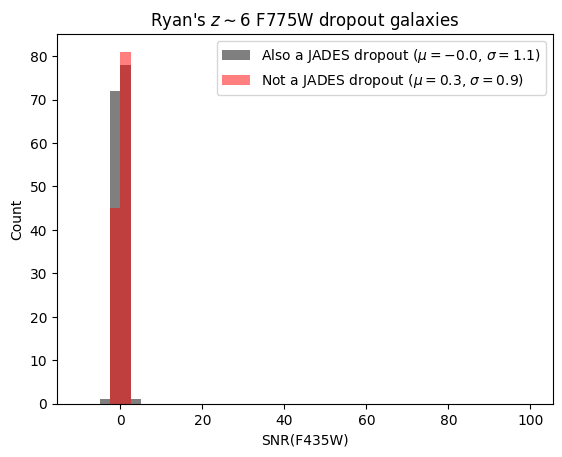

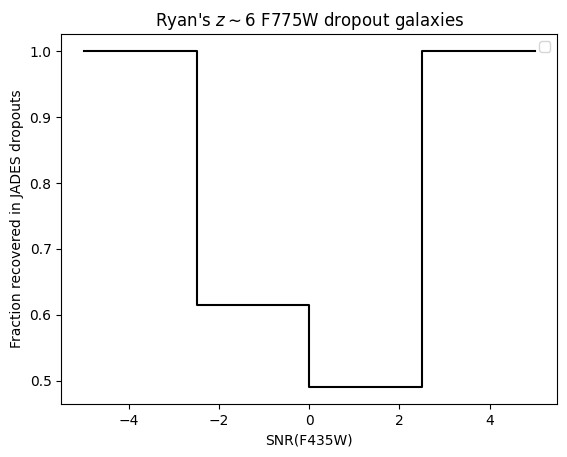

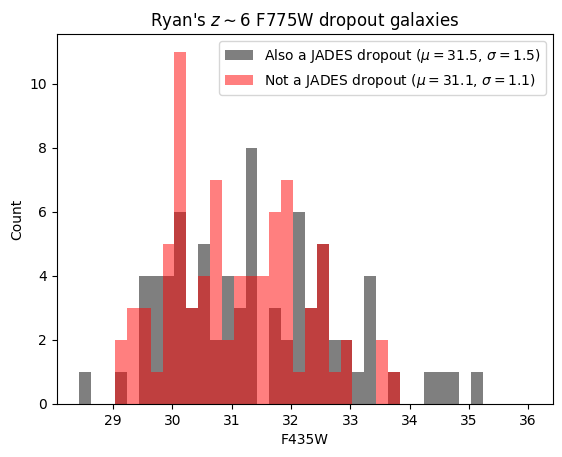

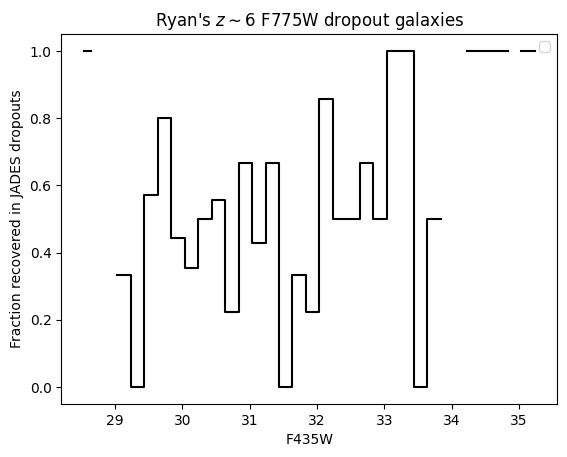

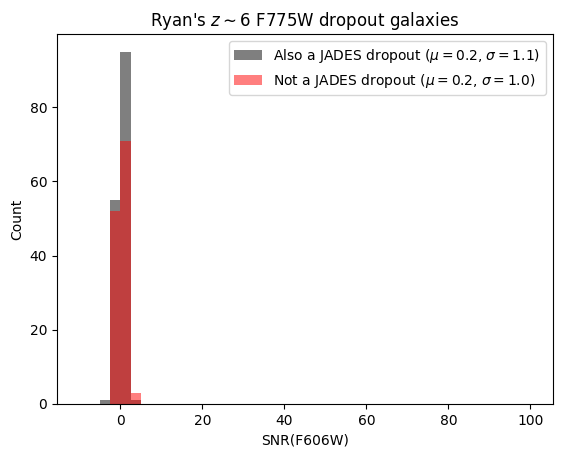

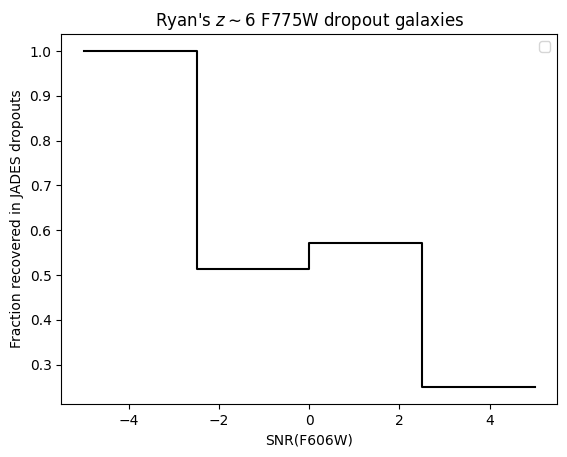

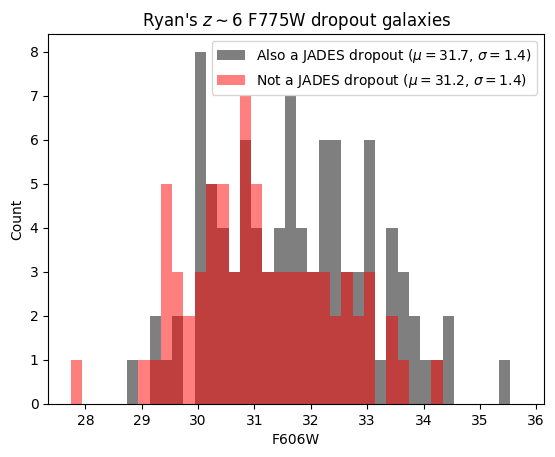

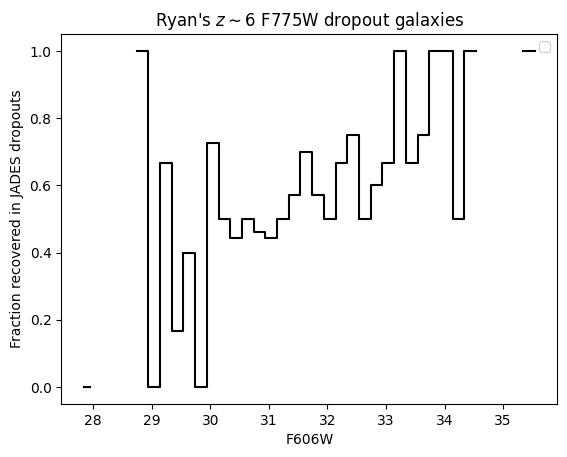

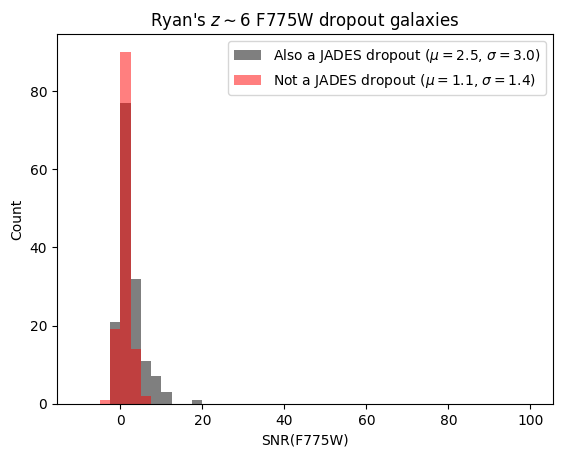

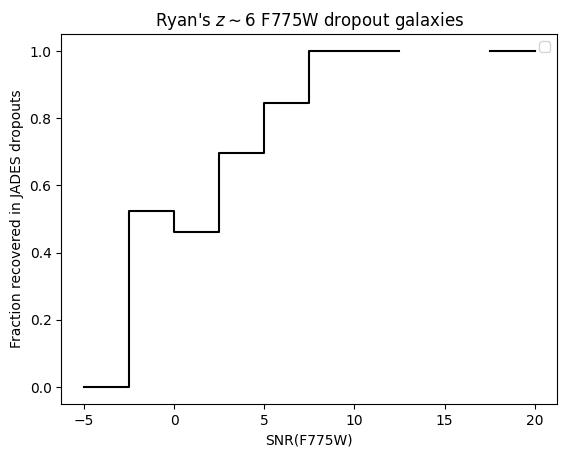

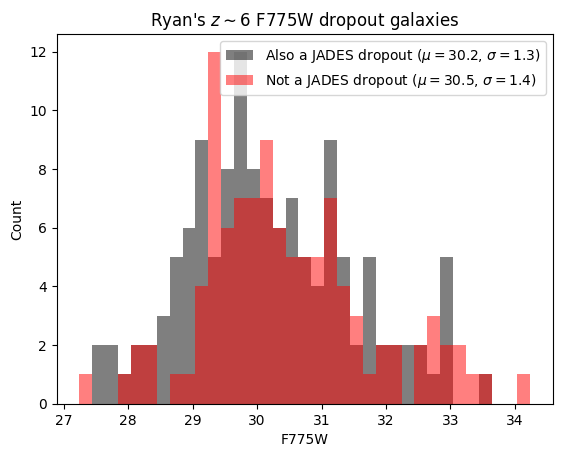

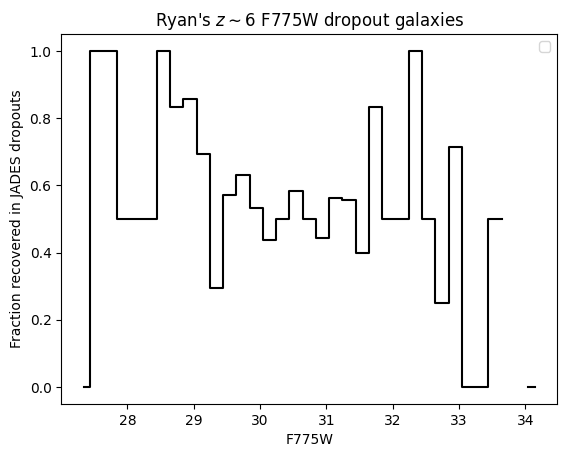

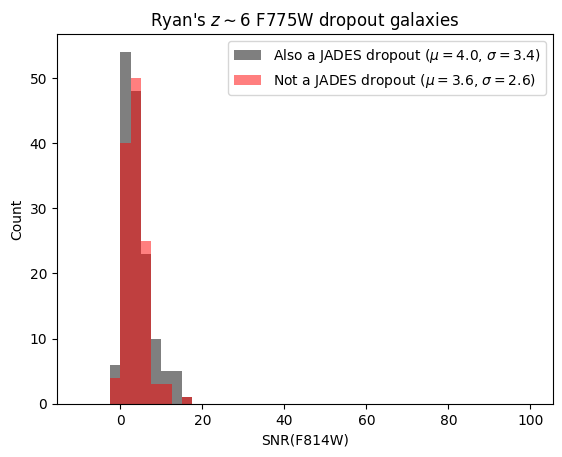

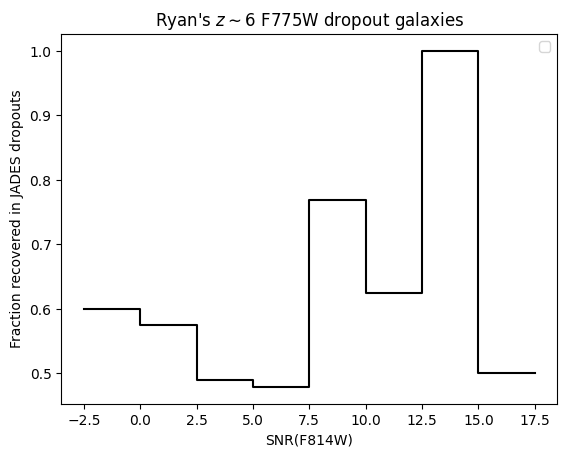

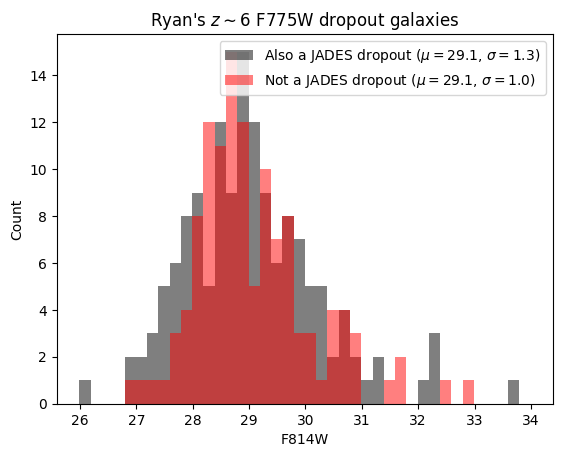

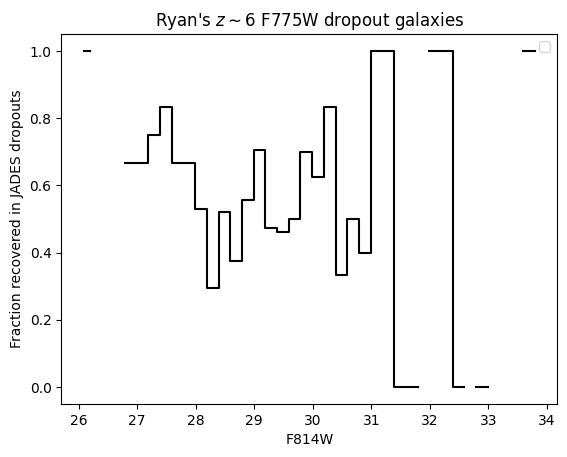

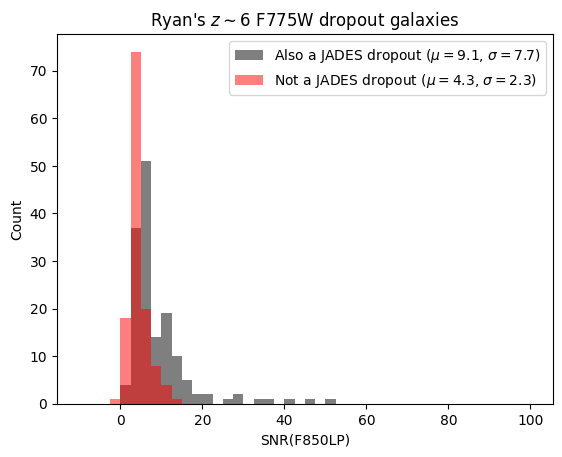

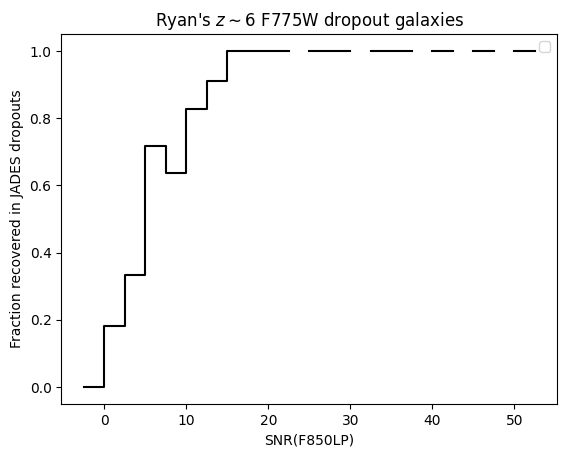

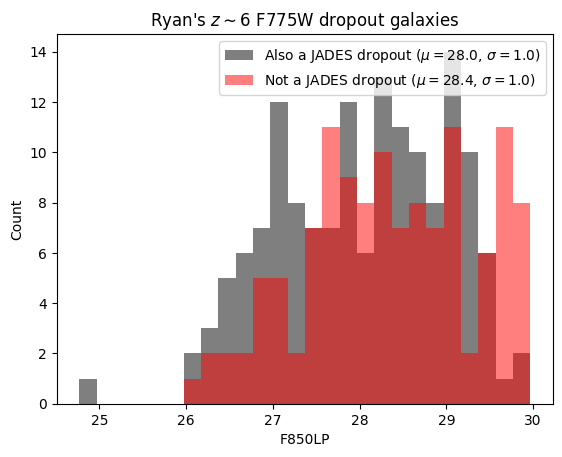

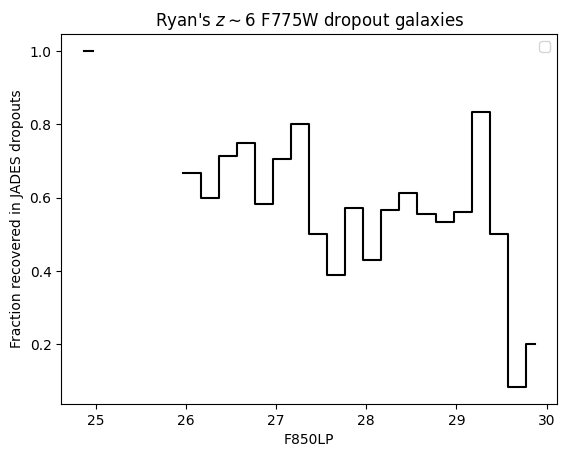

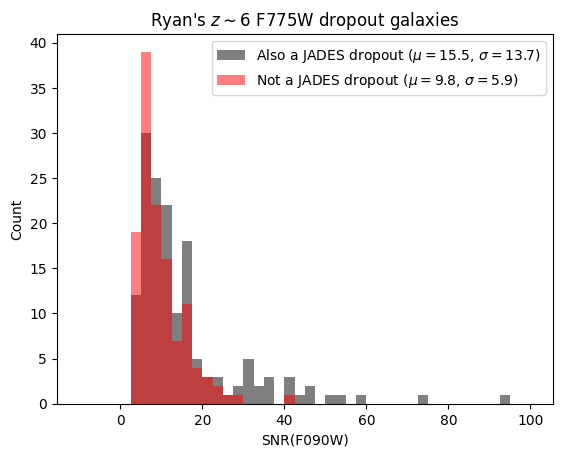

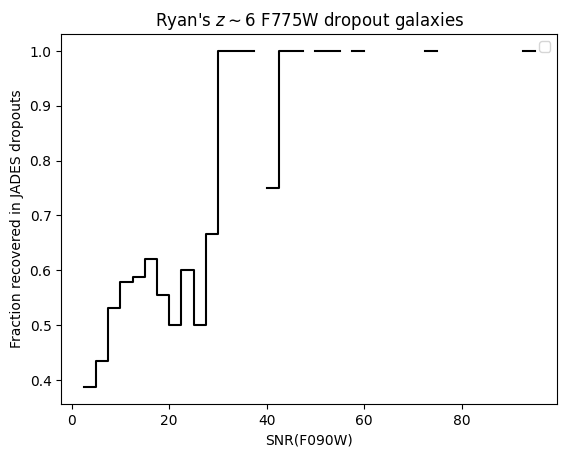

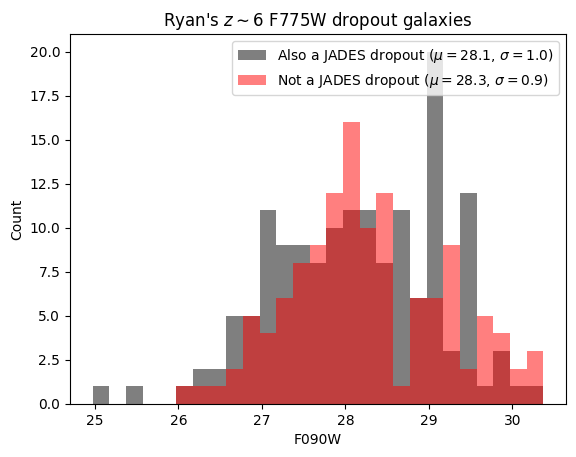

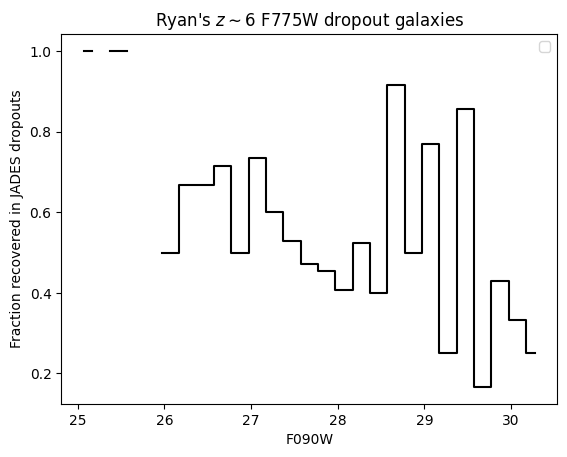

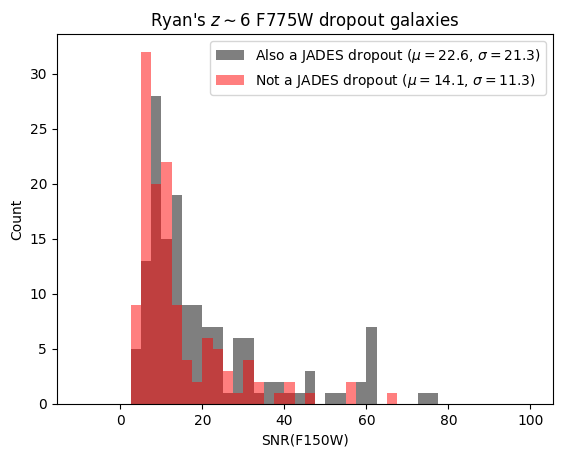

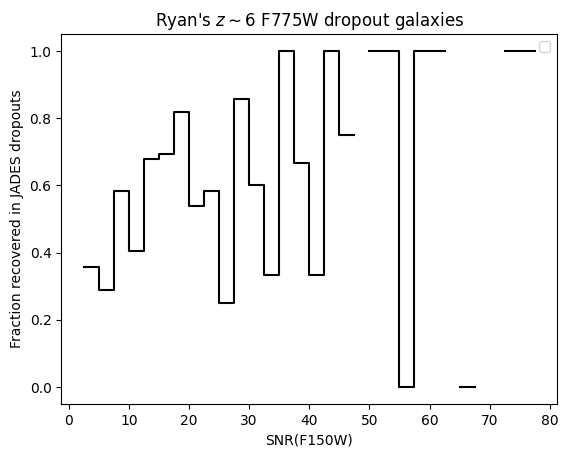

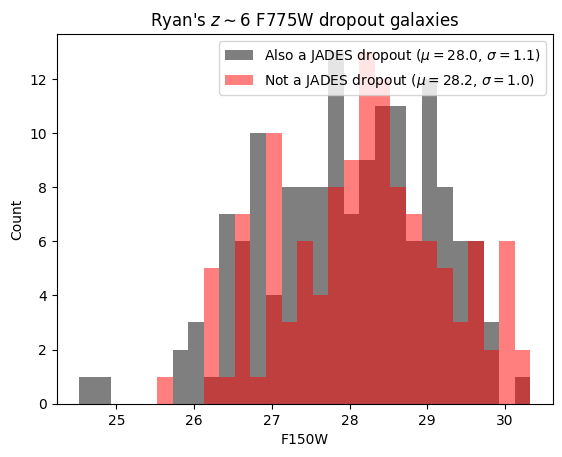

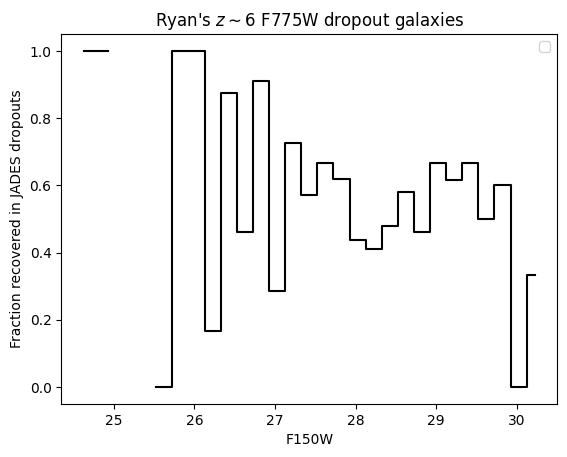

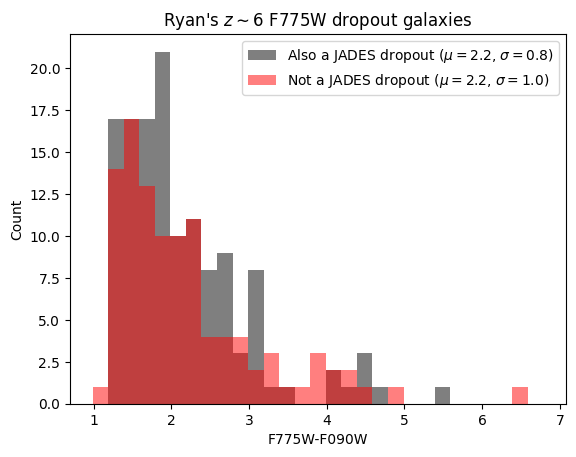

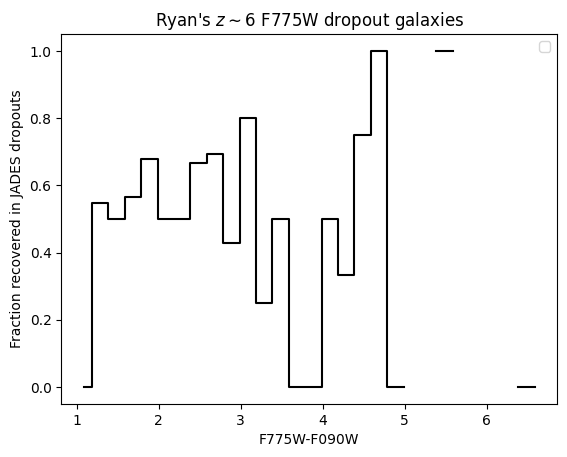

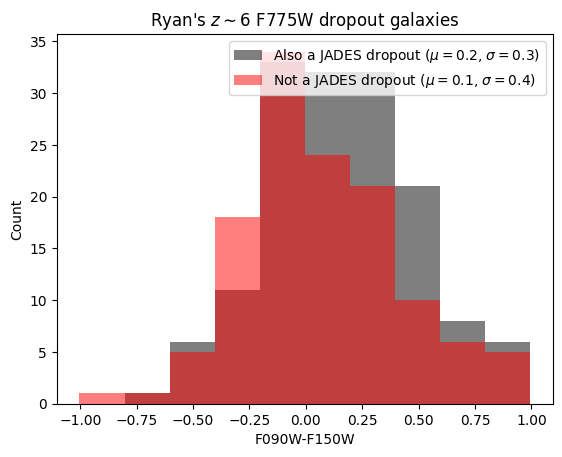

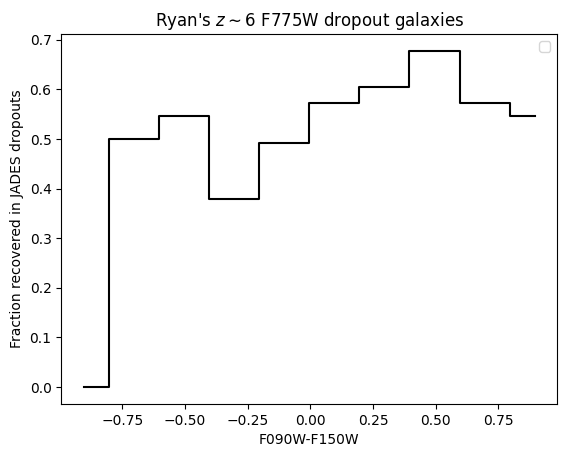

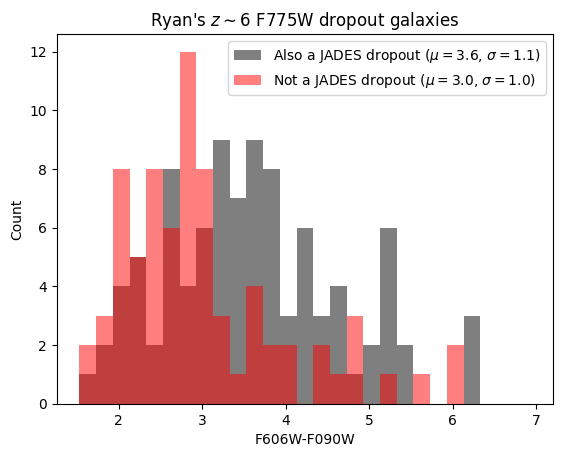

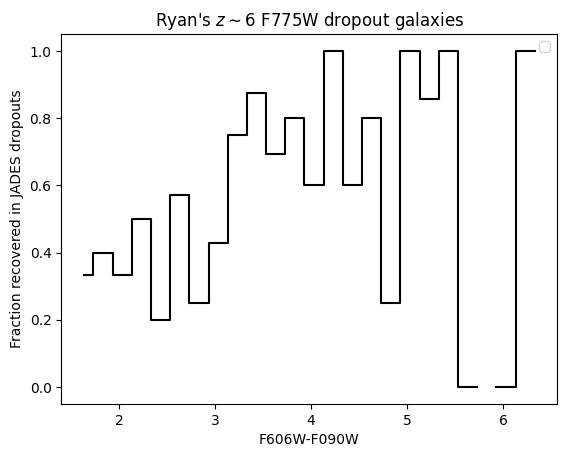

In [ ]:
# Compare the properties of galaxies in Ryan's dropout sample, for those that do and don't also appear in the JADES dropout sample

#catalog_ryan = 'JADES_f775w_dropouts_Endsley2024.fits'
#hdul_ryan = fits.open(catalog_ryan)
#coords_ryan = SkyCoord(ra=hdul_ryan[1].data['RA'] * u.deg, dec=hdul_ryan[1].data['DEC'] * u.deg)

catalog_jades_dropouts = 'data/hlsp_jades_jwst_nircam_goods-n_v1.0_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_init.fits'
hdul_jades_dropouts = fits.open(catalog_jades_dropouts)
#coords_jades = SkyCoord(ra=hdul_jades[1].data['RA'] * u.deg, dec=hdul_jades[1].data['DEC'] * u.deg)
coords_jades_dropouts = SkyCoord(ra=hdul_jades_dropouts['KRON_CONV'].data['RA'] * u.deg, dec=hdul_jades_dropouts['KRON_CONV'].data['DEC'] * u.deg)

#coords_rred = SkyCoord(ra=matches_ryan[:,0] * u.deg, dec=matches_ryan[:,1] * u.deg)

max_sep = 0.1 * u.arcsec

# Find the best matches to the JADES dropouts galaxies in Ryan's catalog
idx_jades, d2d_jades, _ = coords_jades_dropouts.match_to_catalog_sky(coords_ryan)
#idx_dja, d2d_dja, _ = coords_dja.match_to_catalog_sky(coords_ryan)
#idx_rred, d2d_rred, _ = coords_rred.match_to_catalog_sky(coords_ryan)

# Mask out indices that do not satisfy the maximum separation criterion
idx_matches_jades = idx_jades[d2d_jades < max_sep]
#idx_matches_dja = idx_dja[d2d_dja < max_sep]
#idx_matches_rred = idx_rred[d2d_rred < max_sep]

#bins = np.arange(0, 101, 2.5)

#labels = ['DJA', 'JADES', 'Ryan']

#f606w = hdul_ryan[1].data['ACS_F606W']
#f775w = hdul_ryan[1].data['ACS_F775W']
#f814w = hdul_ryan[1].data['ACS_F814W']
#f850lp = hdul_ryan[1].data['ACS_F850LP']

#f090w = hdul_ryan[1].data['NRC_F090W']
#f090w_err = hdul_ryan[1].data['NRC_F090W_err']
#f150w = hdul_ryan[1].data['NRC_F150W']
#f150w_err = hdul_ryan[1].data['NRC_F150W_err']

#f090w_snr = f090w / f090w_err

# For each filter used in the selections
for filter in ['ACS_F435W', 'ACS_F606W', 'ACS_F775W', 'ACS_F814W', 'ACS_F850LP', 'NRC_F090W', 'NRC_F150W']:

    f = hdul_ryan[1].data[filter]
    f_err = hdul_ryan[1].data[f'{filter}_err']

    f_snr = f / f_err

    f = (f * u.nJy).to(u.ABmag).value

    # Make a figure of the SNR of the filter for galaxies also in the JADES dropout sample and those not
    fig, ax = plt.subplots()

    bins = np.arange(-10, 101, 2.5)

    ax.hist(f_snr[idx_matches_jades], bins=bins, label=f'Also a JADES dropout ($\mu={np.nanmean(f_snr[idx_matches_jades]):.1f}$, $\sigma={np.nanstd(f_snr[idx_matches_jades]):.1f}$)', color='black', alpha=0.5)
    ax.hist(np.delete(f_snr, idx_matches_jades), bins=bins, label=f'Not a JADES dropout ($\mu={np.nanmean(np.delete(f_snr, idx_matches_jades)):.1f}$, $\sigma={np.nanstd(np.delete(f_snr, idx_matches_jades)):.1f}$)', color='red', alpha=0.5)

    ax.set_xlabel(f'SNR({filter[4:]})')
    ax.set_ylabel('Count')

    ax.legend(loc='upper right')

    ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/ryan/snr_{filter}.pdf', bbox_inches='tight')

    # Make a figure of the recovery fraction of Ryan's galaxies
    fig, ax = plt.subplots()

    fraction = np.histogram(f_snr[idx_matches_jades], bins)[0] / np.histogram(f_snr, bins)[0]

    ax.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

    ax.set_xlabel(f'SNR({filter[4:]})')
    ax.set_ylabel('Fraction recovered in JADES dropouts')

    ax.legend(loc='upper right')

    ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/ryan/fraction_snr_{filter}.pdf', bbox_inches='tight')

    #bins = np.arange(-10, 101, 1)
    #bins = np.arange(24, 34, 0.2)
    #bins = np.arange(24, 38.1, 0.2)
    bins = np.arange(np.nanmin(f), np.nanmax(f), 0.2)

    fig, ax = plt.subplots()

    ax.hist(f[idx_matches_jades], bins=bins, label=f'Also a JADES dropout ($\mu={np.nanmean(f[idx_matches_jades]):.1f}$, $\sigma={np.nanstd(f[idx_matches_jades]):.1f}$)', color='black', alpha=0.5)
    ax.hist(np.delete(f, idx_matches_jades), label=f'Not a JADES dropout ($\mu={np.nanmean(np.delete(f, idx_matches_jades)):.1f}$, $\sigma={np.nanstd(np.delete(f, idx_matches_jades)):.1f}$)', bins=bins, color='red', alpha=0.5)

    ax.set_xlabel(f'{filter[4:]}')
    ax.set_ylabel('Count')

    ax.legend(loc='upper right')

    ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/ryan/{filter}.pdf', bbox_inches='tight')

    # Make a figure of the recovery fraction of Ryan's galaxies
    fig, ax = plt.subplots()

    fraction = np.histogram(f[idx_matches_jades], bins)[0] / np.histogram(f, bins)[0]

    ax.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

    ax.set_xlabel(f'{filter[4:]}')
    ax.set_ylabel('Fraction recovered in JADES dropouts')

    ax.legend(loc='upper right')

    ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/ryan/fraction_{filter}.pdf', bbox_inches='tight')

f606w = (hdul_ryan[1].data['ACS_F606W'] * u.nJy).to(u.ABmag)
f775w = (hdul_ryan[1].data['ACS_F775W'] * u.nJy).to(u.ABmag)
f090w = (hdul_ryan[1].data['NRC_F090W'] * u.nJy).to(u.ABmag)
f150w = (hdul_ryan[1].data['NRC_F150W'] * u.nJy).to(u.ABmag)

color_1 = f775w - f090w
color_2 = f090w - f150w
color_3 = f606w - f090w

labels_color = ['F775W-F090W', 'F090W-F150W', 'F606W-F090W']

#bins = np.arange(-10, 10.01, 0.1)

for i, color in enumerate([color_1, color_2, color_3]):

    #print(np.nanmin(color), np.nanmax(color))
    bins = np.arange(np.nanmin(color.value[np.isfinite(color.value)]), np.nanmax(color.value[np.isfinite(color.value)]), 0.2)

    fig, ax = plt.subplots()

    # Plot the F115W SNR of my JADES dropouts galaxies that do (and don't) have a match in Ryan's catalog
    ax.hist(color[idx_matches_jades].value, bins, label=f'Also a JADES dropout ($\mu={np.nanmean(color[idx_matches_jades].value):.1f}$, $\sigma={np.nanstd(color[idx_matches_jades].value):.1f}$)', color='black', alpha=0.5)
    ax.hist(np.delete(color, idx_matches_jades).value, bins, label=f'Not a JADES dropout ($\mu={np.nanmean(np.delete(color, idx_matches_jades).value):.1f}$, $\sigma={np.nanstd(np.delete(color, idx_matches_jades).value):.1f}$)', color='red', alpha=0.5)

    ax.set_xlabel(labels_color[i])
    ax.set_ylabel('Count')

    ax.legend(loc='upper right')

    ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/ryan/{labels_color[i]}.pdf', bbox_inches='tight')

    # Make a figure of the recovery fraction of Ryan's galaxies
    fig, ax = plt.subplots()

    fraction = np.histogram(color[idx_matches_jades].value, bins)[0] / np.histogram(color.value, bins)[0]

    ax.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

    ax.set_xlabel(labels_color[i])
    ax.set_ylabel('Fraction recovered in JADES dropouts')

    ax.legend(loc='upper right')

    ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies')

    fig.savefig(f'{figs}/ryan/fraction_{labels_color[i]}.pdf', bbox_inches='tight')

'''
fig, ax = plt.subplots()

ax.scatter(f090w_snr[idxs], ((f775w * u.nJy).to(u.ABmag) - (f090w * u.nJy).to(u.ABmag))[idxs], color='red', alpha=0.5)
ax.scatter(np.delete(f090w_snr, idxs), np.delete(((f775w * u.nJy).to(u.ABmag) - (f090w * u.nJy).to(u.ABmag)), idxs), color='black', alpha=0.5)
'''

In [108]:
# Compare the photometric properties and colors of Ryan's galaxies as they appear in Ryan's catalog and in the JADES catalog

def compare_endsley2024():

    def hist(x, idx, binwidth):#, ax, ax_histx, ax_histy):

        # Create a figure, which doesn't have to be square.
        fig = plt.figure(layout='constrained')

        # Create the main axes
        ax = fig.add_subplot()

        # Create a boolean mask where the AB magnitudes aren't well defined
        mask_finite = np.isfinite(x.value)# & np.isfinite(phot_jades_ABmag.value)

        # Create a boolean mask for the indices that have a coordinate match in the JADES dropout selection
        mask_matches = np.isin(np.arange(len(x)), idx)

        # now determine nice limits by hand:
        #binwidth = 0.25
        x_min = min(x[mask_finite]).value
        x_max = max(x[mask_finite]).value
        lim_lower = (int(x_min / binwidth) - 1) * binwidth
        lim_upper = (int(x_max / binwidth) + 1) * binwidth

        bins = np.arange(lim_lower - binwidth, lim_upper + binwidth, binwidth)

        colors = ['red', 'black']
        labels = ['Both', 'Only E24']

        for i, mask in enumerate([mask_matches, ~mask_matches]):

            x_masked = x[mask_finite & mask].value #[idx_endsley2024][mask_phot[idx_endsley2024]].value

            mean = np.mean(x_masked)
            std = np.std(x_masked)

            ax.hist(x_masked, bins=bins, color=colors[i], alpha=0.5, label=f'{labels[i]} ($N={len(x_masked)}$, $\mu={mean:.1f}$, $\sigma={std:.1f}$)')

        ax.set_ylabel('Count')

        ax.legend(loc='upper right')

        at = AnchoredText(f'Non-finite: {np.sum(~mask_finite)}', loc='upper left', frameon=False)
        ax.add_artist(at)

        # Create a figure, which doesn't have to be square.
        fig_frac = plt.figure(layout='constrained')

        # Create the main axes
        ax_frac = fig_frac.add_subplot()

        fraction = np.histogram(x[mask_finite & mask_matches].value, bins)[0] / np.histogram(x[mask_finite].value, bins)[0]

        ax_frac.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

        ax_frac.set_ylabel('Fraction recovered')

        at = AnchoredText(f'Non-finite: {np.sum(~mask_finite)}', loc='upper left', frameon=False)
        ax_frac.add_artist(at)

        return fig, ax, fig_frac, ax_frac

    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    # Open the Endsley et al. (2024) catalog of F775W dropouts and get their coordinates
    catalog_endsley2024 = f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
    hdul_endsley2024 = fits.open(catalog_endsley2024)
    coords_endsley2024 = SkyCoord(ra=hdul_endsley2024[1].data['RA'] * u.deg, dec=hdul_endsley2024[1].data['DEC'] * u.deg)

    # Open the JADES catalog of F775W dropouts and get their coordinates
    catalog_jades = f'{results}/catalogs/hlsp_jades_jwst_nircam_goods-n_v1.0_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_final.fits'
    hdul_jades = fits.open(catalog_jades)
    coords_jades = SkyCoord(ra=hdul_jades[1].data['RA'] * u.deg, dec=hdul_jades[1].data['DEC'] * u.deg)

    # Get the indices and angular distances of objects in the Endsley et al. (2024) catalog that are the best matches to the galaxies in the JADES F775W dropout selection
    idx_endsley2024, d2d_endsley2024, _ = coords_jades.match_to_catalog_sky(coords_endsley2024)

    # Set the maximum separation between two objects to count as a match
    max_sep = 0.1 * u.arcsec

    # Mask out indices that do not satisfy the maximum separation criterion
    idx_endsley2024 = idx_endsley2024[d2d_endsley2024 < max_sep]

    filters = ['ACS_F435W', 'ACS_F606W', 'ACS_F775W', 'ACS_F814W', 'ACS_F850LP', 
        'NRC_F090W', 'NRC_F115W', 'NRC_F150W', 'NRC_F200W', 'NRC_F277W', 'NRC_F335M', 'NRC_F356W', 'NRC_F410M', 'NRC_F444W']

    # For each filter
    for filter in filters:

        phot_endsley2024_njy = hdul_endsley2024[1].data[filter] * u.nJy #[idx_endsley2024] * u.nJy
        phot_err_endsley2024_njy = hdul_endsley2024[1].data[f'{filter}_err'] * u.nJy #[idx_endsley2024] * u.nJy
        #phot_jades_njy = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S'][idx_jades] * u.nJy
        #phot_err_jades_njy = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S_e'][idx_jades] * u.nJy

        # ----------------------------------------------------
        # Plot the photometries against each other
        # ----------------------------------------------------

        # Plot the photometric distribution of the photometry of Endsley et al. (2024)'s galaxies that also appear in the JADES dropout selection

        # Convert the photometry to AB magnitudes
        phot_endsley2024_ABmag = phot_endsley2024_njy.to(u.ABmag)

        fig, ax, fig_frac, ax_frac = hist(phot_endsley2024_ABmag, idx_endsley2024, 0.25)

        ax.set_xlabel(f'{filter[4:]} (AB mag.) (Endsley et al. (2024))')
        ax_frac.set_xlabel(f'{filter[4:]} (AB mag.) (Endsley et al. (2024))')

        ax.xaxis.set_inverted(True)
        ax_frac.xaxis.set_inverted(True)

        fig.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}.png', dpi=200, bbox_inches='tight')
        fig_frac.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}_frac.png', dpi=200, bbox_inches='tight')

        # ----------------------------------------------------
        # Plot the SNRs of the photometries against each other
        # ----------------------------------------------------

        phot_snr_endsley2024 = phot_endsley2024_njy / phot_err_endsley2024_njy

        fig, ax, fig_frac, ax_frac = hist(phot_snr_endsley2024, idx_endsley2024, 1)

        ax.set_xlabel(f'SNR({filter[4:]}) (Endsley et al. (2024))')
        ax_frac.set_xlabel(f'SNR({filter[4:]}) (Endsley et al. (2024))')
        
        fig.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}_snr.png', dpi=200, bbox_inches='tight')
        fig_frac.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}_snr_frac.png', dpi=200, bbox_inches='tight')

    colors = [['ACS_F775W','NRC_F090W'], ['NRC_F090W','NRC_F150W'], ['ACS_F606W','NRC_F090W']]

    for color in colors:

        phot_sw_endsley2024_njy = hdul_endsley2024[1].data[color[0]] * u.nJy
        phot_lw_endsley2024_njy = hdul_endsley2024[1].data[color[1]] * u.nJy
        
        phot_sw_endsley2024_ABmag = phot_sw_endsley2024_njy.to(u.ABmag)
        phot_lw_endsley2024_ABmag = phot_lw_endsley2024_njy.to(u.ABmag)

        color_endsley2024 = phot_sw_endsley2024_ABmag - phot_lw_endsley2024_ABmag

        fig, ax, fig_frac, ax_frac = hist(color_endsley2024, idx_endsley2024, 0.25)

        ax.set_xlabel(f'{color[0][4:]}$-${color[1][4:]} (AB mag.) (Endsley et al. (2024))')
        ax_frac.set_xlabel(f'{color[0][4:]}$-${color[1][4:]} (AB mag.) (Endsley et al. (2024))')

        fig.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{color[0][4:]}-{color[1][4:]}.png', dpi=200, bbox_inches='tight')
        fig_frac.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{color[0][4:]}-{color[1][4:]}_frac.png', dpi=200, bbox_inches='tight')

<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\s'
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_27161/3272536273.py:38: SyntaxWarning: invalid escape sequence '\m'
  ax.hist(x_masked, bins=bins, color=colors[i], alpha=0.5, label=f'{labels[i]} ($N={len(x_masked)}$, $\mu={mean:.1f}$, $\sigma={std:.1f}$)')
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_27161/3272536273.py:38: SyntaxWarning: invalid escape sequence '\s'
  ax.hist(x_masked, bins=bins, color=colors[i], alpha=0.5, label=f'{labels[i]} ($N={len(x_masked)}$, $\mu={mean:.1f}$, $\sigma={std:.1f}$)')


In [ ]:
def compare_jades():

    def hist(x, idx, binwidth):#, ax, ax_histx, ax_histy):

        # Create a figure, which doesn't have to be square.
        fig = plt.figure(layout='constrained')

        # Create the main axes
        ax = fig.add_subplot()

        # Create a boolean mask where the AB magnitudes aren't well defined
        mask_finite = np.isfinite(x.value)# & np.isfinite(phot_jades_ABmag.value)

        # Create a boolean mask for the indices that have a coordinate match in the JADES dropout selection
        mask_matches = np.isin(np.arange(len(x)), idx)

        # now determine nice limits by hand:
        #binwidth = 0.25
        x_min = min(x[mask_finite]).value
        x_max = max(x[mask_finite]).value
        lim_lower = (int(x_min / binwidth) - 1) * binwidth
        lim_upper = (int(x_max / binwidth) + 1) * binwidth

        bins = np.arange(lim_lower - binwidth, lim_upper + binwidth, binwidth)

        colors = ['red', 'black']
        labels = ['Both', 'Only E24']

        for i, mask in enumerate([mask_matches, ~mask_matches]):

            x_masked = x[mask_finite & mask].value #[idx_endsley2024][mask_phot[idx_endsley2024]].value

            mean = np.mean(x_masked)
            std = np.std(x_masked)

            ax.hist(x_masked, bins=bins, color=colors[i], alpha=0.5, label=f'{labels[i]} ($N={len(x_masked)}$, $\mu={mean:.1f}$, $\sigma={std:.1f}$)')

        ax.set_ylabel('Count')

        ax.legend(loc='upper right')

        at = AnchoredText(f'Non-finite: {np.sum(~mask_finite)}', loc='upper left', frameon=False)
        ax.add_artist(at)

        # Create a figure, which doesn't have to be square.
        fig_frac = plt.figure(layout='constrained')

        # Create the main axes
        ax_frac = fig_frac.add_subplot()

        fraction = np.histogram(x[mask_finite & mask_matches].value, bins)[0] / np.histogram(x[mask_finite].value, bins)[0]

        ax_frac.plot((bins[:-1] + bins[1:]) / 2, fraction, ds='steps-mid', color='black')

        ax_frac.set_ylabel('Fraction recovered')

        at = AnchoredText(f'Non-finite: {np.sum(~mask_finite)}', loc='upper left', frameon=False)
        ax_frac.add_artist(at)

        return fig, ax, fig_frac, ax_frac

    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    # Open the Endsley et al. (2024) catalog of F775W dropouts and get their coordinates
    catalog_endsley2024 = f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
    hdul_endsley2024 = fits.open(catalog_endsley2024)
    coords_endsley2024 = SkyCoord(ra=hdul_endsley2024[1].data['RA'] * u.deg, dec=hdul_endsley2024[1].data['DEC'] * u.deg)

    # Open the JADES catalog of F775W dropouts and get their coordinates
    catalog_jades = f'{results}/catalogs/hlsp_jades_jwst_nircam_goods-n_v1.0_goods-s-deep_v2.0_photometry_catalog_f775w_dropouts_final.fits'
    hdul_jades = fits.open(catalog_jades)
    coords_jades = SkyCoord(ra=hdul_jades[1].data['RA'] * u.deg, dec=hdul_jades[1].data['DEC'] * u.deg)

    # Get the indices and angular distances of objects in the Endsley et al. (2024) catalog that are the best matches to the galaxies in the JADES F775W dropout selection
    idx_jades, d2d_jades, _ = coords_endsley2024.match_to_catalog_sky(coords_jades)

    # Set the maximum separation between two objects to count as a match
    max_sep = 0.1 * u.arcsec

    # Mask out indices that do not satisfy the maximum separation criterion
    idx_jades = idx_jades[d2d_jades < max_sep]

    filters = ['ACS_F435W', 'ACS_F606W', 'ACS_F775W', 'ACS_F814W', 'ACS_F850LP', 
        'NRC_F090W', 'NRC_F115W', 'NRC_F150W', 'NRC_F200W', 'NRC_F277W', 'NRC_F335M', 'NRC_F356W', 'NRC_F410M', 'NRC_F444W']

    # For each filter
    for filter in filters:

        #phot_endsley2024_njy = hdul_endsley2024[1].data[filter] * u.nJy #[idx_endsley2024] * u.nJy
        #phot_err_endsley2024_njy = hdul_endsley2024[1].data[f'{filter}_err'] * u.nJy #[idx_endsley2024] * u.nJy
        phot_jades_njy = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S'] * u.nJy #[idx_jades] * u.nJy
        phot_err_jades_njy = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S_e'] * u.nJy #[idx_jades] * u.nJy

        # ----------------------------------------------------
        # Plot the photometries against each other
        # ----------------------------------------------------

        # Plot the photometric distribution of the photometry of Endsley et al. (2024)'s galaxies that also appear in the JADES dropout selection

        # Convert the photometry to AB magnitudes
        phot_jades_ABmag = phot_endsley2024_njy.to(u.ABmag)

        fig, ax, fig_frac, ax_frac = hist(phot_endsley2024_ABmag, idx_endsley2024, 0.25)

        ax.set_xlabel(f'{filter[4:]} (AB mag.) (Endsley et al. (2024))')
        ax_frac.set_xlabel(f'{filter[4:]} (AB mag.) (Endsley et al. (2024))')

        ax.xaxis.set_inverted(True)
        ax_frac.xaxis.set_inverted(True)

        fig.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}.png', dpi=200, bbox_inches='tight')
        fig_frac.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}_frac.png', dpi=200, bbox_inches='tight')

        # ----------------------------------------------------
        # Plot the SNRs of the photometries against each other
        # ----------------------------------------------------

        phot_snr_endsley2024 = phot_endsley2024_njy / phot_err_endsley2024_njy

        fig, ax, fig_frac, ax_frac = hist(phot_snr_endsley2024, idx_endsley2024, 1)

        ax.set_xlabel(f'SNR({filter[4:]}) (Endsley et al. (2024))')
        ax_frac.set_xlabel(f'SNR({filter[4:]}) (Endsley et al. (2024))')
        
        fig.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}_snr.png', dpi=200, bbox_inches='tight')
        fig_frac.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{filter[4:]}_snr_frac.png', dpi=200, bbox_inches='tight')

    colors = [['ACS_F775W','NRC_F090W'], ['NRC_F090W','NRC_F150W'], ['ACS_F606W','NRC_F090W']]

    for color in colors:

        phot_sw_endsley2024_njy = hdul_endsley2024[1].data[color[0]] * u.nJy
        phot_lw_endsley2024_njy = hdul_endsley2024[1].data[color[1]] * u.nJy
        
        phot_sw_endsley2024_ABmag = phot_sw_endsley2024_njy.to(u.ABmag)
        phot_lw_endsley2024_ABmag = phot_lw_endsley2024_njy.to(u.ABmag)

        color_endsley2024 = phot_sw_endsley2024_ABmag - phot_lw_endsley2024_ABmag

        fig, ax, fig_frac, ax_frac = hist(color_endsley2024, idx_endsley2024, 0.25)

        ax.set_xlabel(f'{color[0][4:]}$-${color[1][4:]} (AB mag.) (Endsley et al. (2024))')
        ax_frac.set_xlabel(f'{color[0][4:]}$-${color[1][4:]} (AB mag.) (Endsley et al. (2024))')

        fig.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{color[0][4:]}-{color[1][4:]}.png', dpi=200, bbox_inches='tight')
        fig_frac.savefig(f'{figs}/photometry_comparison/endsley2024/endsley2024_f775w_dropouts_{color[0][4:]}-{color[1][4:]}_frac.png', dpi=200, bbox_inches='tight')

In [16]:
# Compare the photometric properties and colors of Ryan's galaxies as they appear in Ryan's catalog and in the JADES catalog

def compare_catalog_endsley2024():

    def scatter_hist(x, y, binwidth, fig, ax):#, ax, ax_histx, ax_histy):

        # Set an equal aspect ratio
        ax.set_aspect('equal')

        # Create marginal axes, which have 25% of the size of the main axes.  Note that
        # the inset axes are positioned *outside* (on the right and the top) of the
        # main axes, by specifying axes coordinates greater than 1.  Axes coordinates
        # less than 0 would likewise specify positions on the left and the bottom of
        # the main axes
        ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
        ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)

        # no labels
        ax_histx.tick_params(axis="x", labelbottom=False)
        ax_histy.tick_params(axis="y", labelleft=False)

        # the scatter plot:
        ax.scatter(x, y)

        # now determine nice limits by hand:
        #binwidth = 0.25
        xymin = min(np.min(x), np.min(y))
        xymax = max(np.max(x), np.max(y))
        lim_lower = (int(xymin/binwidth) - 1) * binwidth
        lim_upper = (int(xymax/binwidth) + 1) * binwidth

        bins = np.arange(lim_lower - binwidth, lim_upper + binwidth, binwidth)
        ax_histx.hist(x, bins=bins)
        ax_histy.hist(y, bins=bins, orientation='horizontal')

        ax_histx.set_ylabel('Count')
        ax_histy.set_xlabel('Count')

        x_mean = np.mean(x)
        x_std = np.std(x)
        y_mean = np.mean(y)
        y_std = np.std(y)

        at_x = AnchoredText(f'$\mu={x_mean:.1f}$\n$\sigma={x_std:.1f}$', loc='upper right', frameon=False)
        at_y = AnchoredText(f'$\mu={y_mean:.1f}$\n$\sigma={y_std:.1f}$', loc='upper left', frameon=False)

        ax_histx.add_artist(at_x)
        ax_histy.add_artist(at_y)

        #ax.axline((30,30), slope=1, color='red', linestyle='dashed')

    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    #catalog_ryan = 'JADES_f775w_dropouts_Endsley2024.fits'
    #hdul_ryan = fits.open(catalog_ryan)
    #coords_ryan = SkyCoord(ra=hdul_ryan[1].data['RA'] * u.deg, dec=hdul_ryan[1].data['DEC'] * u.deg)

    catalog_endsley2024 = f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
    hdul_endsley2024 = fits.open(catalog_endsley2024)
    coords_endsley2024 = SkyCoord(ra=hdul_endsley2024[1].data['RA'] * u.deg, dec=hdul_endsley2024[1].data['DEC'] * u.deg)

    catalog_jades = f'{results}/catalogs/hlsp_jades_jwst_nircam_goods-n_v1.0_goods-s-deep_v2.0_photometry_catalog.fits'
    hdul_jades = fits.open(catalog_jades)
    coords_jades = SkyCoord(ra=hdul_jades['KRON_CONV'].data['RA'] * u.deg, dec=hdul_jades['KRON_CONV'].data['DEC'] * u.deg)

    #coords_rred = SkyCoord(ra=matches_ryan[:,0] * u.deg, dec=matches_ryan[:,1] * u.deg)

    #max_sep = 0.1 * u.arcsec

    # Find the best matches to Ryan's galaxies in the JADES catalog
    idx_jades, d2d_jades, _ = coords_endsley2024.match_to_catalog_sky(coords_jades)
    idx_endsley2024, d2d_endsley2024, _ = coords_jades[idx_jades].match_to_catalog_sky(coords_endsley2024)
    #idx_ryan, d2d_ryan, _ = 

    #idx_dja, d2d_dja, _ = coords_dja.match_to_catalog_sky(coords_ryan)
    #idx_rred, d2d_rred, _ = coords_rred.match_to_catalog_sky(coords_ryan)

    max_sep = 0.1 * u.arcsec

    # Mask out indices that do not satisfy the maximum separation criterion
    idx_jades = idx_jades[d2d_jades < max_sep]
    idx_endsley2024 = idx_endsley2024[d2d_endsley2024 < max_sep]

    filters = ['ACS_F435W', 'ACS_F606W', 'ACS_F775W', 'ACS_F814W', 'ACS_F850LP', 
        'NRC_F090W', 'NRC_F115W', 'NRC_F150W', 'NRC_F200W', 'NRC_F277W', 'NRC_F335M', 'NRC_F356W', 'NRC_F410M', 'NRC_F444W']

    for filter in filters:

        # Create a figure, which doesn't have to be square.
        #fig = plt.figure(layout='constrained')

        ## Create the main axes
        #ax = fig.add_subplot()

        #fig_snr = plt.figure(layout='constrained')
        #ax_snr = fig_snr.add_subplot()

        # Set an equal aspect ratio
        #ax.set_aspect('equal')

        # Create marginal axes, which have 25% of the size of the main axes.  Note that
        # the inset axes are positioned *outside* (on the right and the top) of the
        # main axes, by specifying axes coordinates greater than 1.  Axes coordinates
        # less than 0 would likewise specify positions on the left and the bottom of
        # the main axes
        #ax_histx = ax.inset_axes([0, 1.05, 1, 0.25], sharex=ax)
        #ax_histy = ax.inset_axes([1.05, 0, 0.25, 1], sharey=ax)

        phot_endsley2024_njy = hdul_endsley2024[1].data[filter][idx_endsley2024] * u.nJy
        phot_err_endsley2024_njy = hdul_endsley2024[1].data[f'{filter}_err'][idx_endsley2024] * u.nJy
        phot_jades_njy = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S'][idx_jades] * u.nJy
        phot_err_jades_njy = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S_e'][idx_jades] * u.nJy

        # ----------------------------------------------------
        # Plot the photometries against each other
        # ----------------------------------------------------

        # Create a figure, which doesn't have to be square.
        fig = plt.figure(layout='constrained')

        # Create the main axes
        ax = fig.add_subplot()

        # Convert the photometry to AB magnitudes
        phot_endsley2024_ABmag = phot_endsley2024_njy.to(u.ABmag)
        phot_jades_ABmag = phot_jades_njy.to(u.ABmag)

        mask_phot = np.isfinite(phot_endsley2024_ABmag.value) & np.isfinite(phot_jades_ABmag.value)

        phot_endsley2024_ABmag = phot_endsley2024_ABmag[mask_phot]
        phot_jades_ABmag = phot_jades_ABmag[mask_phot]

        # Draw the scatter plot and marginals
        scatter_hist(phot_jades_ABmag.value, phot_endsley2024_ABmag.value, 0.25, fig, ax)#, ax, ax_histx, ax_histy)

        ax.axline((30,30), slope=1, color='red', linestyle='dashed')

        ax.set_xlabel(f'{filter[4:]} (AB mag.) (JADES)')
        ax.set_ylabel(f'{filter[4:]} (AB mag.) (Endsley et al. 2024)')

        at = AnchoredText(f'Non-finite: {np.sum(~mask_phot)}', loc='upper left', frameon=False)
        ax.add_artist(at)

        fig.savefig(f'{figs}/photometry_comparison/endsley2024_f775w_dropouts_vs_jades_{filter}.pdf', bbox_inches='tight')

        # ----------------------------------------------------
        # Plot the SNRs of the photometries against each other
        # ----------------------------------------------------

        fig_snr = plt.figure(layout='constrained')
        ax_snr = fig_snr.add_subplot()

        phot_snr_endsley2024 = phot_endsley2024_njy / phot_err_endsley2024_njy
        phot_snr_jades = phot_jades_njy / phot_err_jades_njy

        mask_snr = np.isfinite(phot_snr_endsley2024) & np.isfinite(phot_snr_jades)

        phot_snr_endsley2024 = phot_snr_endsley2024[mask_snr]
        phot_snr_jades = phot_snr_jades[mask_snr]

        scatter_hist(phot_snr_jades, phot_snr_endsley2024, 1, fig_snr, ax_snr)#, ax, ax_histx, ax_histy)

        ax_snr.axline((0,0), slope=1, color='red', linestyle='dashed')

        ax_snr.set_xlabel(f'SNR({filter[4:]}) (JADES)')
        ax_snr.set_ylabel(f'SNR({filter[4:]}) (Endsley et al. 2024)')

        at = AnchoredText(f'Non-finite: {np.sum(~mask_snr)}', loc='upper left', frameon=False)
        ax_snr.add_artist(at)

        fig_snr.savefig(f'{figs}/photometry_comparison/endsley2024_f775w_dropouts_vs_jades_{filter}_snr.pdf', bbox_inches='tight')

    colors = [['ACS_F775W','NRC_F090W'], ['NRC_F090W','NRC_F150W'], ['ACS_F606W','NRC_F090W']]

    for color in colors:

        phot_sw_endsley2024_njy = hdul_endsley2024[1].data[color[0]][idx_endsley2024] * u.nJy
        phot_lw_endsley2024_njy = hdul_endsley2024[1].data[color[1]][idx_endsley2024] * u.nJy
        #phot_err_endsley2024_njy = hdul_endsley2024[1].data[f'{filter}_err'][idx_endsley2024] * u.nJy
        phot_sw_jades_njy = hdul_jades['KRON_CONV'].data[f'{color[0][4:]}_KRON_S'][idx_jades] * u.nJy
        phot_lw_jades_njy = hdul_jades['KRON_CONV'].data[f'{color[1][4:]}_KRON_S'][idx_jades] * u.nJy
        #phot_err_jades_njy = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S_e'][idx_jades] * u.nJy

        phot_sw_endsley2024_ABmag = phot_sw_endsley2024_njy.to(u.ABmag)
        phot_lw_endsley2024_ABmag = phot_lw_endsley2024_njy.to(u.ABmag)
        phot_sw_jades_ABmag = phot_sw_jades_njy.to(u.ABmag)
        phot_lw_jades_ABmag = phot_lw_jades_njy.to(u.ABmag)

        color_endsley2024 = phot_sw_endsley2024_ABmag - phot_lw_endsley2024_ABmag
        color_jades = phot_sw_jades_ABmag - phot_lw_jades_ABmag

        mask = np.isfinite(color_endsley2024.value) & np.isfinite(color_jades.value)

        # Create a figure, which doesn't have to be square.
        fig = plt.figure(layout='constrained')

        # Create the main axes
        ax = fig.add_subplot()

        # Convert the photometry to AB magnitudes
        #phot_endsley2024_ABmag = phot_endsley2024_njy.to(u.ABmag)
        #phot_jades_ABmag = phot_jades_njy.to(u.ABmag)

        #mask_phot = np.isfinite(phot_endsley2024_ABmag.value) & np.isfinite(phot_jades_ABmag.value)

        #phot_endsley2024_ABmag = phot_endsley2024_ABmag[mask_phot]
        #phot_jades_ABmag = phot_jades_ABmag[mask_phot]

        # Draw the scatter plot and marginals
        scatter_hist(color_jades.value[mask], color_endsley2024.value[mask], 0.25, fig, ax)#, ax, ax_histx, ax_histy)

        ax.axline((1,1), slope=1, color='red', linestyle='dashed')

        ax.set_xlabel(f'{color[0][4:]}$-${color[1][4:]} (AB mag.) (JADES)')
        ax.set_ylabel(f'{color[0][4:]}$-${color[1][4:]} (AB mag.) (Endsley et al. 2024)')

        at = AnchoredText(f'Non-finite: {np.sum(~mask)}', loc='upper left', frameon=False)
        ax.add_artist(at)

        fig.savefig(f'{figs}/photometry_comparison/endsley2024_f775w_dropouts_vs_jades_{color[0]}_{color[1]}_color.pdf', bbox_inches='tight')

<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_7845/328257296.py:44: SyntaxWarning: invalid escape sequence '\m'
  at_x = AnchoredText(f'$\mu={x_mean:.1f}$\n$\sigma={x_std:.1f}$', loc='upper right', frameon=False)
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_7845/328257296.py:44: SyntaxWarning: invalid escape sequence '\s'
  at_x = AnchoredText(f'$\mu={x_mean:.1f}$\n$\sigma={x_std:.1f}$', loc='upper right', frameon=False)
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_7845/328257296.py:45: SyntaxWarning: invalid escape sequence '\m'
  at_y = Anchor

In [ ]:

        #f_jades = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S'][idx_jades_matches]
        #f_ryan = hdul_ryan[1].data[filter][idx_ryan_matches]

        #f_jades_err = hdul_jades['KRON_CONV'].data[f'{filter[4:]}_KRON_S_e'][idx_jades_matches]
        #f_ryan_err = hdul_ryan[1].data[f'{filter}_err'][idx_ryan_matches]

        '''
        f_jades_snr = f_jades / f_jades_err
        f_ryan_snr = f_ryan / f_ryan_err

        f_jades = (f_jades * u.nJy).to(u.ABmag)
        f_ryan = (f_ryan * u.nJy).to(u.ABmag)

        fig, ax = plt.subplots()

        bins = np.arange(-10, 101, 2.5)

        ax.hist(f_jades_snr, bins=bins, label=f'JADES ($\mu={np.nanmean(f_jades_snr):.1f}$, $\sigma={np.nanstd(f_jades_snr):.1f}$)', color='black', alpha=0.5)
        ax.hist(f_ryan_snr, bins=bins, label=f'Ryan ($\mu={np.nanmean(f_ryan_snr):.1f}$, $\sigma={np.nanstd(f_ryan_snr):.1f}$)', color='red', alpha=0.5)

        ax.set_xlabel(f'SNR({filter[4:]})')
        ax.set_ylabel('Count')

        ax.legend(loc='upper right')

        ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies that also appear in JADES')

        fig.savefig(f'{figs}/both/snr_{filter}.pdf', bbox_inches='tight')

        fig, ax = plt.subplots()

        limits = np.array([f_jades.value, f_ryan.value]).flatten()
        #print(limits)

        bins = np.arange(np.nanmin(limits[np.isfinite(limits)]), np.nanmax(limits[np.isfinite(limits)]), 0.2)

        ax.hist(f_jades.value, bins=bins, label=f'JADES ($\mu={np.nanmean(f_jades.value):.1f}$, $\sigma={np.nanstd(f_jades.value):.1f}$)', color='black', alpha=0.5)
        ax.hist(f_ryan.value, bins=bins, label=f'Ryan ($\mu={np.nanmean(f_ryan.value):.1f}$, $\sigma={np.nanstd(f_ryan.value):.1f}$)', color='red', alpha=0.5)

        ax.set_xlabel(f'{filter[4:]}')
        ax.set_ylabel('Count')

        ax.legend(loc='upper right')

        ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies that also appear in JADES')

        fig.savefig(f'{figs}/both/{filter}.pdf', bbox_inches='tight')
        '''

    #f606w = (hdul_ryan[1].data['ACS_F606W'] * u.nJy).to(u.ABmag)
    #f775w = (hdul_ryan[1].data['ACS_F775W'] * u.nJy).to(u.ABmag)
    #f090w = (hdul_ryan[1].data['NRC_F090W'] * u.nJy).to(u.ABmag)
    #f150w = (hdul_ryan[1].data['NRC_F150W'] * u.nJy).to(u.ABmag)

    #color_1 = f775w - f090w
    #color_2 = f090w - f150w
    #color_3 = f606w - f090w

    '''
    colors = [['ACS_F775W', 'NRC_F090W'], ['NRC_F090W', 'NRC_F150W'], ['ACS_F606W', 'NRC_F090W']]

    labels_color = ['F775W-F090W', 'F090W-F150W', 'F606W-F090W']

    bins = np.arange(-10, 10.01, 0.1)

    for i, color in enumerate(colors):

        color_jades = (hdul_jades['KRON_CONV'].data[f'{color[0][4:]}_KRON_S'] * u.nJy).to(u.ABmag) - (hdul_jades['KRON_CONV'].data[f'{color[1][4:]}_KRON_S'] * u.nJy).to(u.ABmag)
        color_ryan = (hdul_ryan[1].data[color[0]] * u.nJy).to(u.ABmag) - (hdul_ryan[1].data[color[1]] * u.nJy).to(u.ABmag)

        color_jades = color_jades[idx_jades_matches]
        color_ryan = color_ryan[idx_ryan_matches]

        #print(labels_color[i])
        #print(np.sum((hdul_jades[1].data[f'{color[0][4:]}_KRON_S'][idx_jades_matches] * u.nJy) <= 0))
        #print(np.sum(np.isnan((hdul_jades[1].data[f'{color[0][4:]}_KRON_S'][idx_jades_matches] * u.nJy).to(u.ABmag))))
        #print(len(color_jades), np.sum(np.isnan(color_jades)))
        #print(len(color_ryan), np.sum(np.isnan(color_ryan)))

        color_jades = color_jades[~np.isinf(color_jades)]
        color_ryan = color_ryan[~np.isinf(color_ryan)]

        #print(color_jades)
        #print(color_ryan)
        #print(np.append(color_jades.value, color_ryan.value))
        #print(np.array([color_jades.value, color_ryan.value]))
        #print(np.array([color_jades.value, color_ryan.value]).flatten())

        limits = np.append(color_jades.value, color_ryan.value)

        bins = np.arange(np.nanmin(limits), np.nanmax(limits), 0.2)

        fig, ax = plt.subplots()

        ax.hist(color_jades.value, bins, label=f'JADES ($\mu={np.nanmean(color_jades.value):.1f}$, $\sigma={np.nanstd(color_jades.value):.1f}$)', color='black', alpha=0.5)
        ax.hist(color_ryan.value, bins, label=f'Ryan ($\mu={np.nanmean(color_ryan.value):.1f}$, $\sigma={np.nanstd(color_ryan.value):.1f}$)', color='red', alpha=0.5)

        ax.set_xlabel(labels_color[i])
        ax.set_ylabel('Count')

        ax.legend(loc='upper right')

        ax.set_title('Ryan\'s $z\sim6$ F775W dropout galaxies that also appear in JADES')

        fig.savefig(f'{figs}/both/{labels_color[i]}.pdf', bbox_inches='tight')
    '''

/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_27161/3272536273.py:53: RuntimeWarning: invalid value encountered in divide
  fraction = np.histogram(x[mask_finite & mask_matches].value, bins)[0] / np.histogram(x[mask_finite].value, bins)[0]
/var/folders/md/b3rxd7_x6zgd55s__25hxcwh0000gn/T/ipykernel_27161/3272536273.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(layout='constrained')


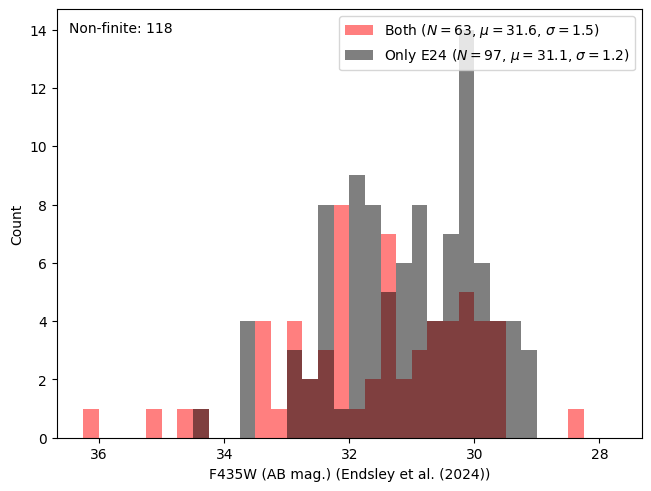

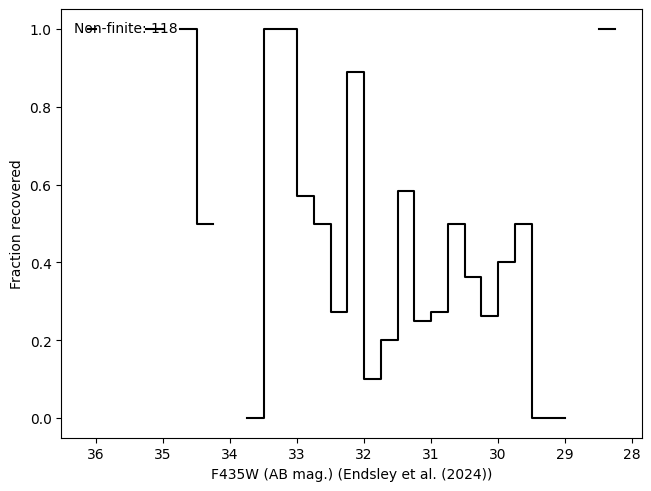

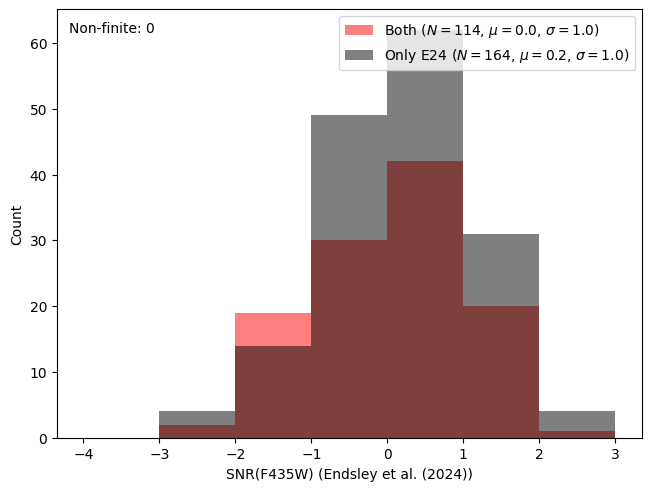

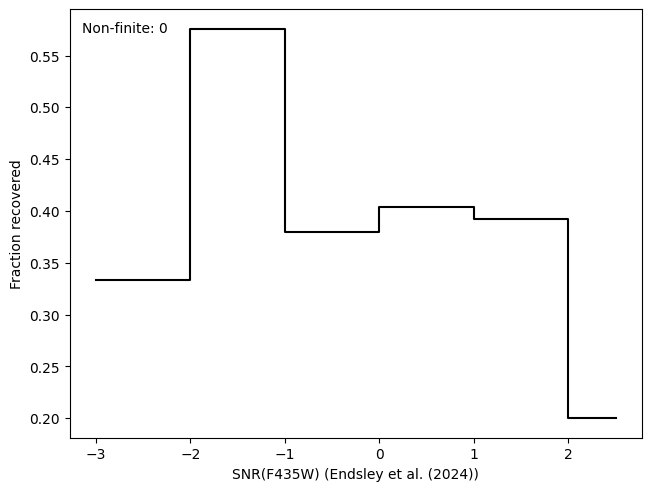

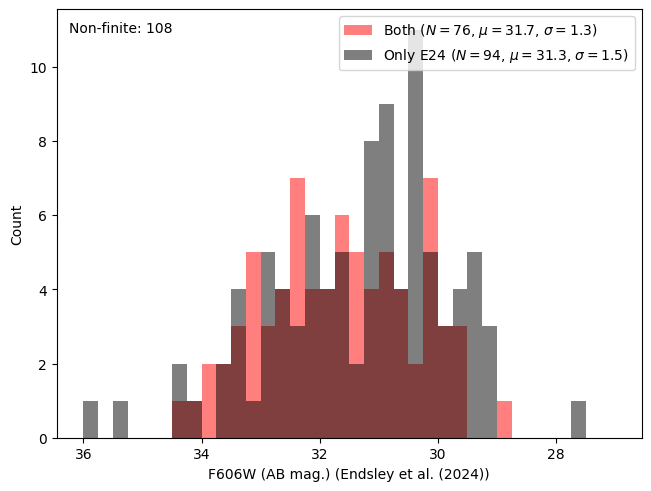

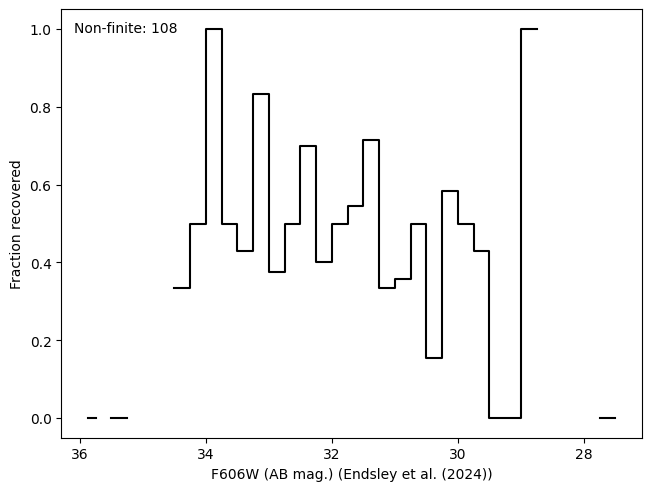

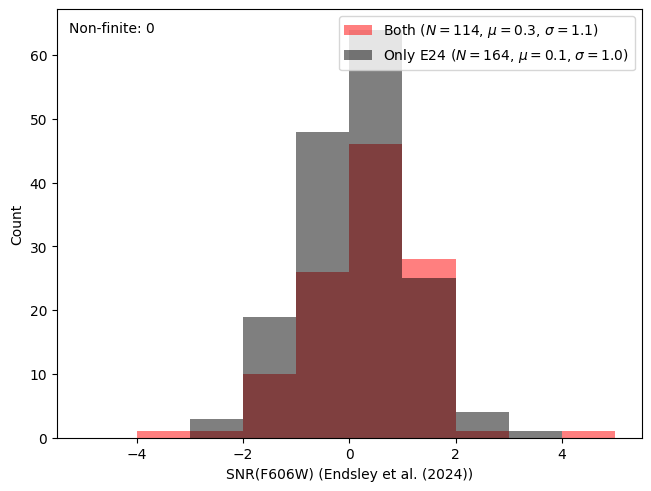

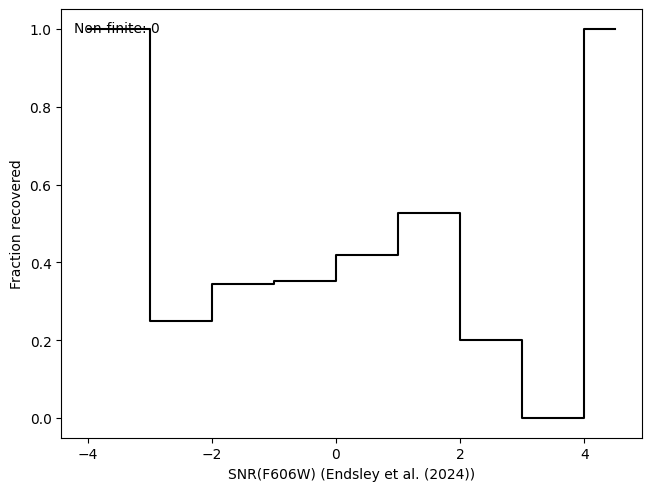

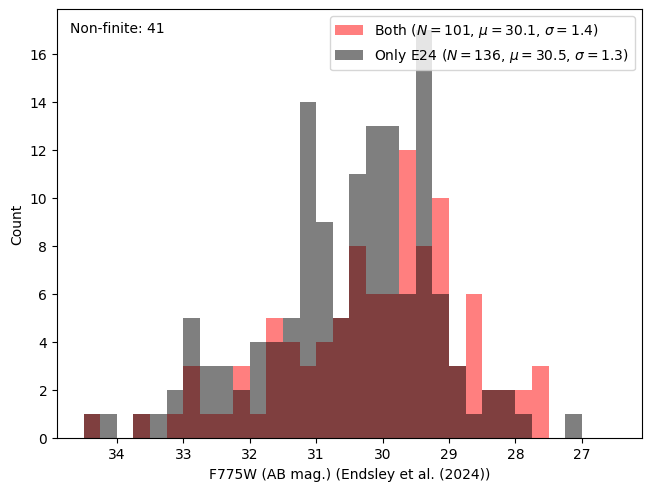

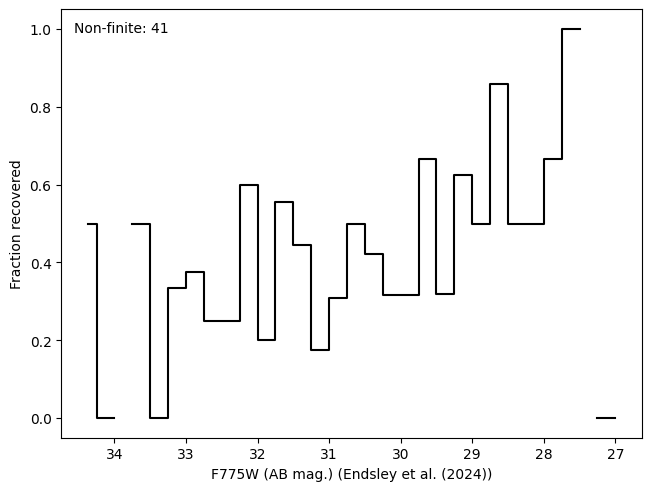

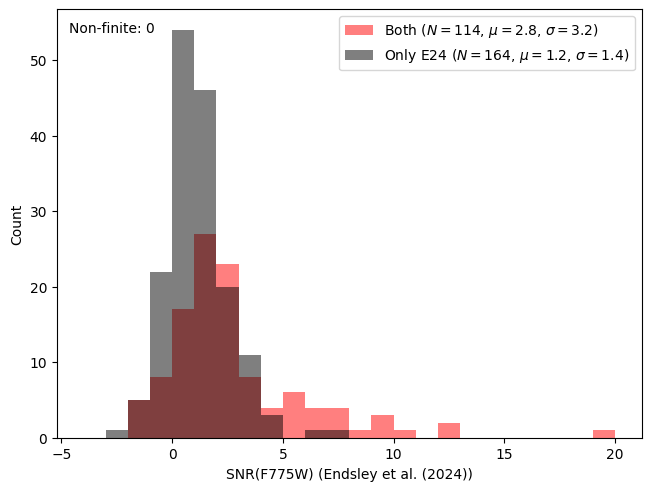

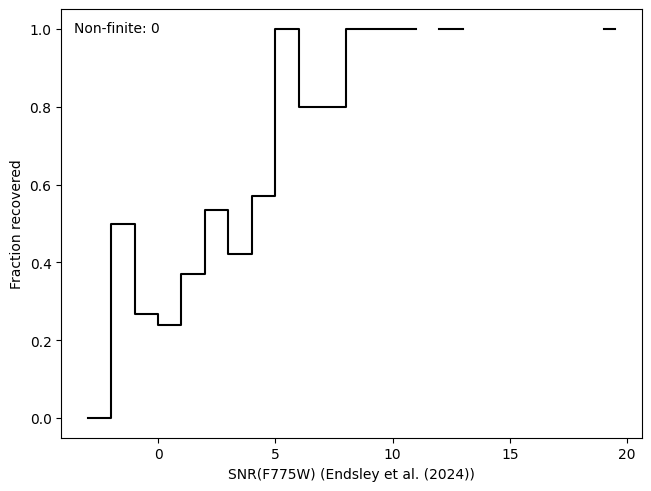

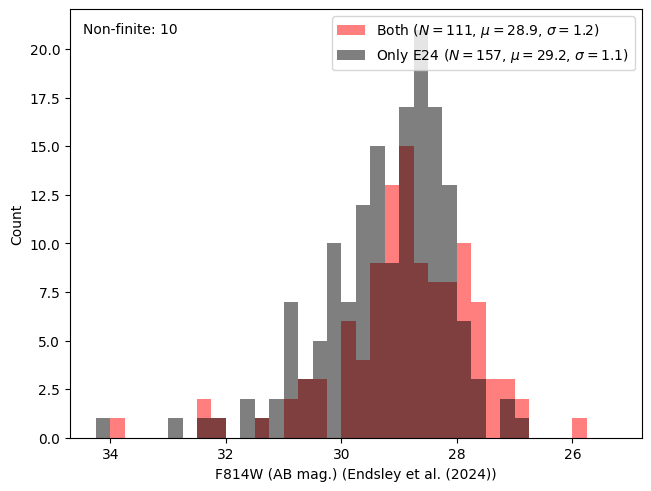

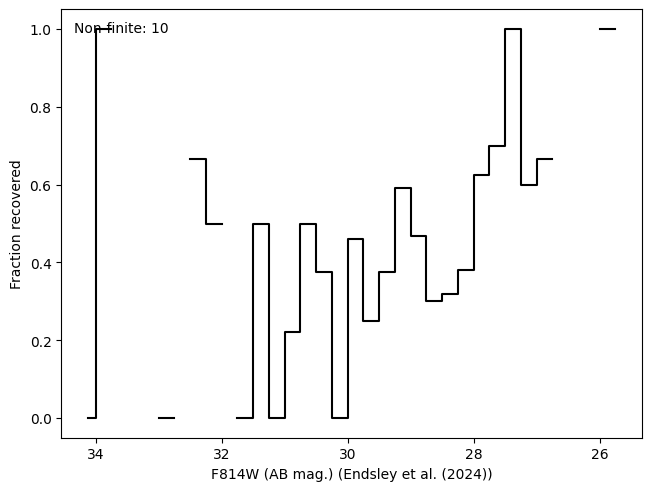

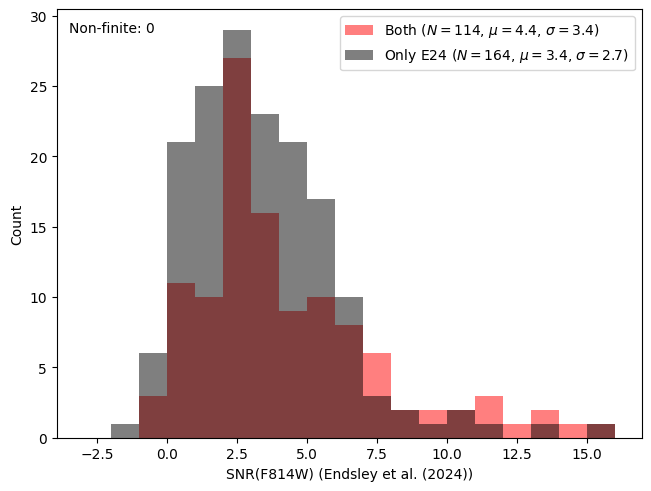

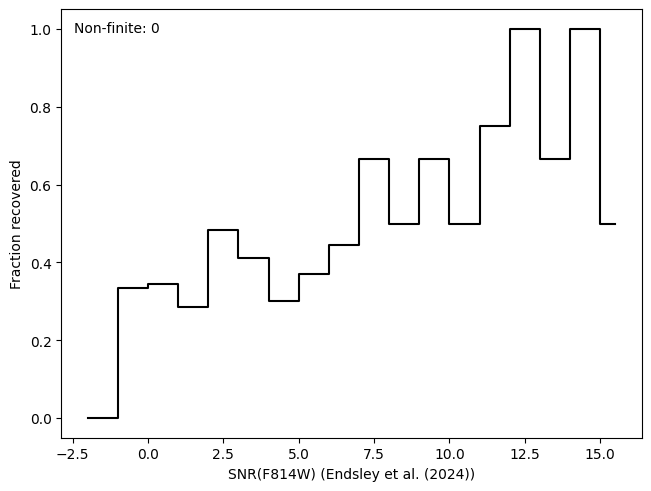

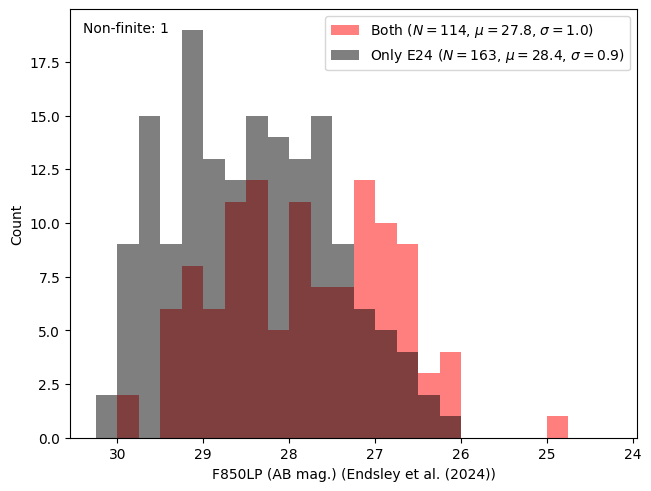

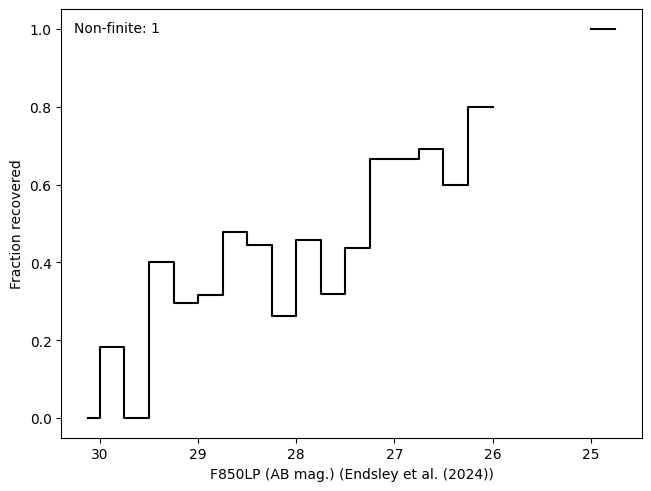

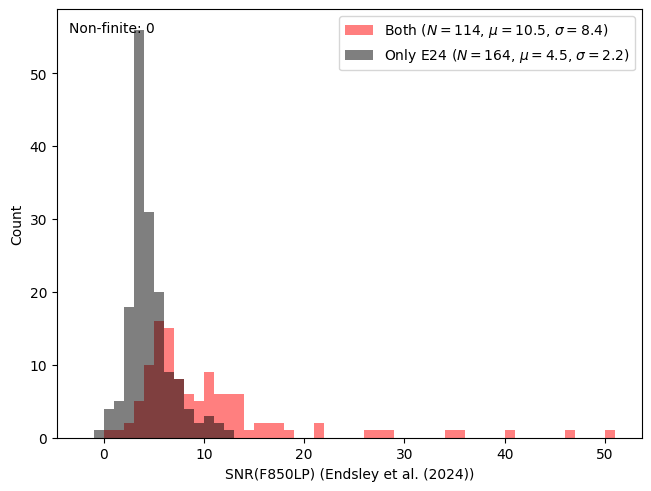

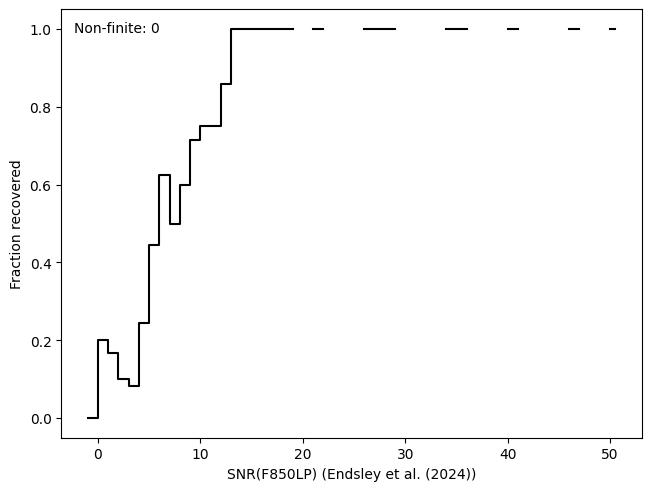

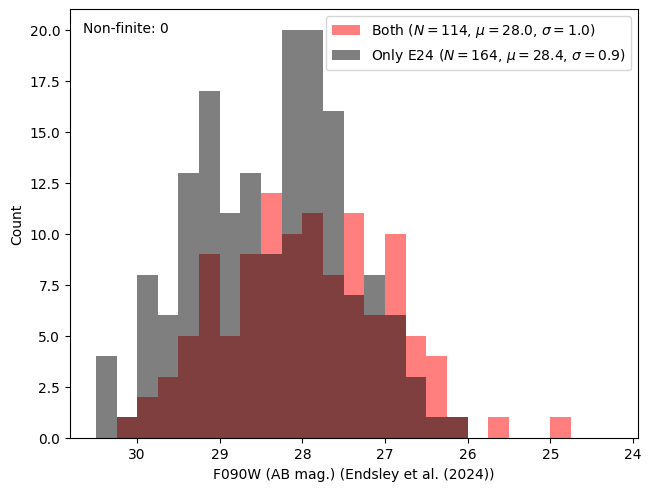

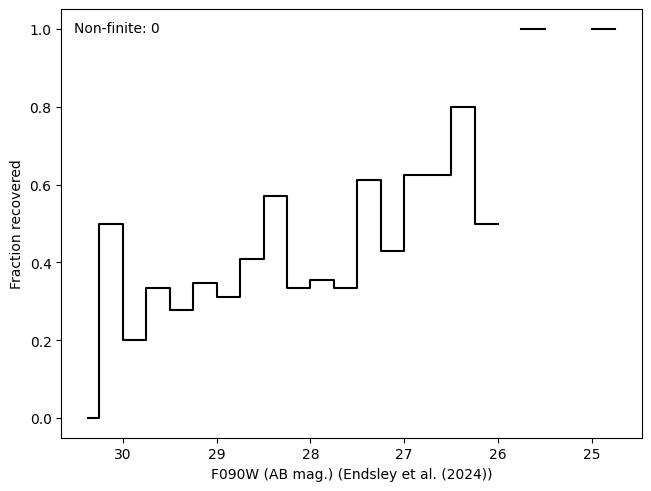

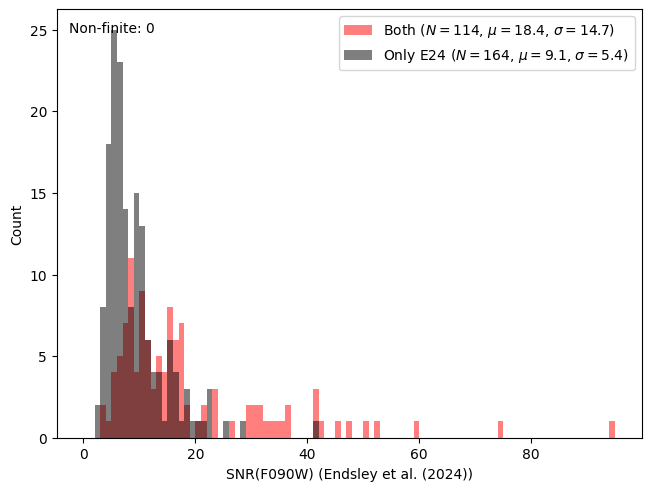

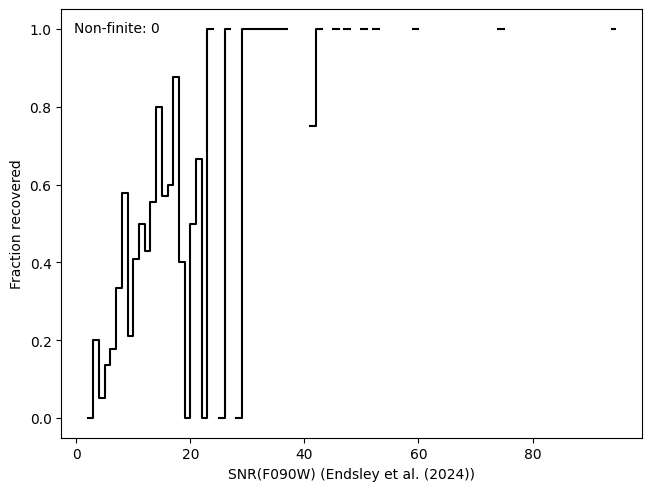

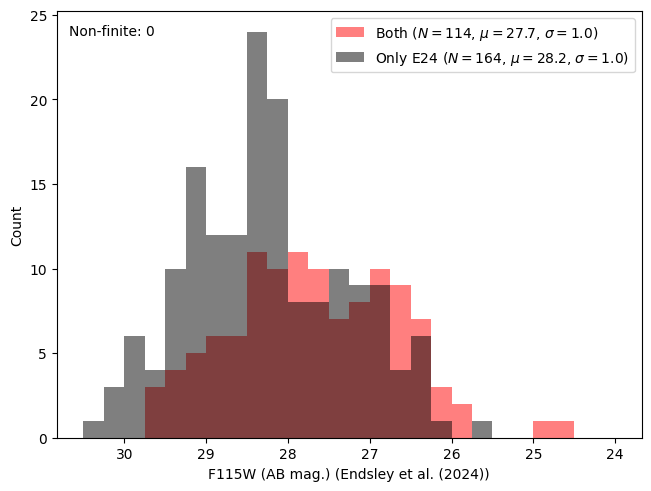

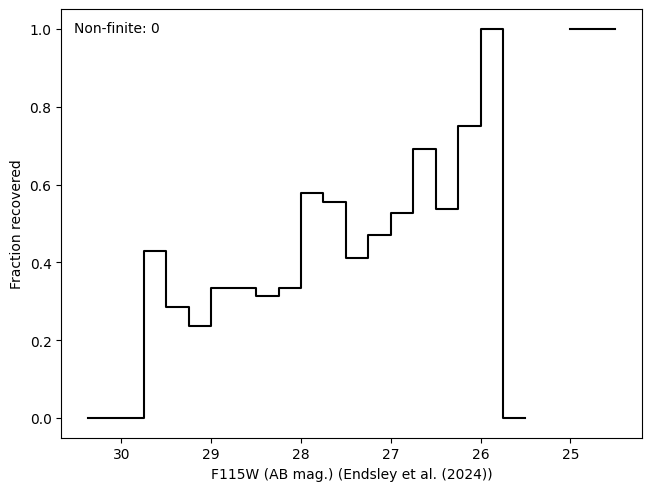

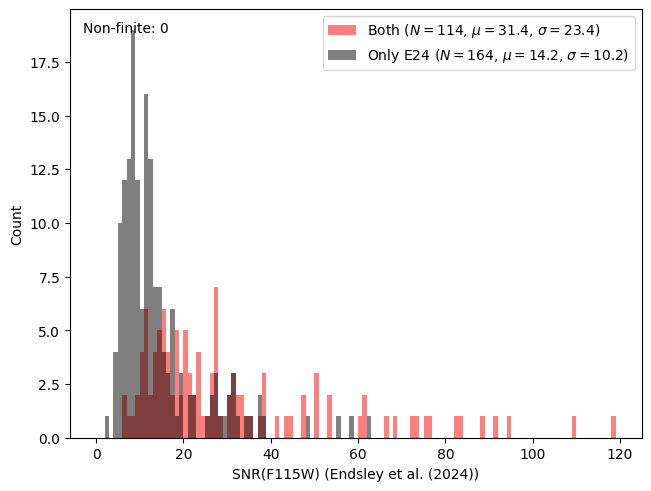

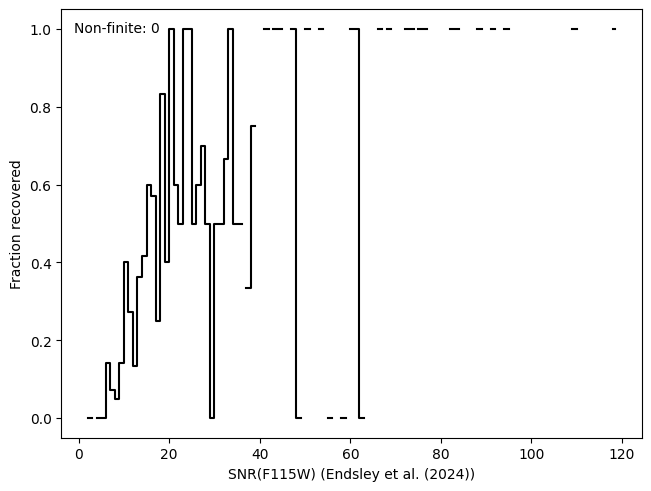

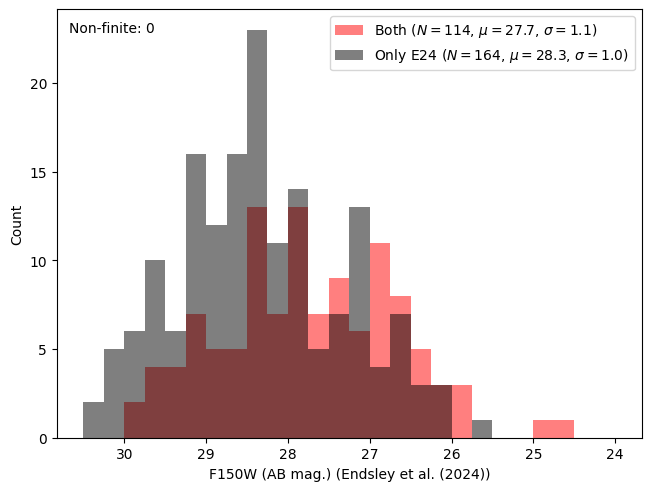

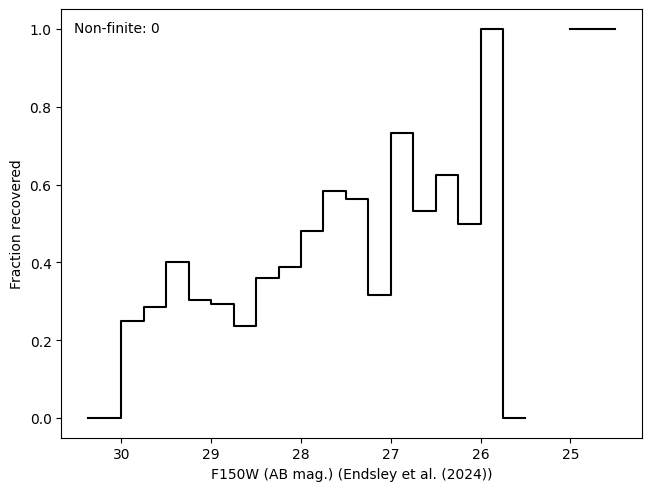

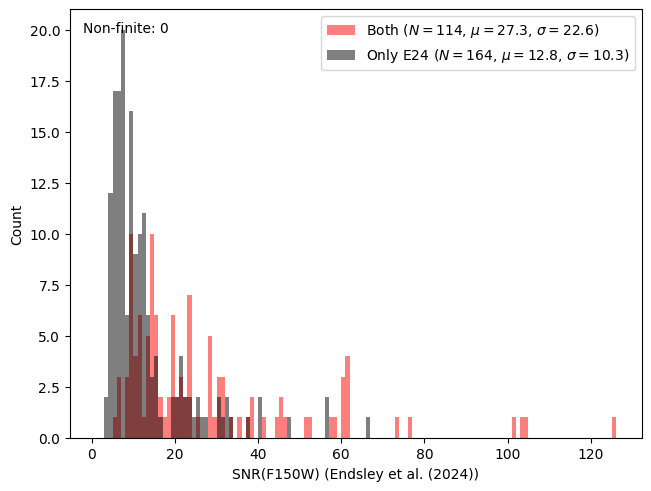

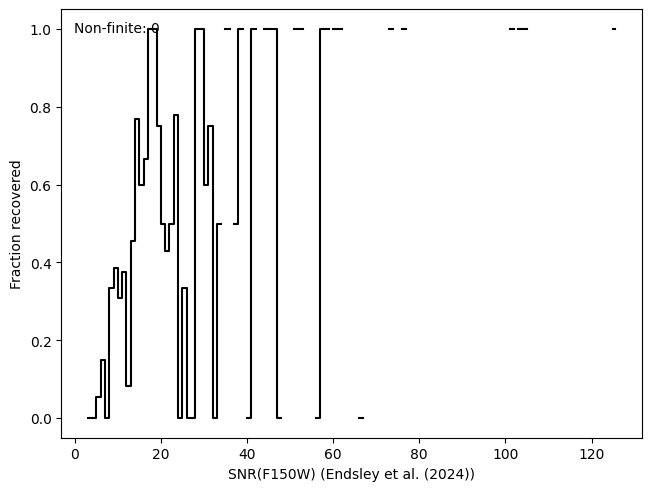

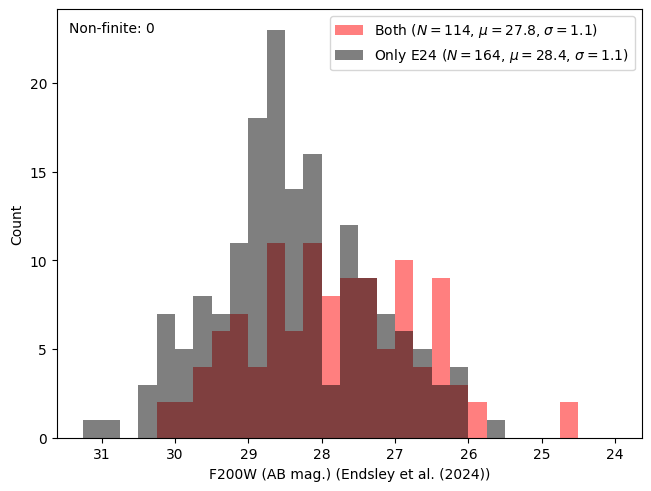

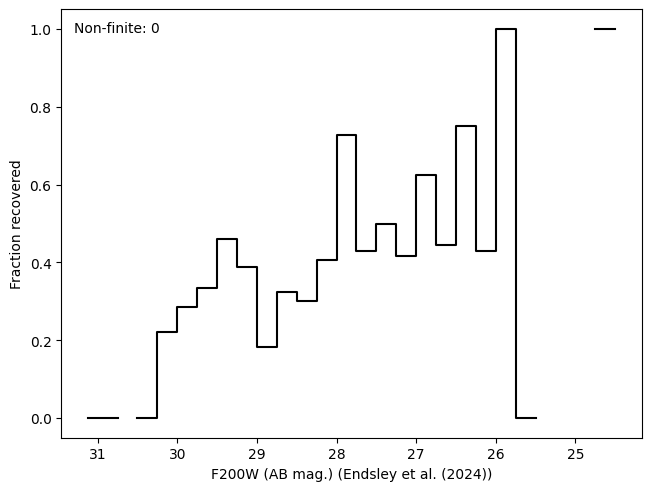

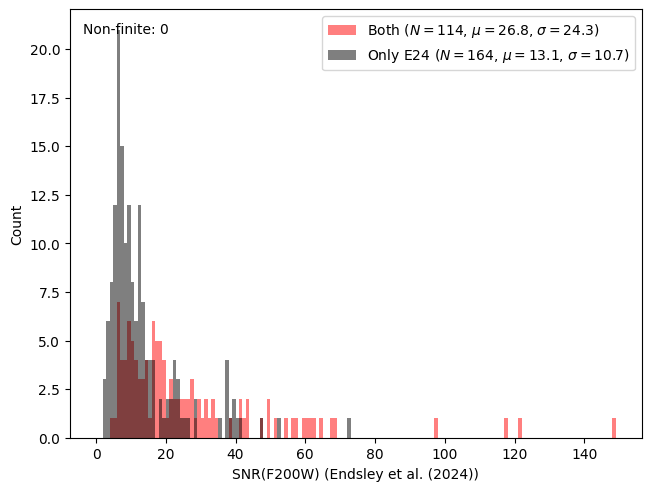

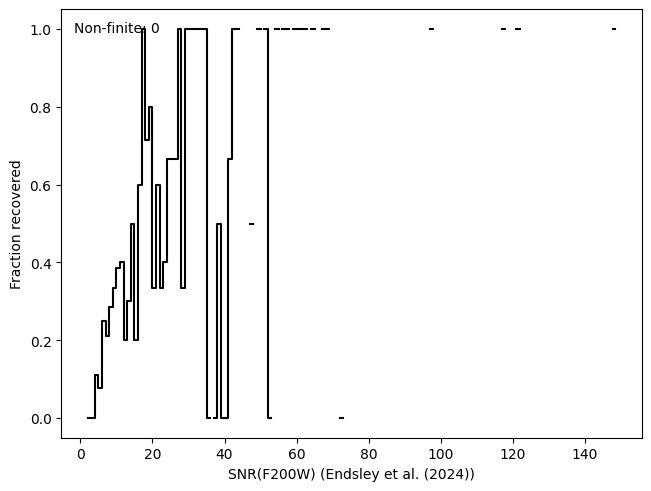

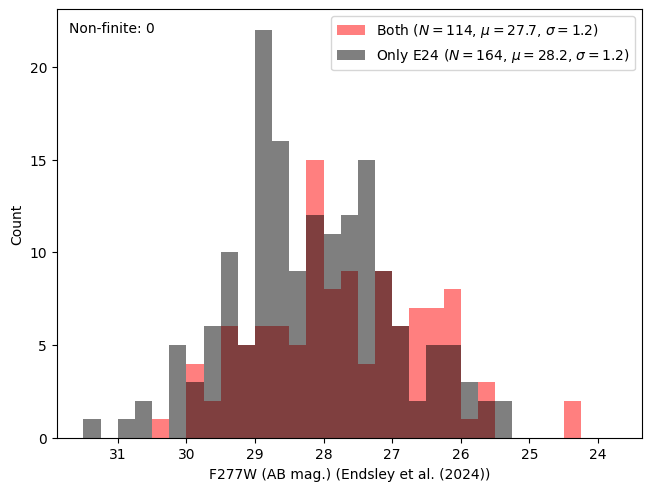

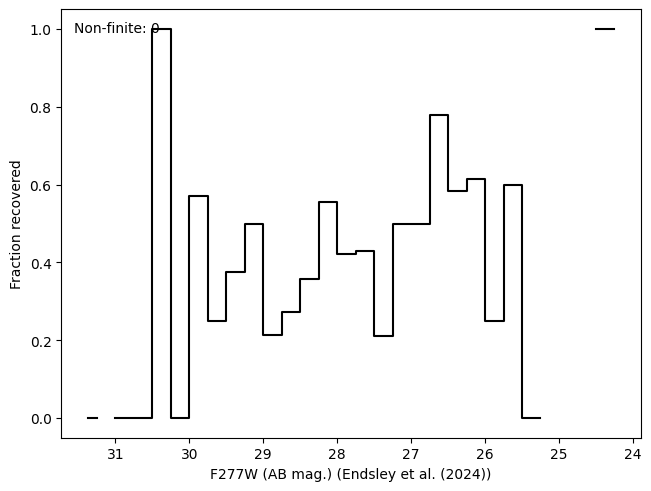

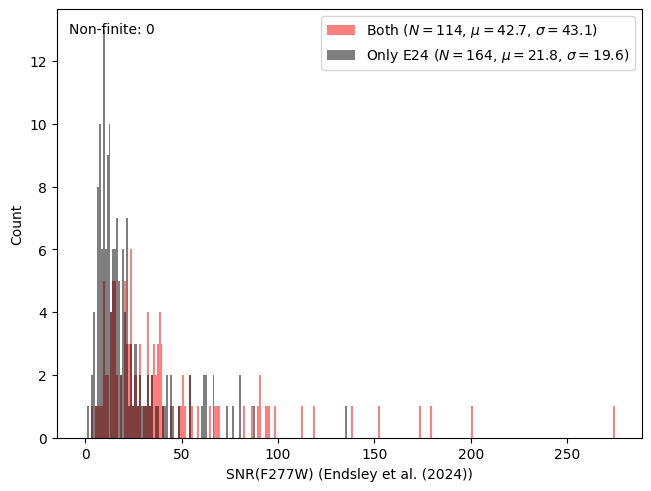

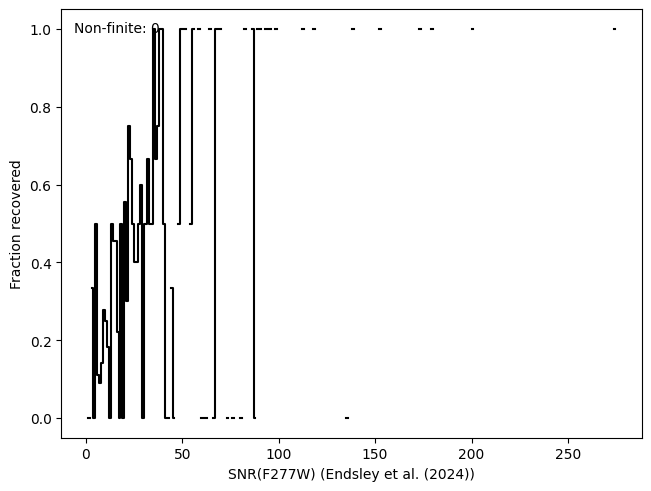

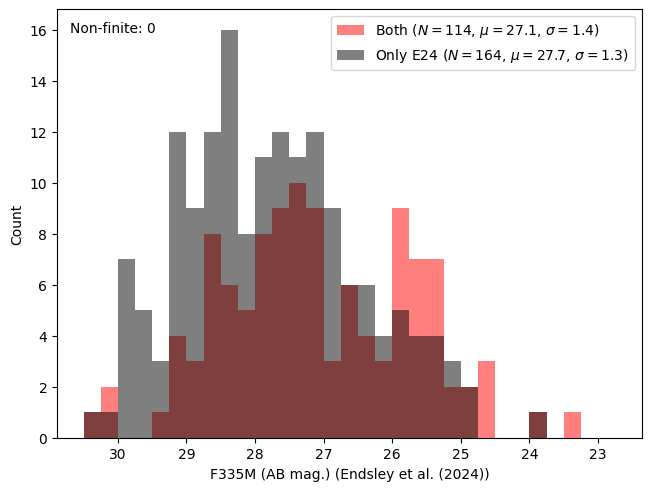

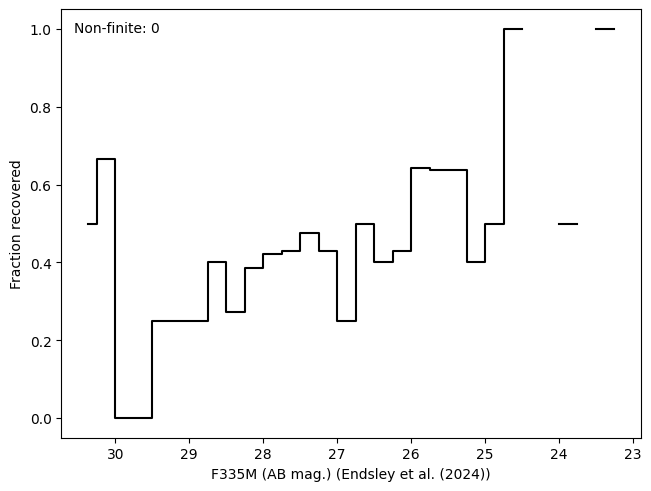

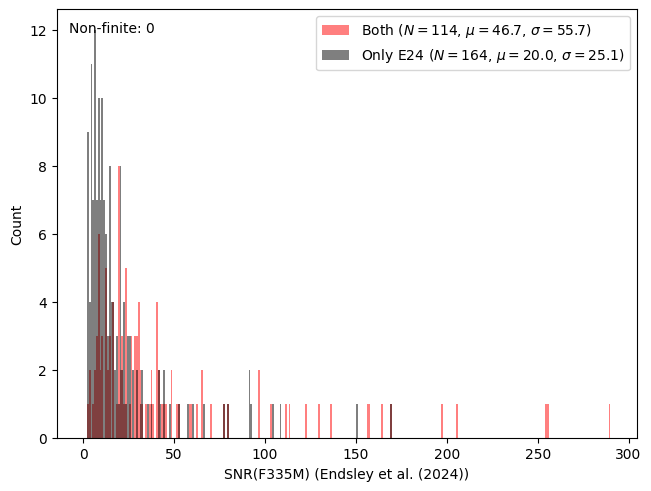

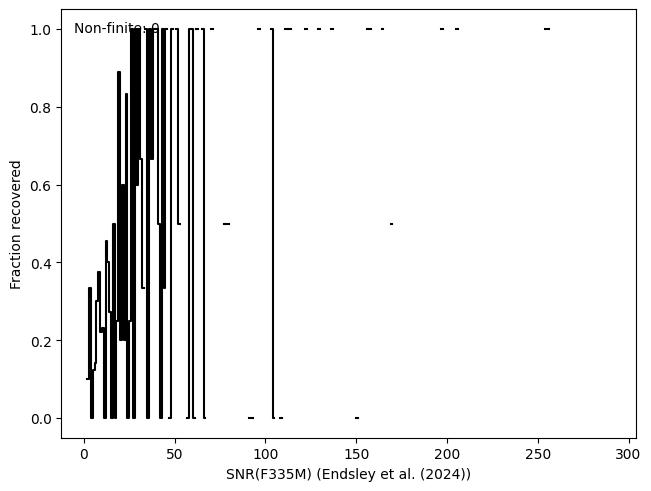

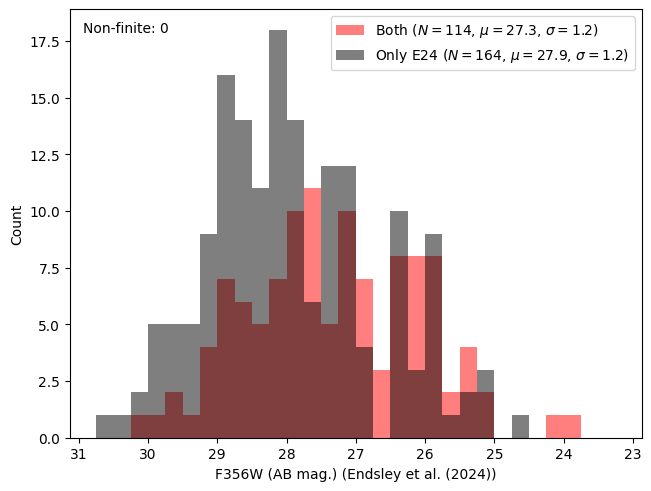

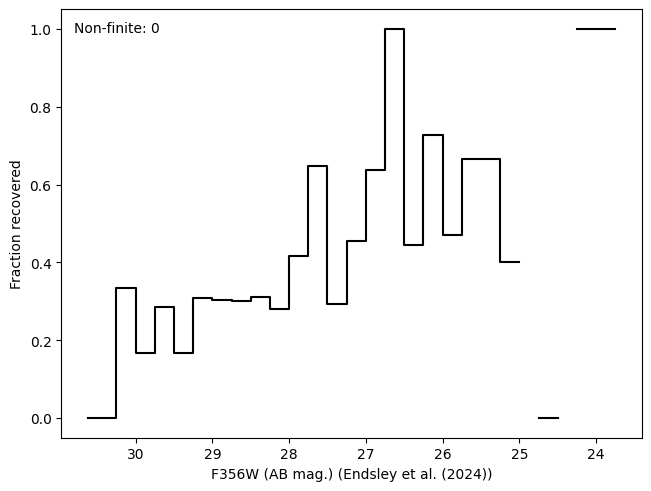

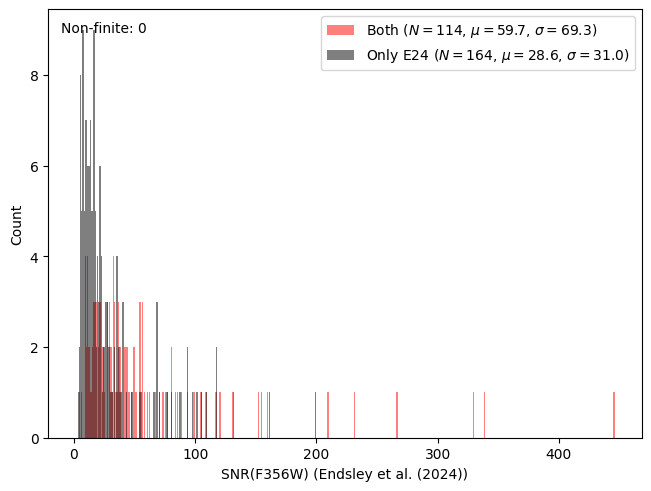

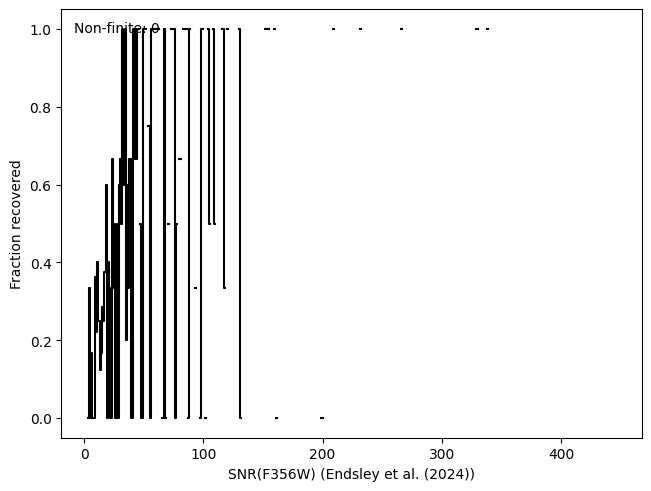

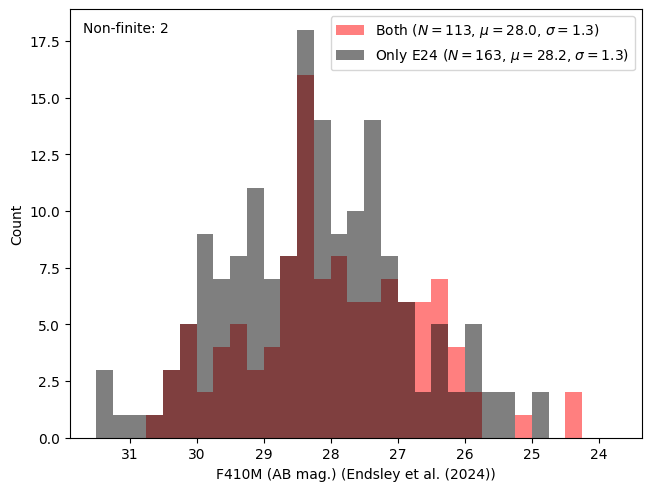

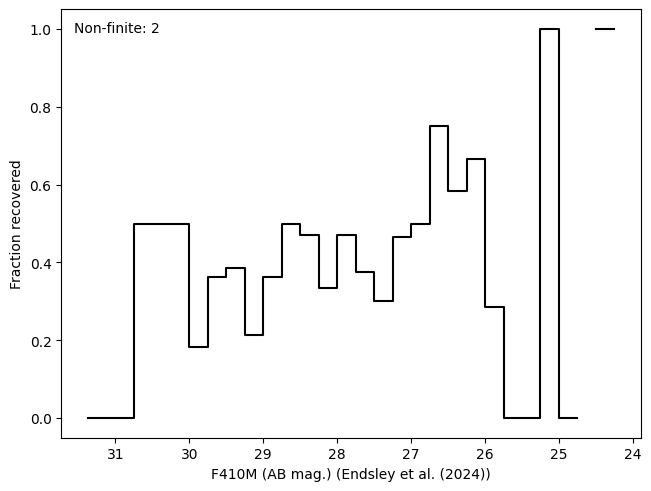

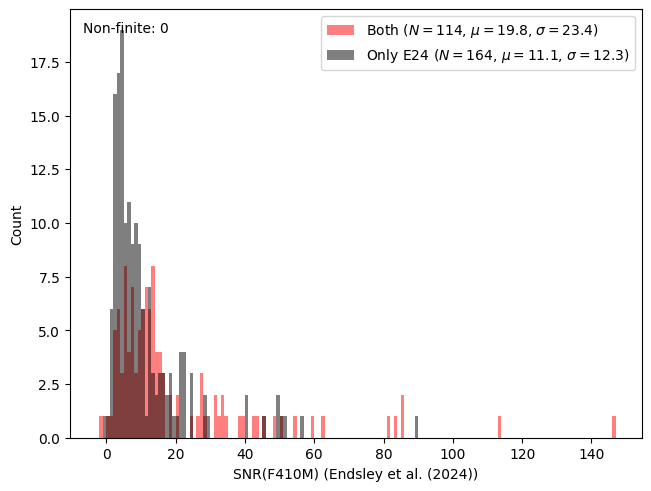

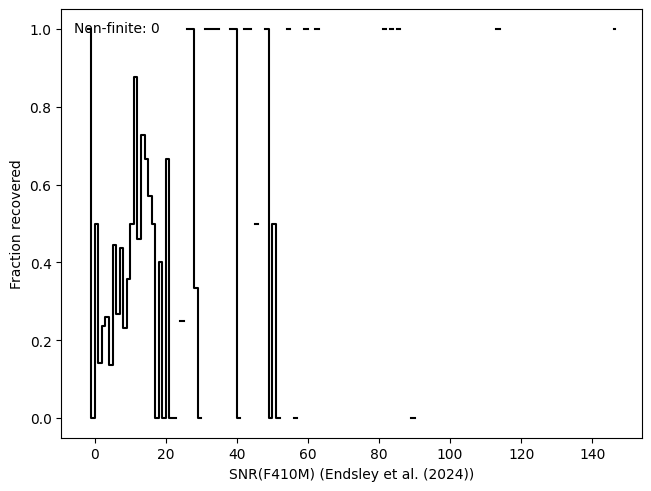

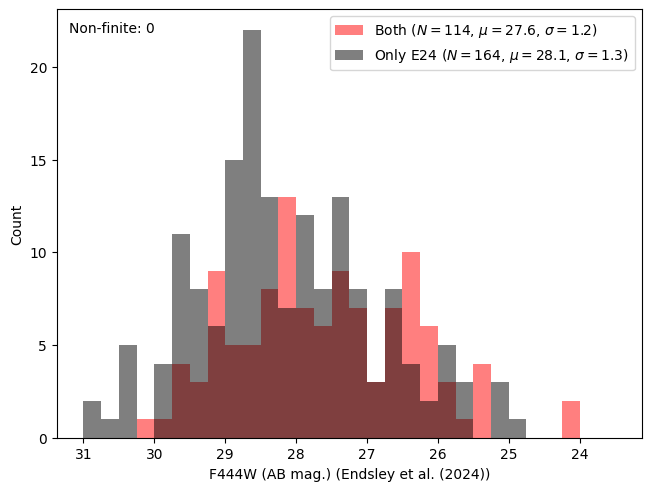

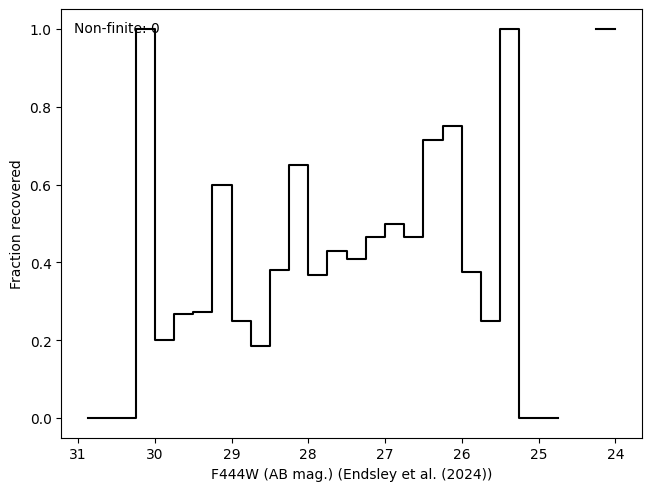

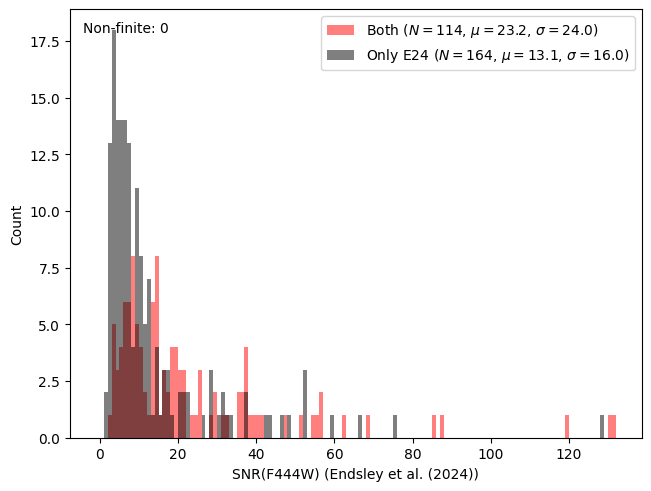

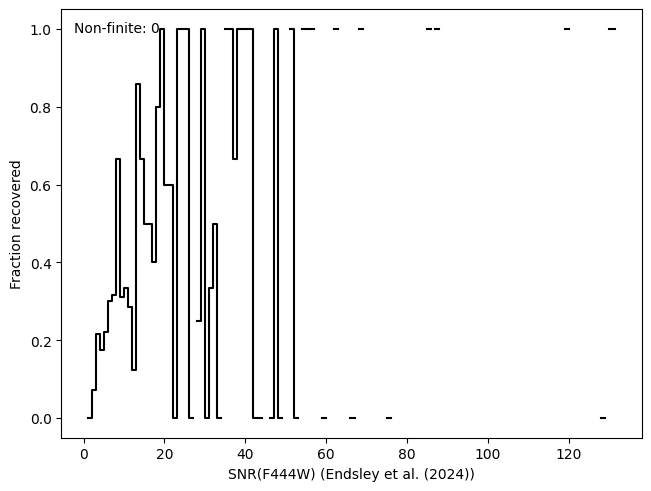

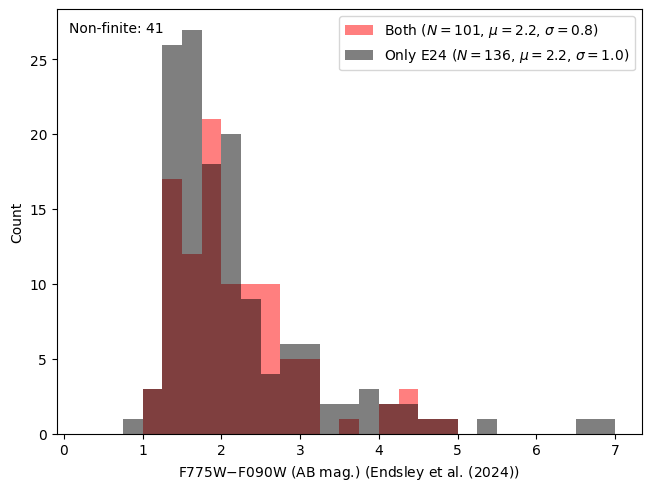

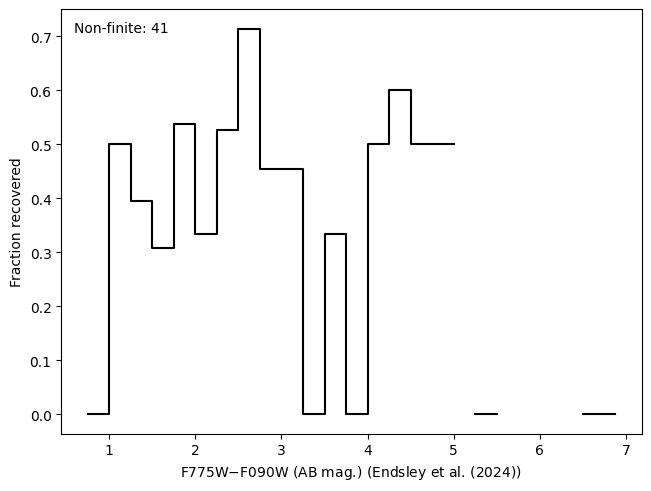

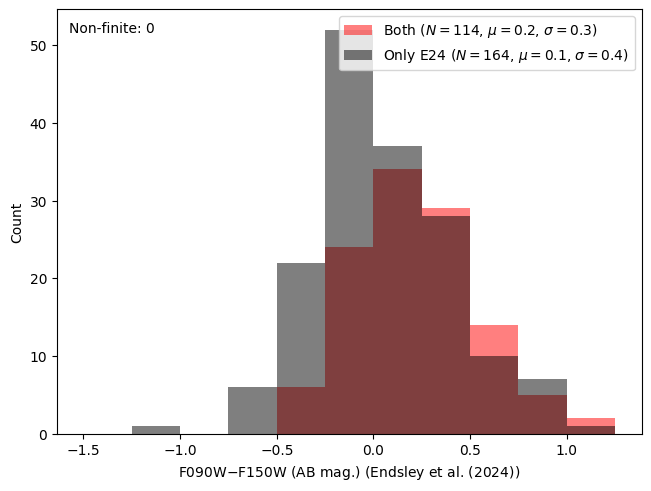

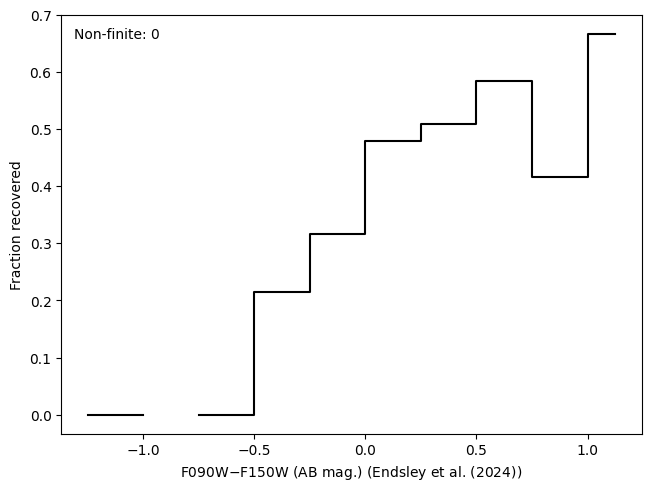

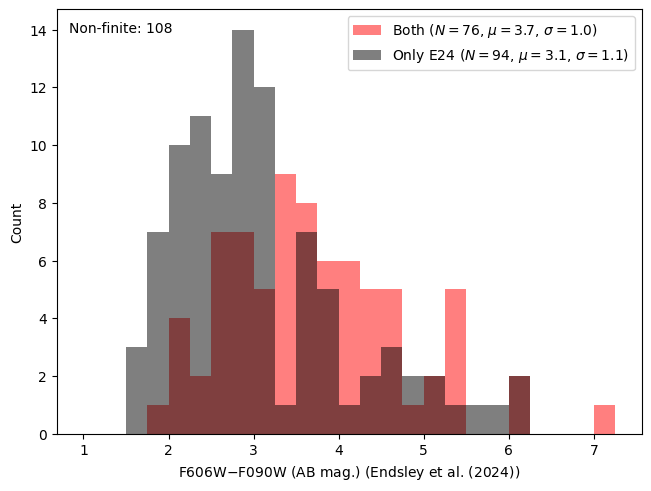

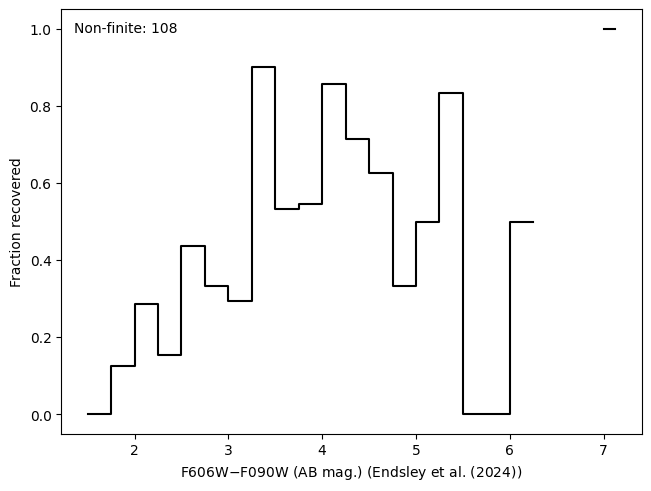

In [109]:
compare_endsley2024()

# Need to fix this; shouldn't do a 2-dimensional scatter plot with histograms, since this isn't plotting two sets of measurements for the same objects, but
# instead showing one set of measurements of the same objects but highlighting subsamples of those objects

/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in log10
  return dex.to(self._function_unit, np.log10(x))
/Users/a15136/Documents/research/.venv/lib/python3.13/site-packages/astropy/units/function/logarithmic.py:67: RuntimeWarning: invalid value encountered in l

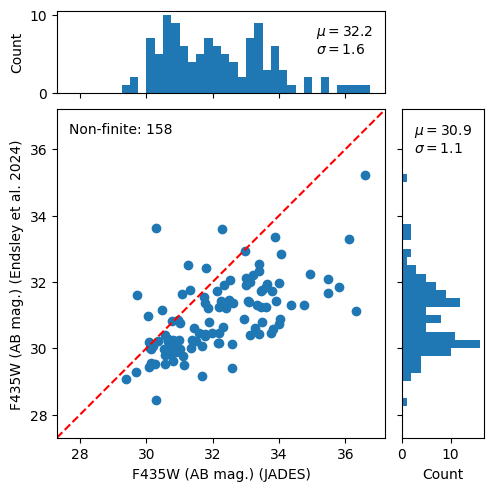

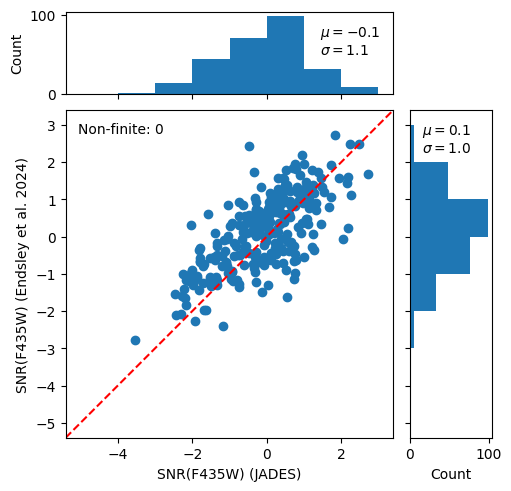

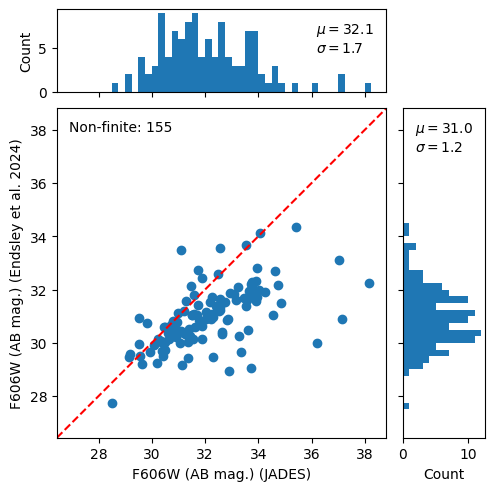

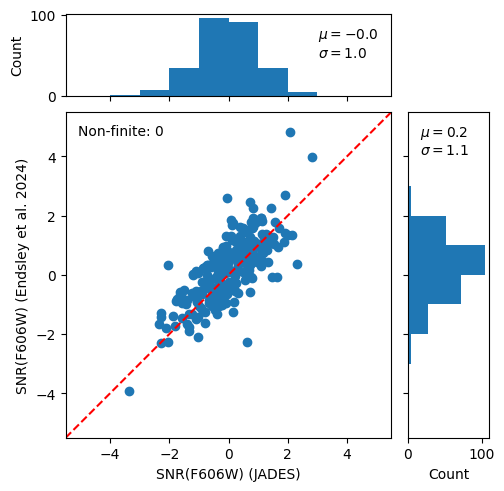

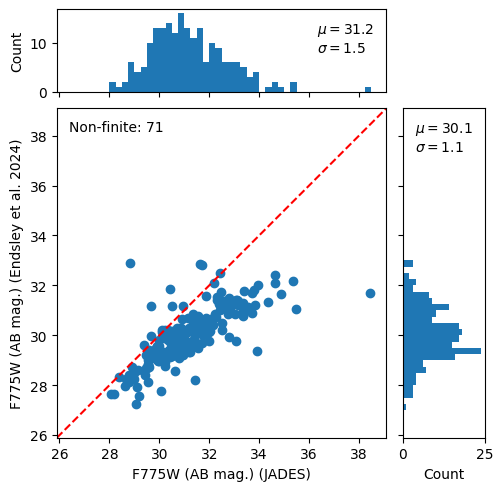

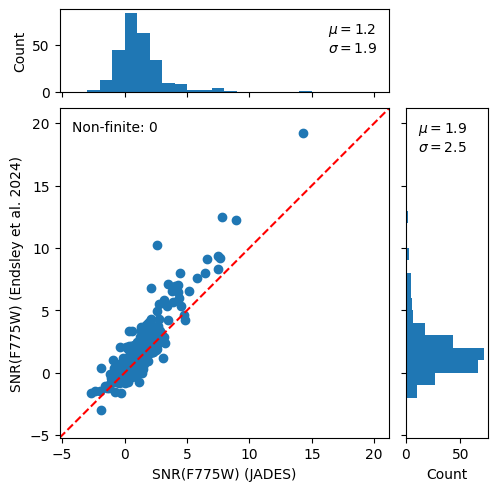

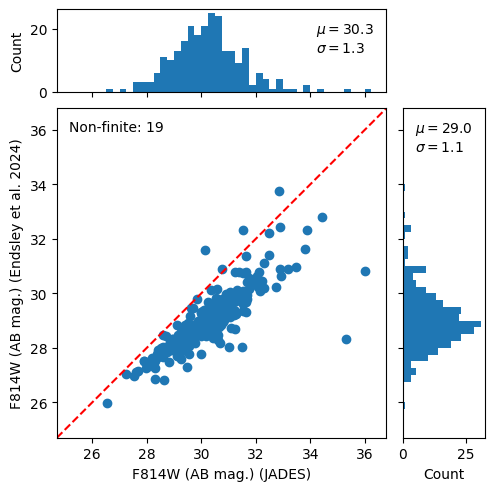

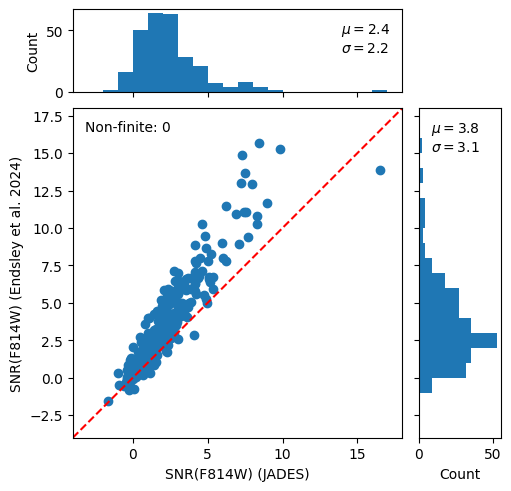

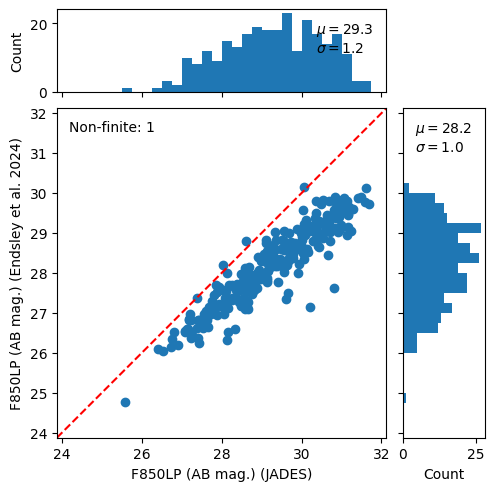

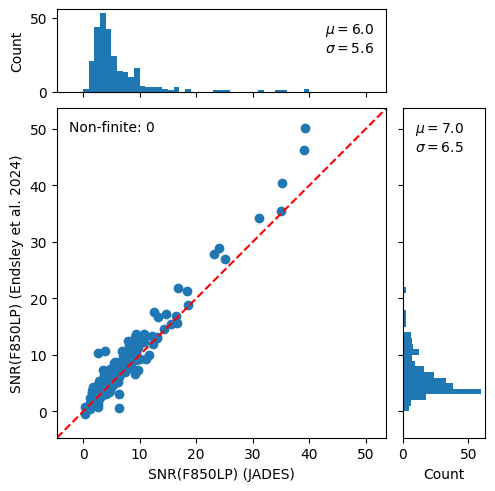

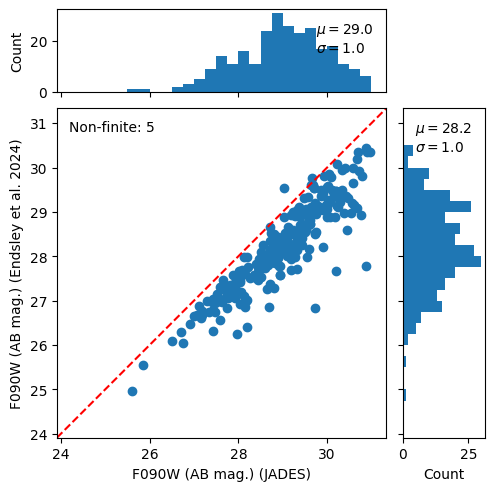

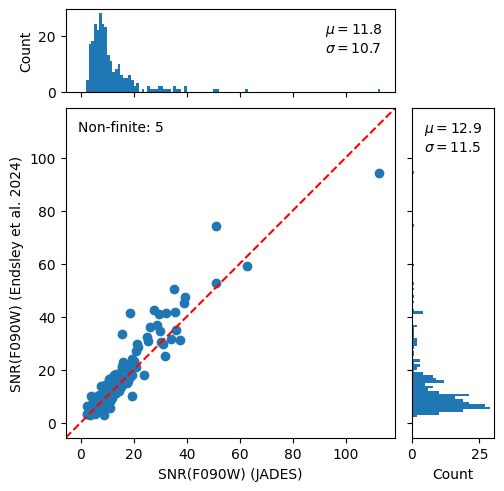

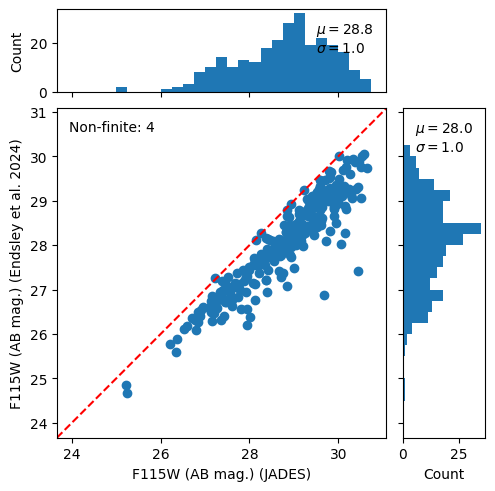

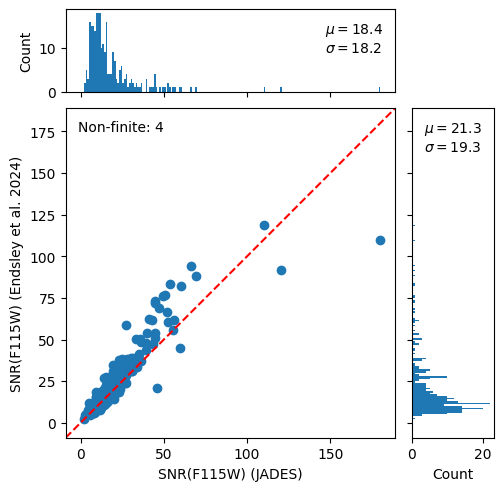

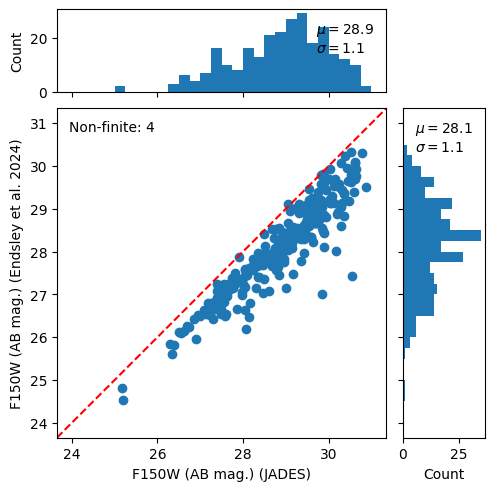

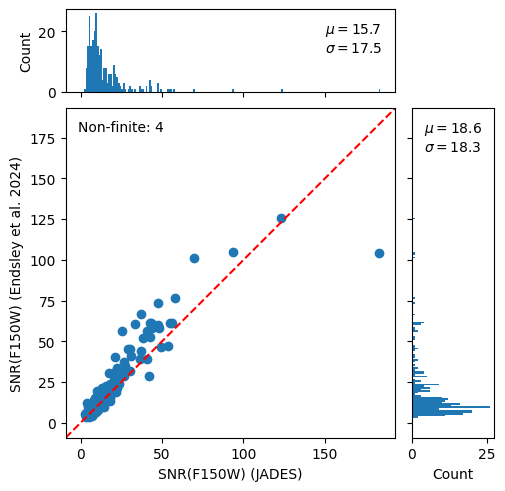

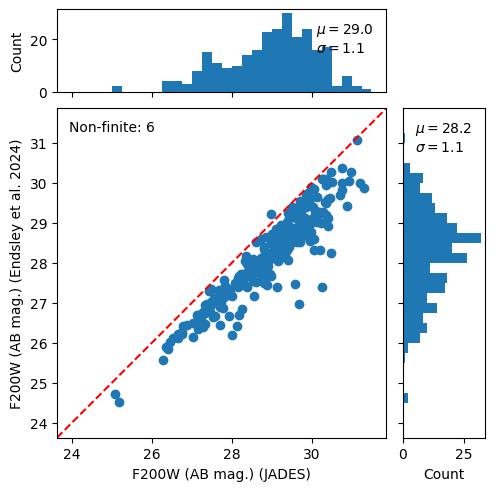

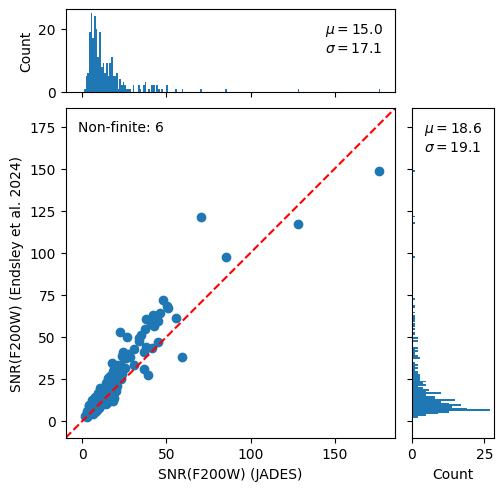

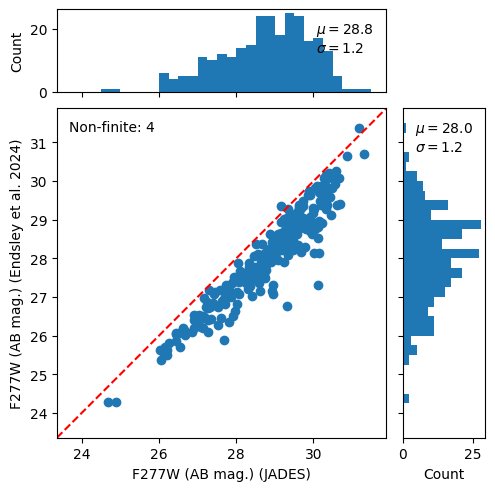

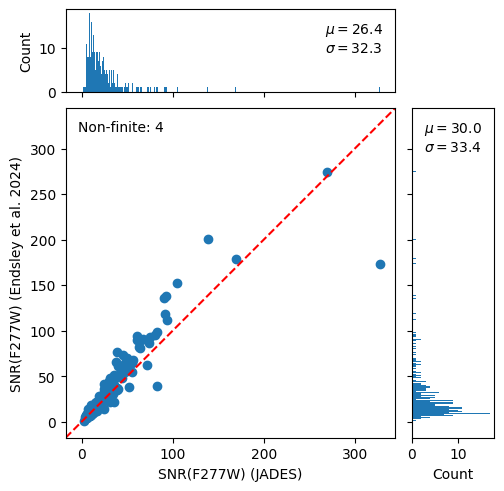

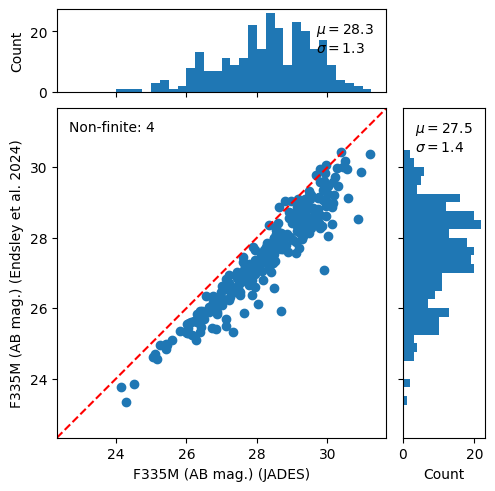

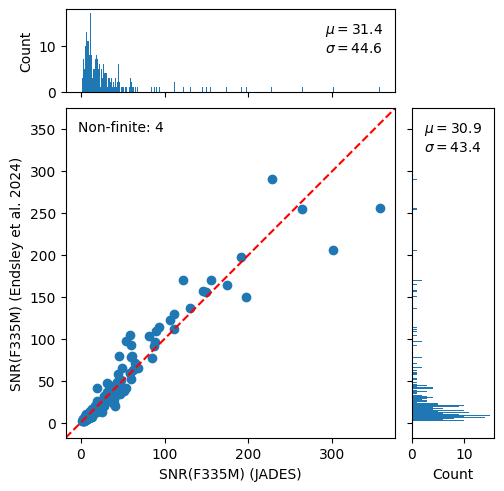

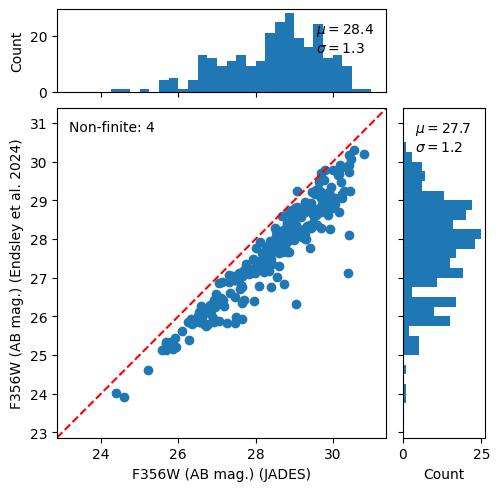

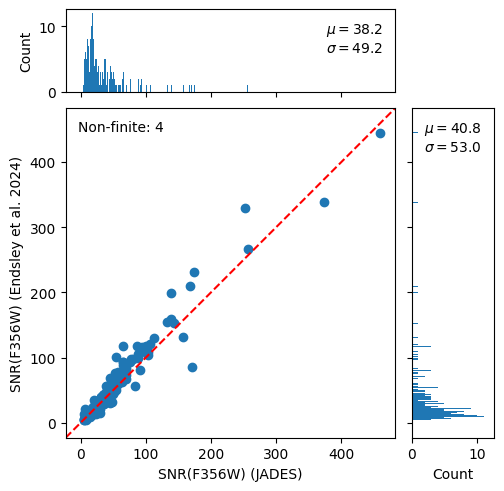

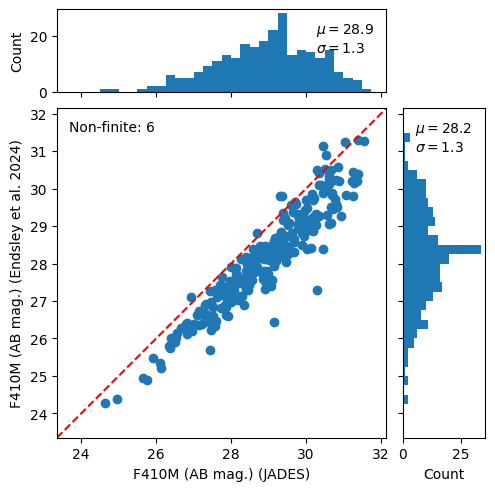

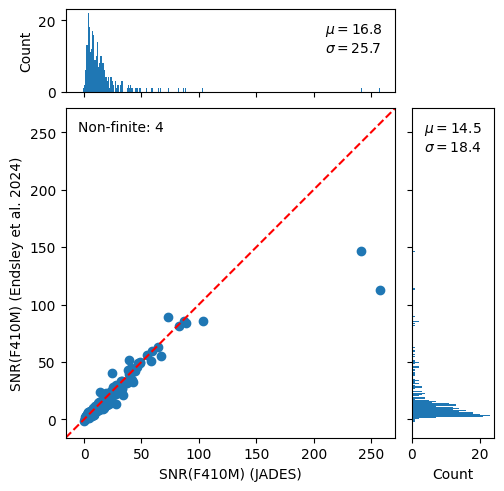

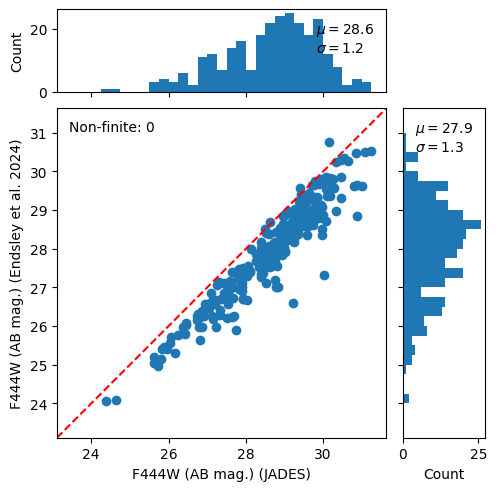

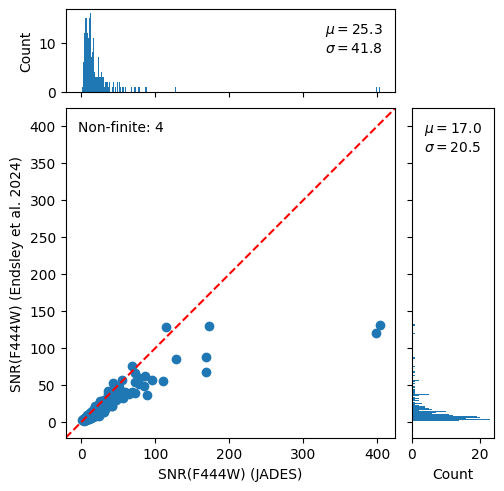

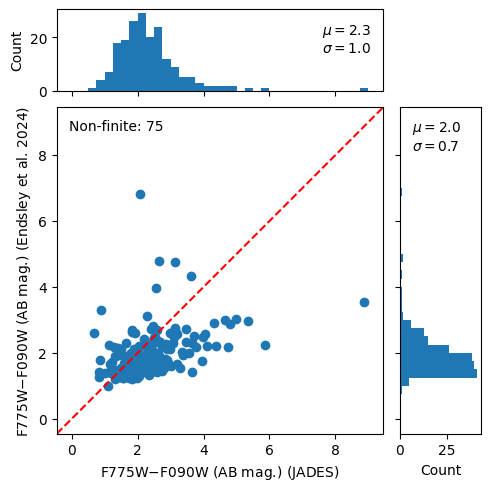

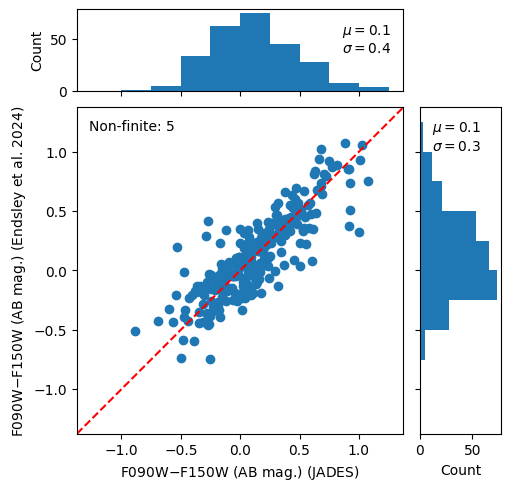

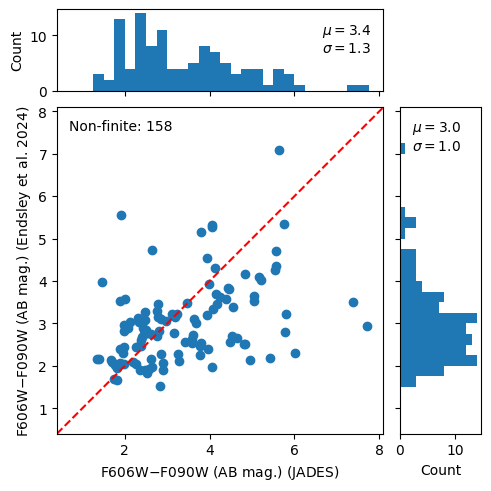

In [17]:
compare_catalog_endsley2024()